In [1]:
# Get daily constraint ranked by the abs RT - DA 
import sys
sys.path.append('/var/www/python/Prod/nighthawk/')

import pandas as pd
from nighthawk.data import Constraint

In [2]:
now = pd.Timestamp.now(tz='US/Central')
days_ahead = 2 if now.hour >= 10 else 1
bid_dt = (now + pd.Timedelta(days=days_ahead)).strftime('%Y-%m-%d')
print(bid_dt)

2026-05-30


In [3]:
def get_recent_constraint_mvalue(start_dt=(pd.Timestamp(pd.Timestamp.now(tz='US/Central').strftime('%Y-%m-%d')) - pd.Timedelta(days=3)).strftime('%Y-%m-%d'), \
                                 end_dt=pd.Timestamp.now(tz='US/Central').strftime('%Y-%m-%d'), \
                                    threshold=1000):

    opex = 'SPP'
    end_dt = pd.Timestamp.now(tz='US/Central').strftime('%Y-%m-%d')
    start_dt = (pd.Timestamp(end_dt) - pd.Timedelta(days=3)).strftime('%Y-%m-%d')


    print(f"start_dt: {start_dt}, end_dt: {end_dt}, Market: {opex}")

    # Get RT and DA hourly mvalues for all constraints over the date range
    print("Fetching RT mvalues...")
    mv_rt = Constraint(oops_constraint_num_df=None, market=opex).get_mvalues(
        start_dt=start_dt, end_dt=end_dt, type='RT', granularity='hourly')

    print("Fetching DA mvalues...")
    mv_da = Constraint(oops_constraint_num_df=None, market=opex).get_mvalues(
        start_dt=start_dt, end_dt=end_dt, type='DA', granularity='hourly')

    print(f"RT constraints: {mv_rt['oops_constraint_num'].nunique()}, DA constraints: {mv_da['oops_constraint_num'].nunique()}")

    # Sum mvalues per constraint
    rt_total = mv_rt.groupby('oops_constraint_num')['mvalue'].sum().rename('rt_total')
    da_total = mv_da.groupby('oops_constraint_num')['mvalue'].sum().rename('da_total')

    # Merge and compute abs(RT - DA), ranked descending
    merged = pd.merge(rt_total, da_total, on='oops_constraint_num', how='outer').fillna(0)
    merged['rt_da'] = (merged['rt_total'] - merged['da_total'])
    merged['abs_rt_da_diff'] = (merged['rt_total'] - merged['da_total']).abs()
    merged = merged.sort_values('abs_rt_da_diff', ascending=False).reset_index()

    # Get constraint details
    all_cons = merged[['oops_constraint_num']].copy()
    print("Fetching constraint details...")
    details_rt = Constraint(oops_constraint_num_df=all_cons, market=opex).get_constraint_details(da_or_rt='RT')
    details_da = Constraint(oops_constraint_num_df=all_cons, market=opex).get_constraint_details(da_or_rt='DA')
    details = pd.concat([details_rt, details_da]).drop_duplicates('oops_constraint_num')

    # Merge everything
    result = pd.merge(merged, details[['oops_constraint_num', 'monitored_clean', 'contingency_clean']], on='oops_constraint_num', how='left')
    result = result.rename(columns={'monitored_clean': 'monitored', 'contingency_clean': 'contingency'})
    result_final = result.groupby('monitored')[['rt_total','da_total','rt_da']].sum().reset_index()
    result_final['abs_rt_da_diff'] = abs(result_final['rt_da'])
    result_final = result_final[result_final['abs_rt_da_diff']>threshold]
    result = result[result['monitored'].isin(result_final.monitored.tolist())]


    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', 200)
    pd.set_option('display.max_colwidth', 80)
    display(result[['oops_constraint_num', 'rt_total', 'da_total', 'rt_da', 'abs_rt_da_diff', 'monitored', 'contingency']])

    return result 

In [4]:
def get_node_dfax_from_constraint_num(result):
    opex= 'SPP'
    con_df = result[['oops_constraint_num']].drop_duplicates()

    dfax = Constraint(oops_constraint_num_df=con_df, market=opex).get_dfax_on_all_nodes(dfax_cutoff=0.05, dfax_type='RT')

    node_dfax = (result
        .merge(dfax, on='oops_constraint_num')
        .sort_values(['abs_rt_da_diff', 'dfax'], ascending=[False, False])
    )

    columns = ['oops_constraint_num','node_num','dfax']
    node_dfax = node_dfax[columns]
    return node_dfax

In [5]:
def get_hourly_mvalue_for_constraint_num(result, weeks=104):

    opex='SPP'
    end_dt2   = pd.Timestamp.now(tz='US/Central').strftime('%Y-%m-%d')
    start_dt2 = (pd.Timestamp(end_dt2) - pd.Timedelta(weeks=weeks)).strftime('%Y-%m-%d')

    con_df = result[['oops_constraint_num']].drop_duplicates()

    # Step 1: daily mvalues to find active days
    mv_rt_daily = Constraint(oops_constraint_num_df=con_df, market=opex).get_mvalues(
        start_dt=start_dt2, end_dt=end_dt2, type='RT', granularity='daily')
    mv_da_daily = Constraint(oops_constraint_num_df=con_df, market=opex).get_mvalues(
        start_dt=start_dt2, end_dt=end_dt2, type='DA', granularity='daily')

    # Step 2: keep only days where mvalue != 0
    rt_active = mv_rt_daily[mv_rt_daily['mvalue'] != 0][['oops_constraint_num', 'dt']].drop_duplicates()
    da_active = mv_da_daily[mv_da_daily['mvalue'] != 0][['oops_constraint_num', 'dt']].drop_duplicates()

    print(f"RT active constraint-days: {len(rt_active)}")
    print(f"DA active constraint-days: {len(da_active)}")

    # Step 3: fetch hourly mvalues only for those active days
    def get_hourly_for_active_days(active_df, ctype):
        if active_df.empty:
            return pd.DataFrame()
        results = []
        for con_num, grp in active_df.groupby('oops_constraint_num'):
            dates = grp['dt'].astype(str).tolist()
            mv_h = Constraint(
                oops_constraint_num_df=pd.DataFrame({'oops_constraint_num': [con_num]}),
                market=opex
            ).get_mvalues(start_dt=min(dates), end_dt=max(dates), type=ctype, granularity='hourly')
            mv_h = mv_h[mv_h['dt'].astype(str).isin(dates)]
            results.append(mv_h)
        return pd.concat(results, ignore_index=True) if results else pd.DataFrame()

    mv_rt_2w = get_hourly_for_active_days(rt_active, 'RT')
    mv_da_2w = get_hourly_for_active_days(da_active, 'DA')

    # Step 3: outer join on constraint, dt, hr — compute rt - da per hour
    mv_merged = (
        mv_rt_2w.rename(columns={'mvalue': 'rt_mvalue'})
        .merge(mv_da_2w.rename(columns={'mvalue': 'da_mvalue'}),
            on=['oops_constraint_num', 'dt', 'hr'], how='outer')
        .fillna(0)
    )
    mv_merged['rt_da'] = mv_merged['rt_mvalue'] - mv_merged['da_mvalue']
    print(mv_merged.head())

    names = result[['oops_constraint_num', 'monitored', 'contingency']].drop_duplicates()
    mv_merged = (mv_merged
        .merge(names, on='oops_constraint_num', how='left')
        .sort_values(['oops_constraint_num', 'dt', 'hr'])
        .reset_index(drop=True)
    )
    mv_merged['dt'] = pd.to_datetime(mv_merged['dt']).dt.strftime('%Y-%m-%d')
    print(f"\nMerged hourly rows: {len(mv_merged)}")
    display(mv_merged)
    return mv_merged

In [6]:
from nighthawk.data.network.node import Node

def get_constraint_node_prices_from_constraint_num(mv_merged, node_dfax, monitored_name):
    con_list = mv_merged.loc[mv_merged['monitored'] == monitored_name, 'oops_constraint_num'].unique().tolist()
    not_found= []
    if not con_list:
        print(f"No constraints found for monitored name: '{monitored_name}'")
        return pd.DataFrame()

    results = []
    for con_num in con_list:
        node_map = node_dfax[node_dfax['oops_constraint_num'] == con_num][['node_num', 'dfax']].drop_duplicates()
        mv_con   = mv_merged[mv_merged['oops_constraint_num'] == con_num].copy()

        if node_map.empty or mv_con.empty:
            continue

        mv_con['oops_constraint_num'] = con_num
        mv_con['monitored']   = monitored_name
        mv_con['contingency'] = mv_merged.loc[mv_merged['oops_constraint_num'] == con_num, 'contingency'].iloc[0]

        mv_nodes  = mv_con.merge(node_map, how='cross')
        node_list = node_map['node_num'].astype(int).tolist()

        prices_list = []
        for dt in mv_con.dt.unique():
            p = Node(node_nums=node_list, market='SPP').get_price(
                start_dt=dt, end_dt=dt,
                component=['LMP'], type=['DA', 'RT'], granularity='hourly'
            )[['dt', 'hr', 'node_num', 'da_total', 'rt_total']].rename(
                columns={'da_total': 'node_da_lmp', 'rt_total': 'node_rt_lmp'}
            )
            prices_list.append(p)

        prices = pd.concat(prices_list, ignore_index=True)
        results.append(mv_nodes.merge(prices, on=['dt', 'hr', 'node_num'], how='left'))
    if not results:
        not_found.append(monitored_name) 
        print(monitored_name, 'could not find the dfax value')
        return pd.DataFrame()
    else: 
        result = pd.concat(results, ignore_index=True).sort_values(['dt', 'hr', 'node_num']).reset_index(drop=True)
    return result


def get_constraints_node_price(mvalue, nodedfax, listofnames=[]):
    
    if not listofnames:
        # default to be the all monitored names
        all_monitored = mvalue['monitored'].unique().tolist()
    else: all_monitored = listofnames

    mv_final = pd.concat([get_constraint_node_prices_from_constraint_num(mvalue, nodedfax, name) \
                          for name in all_monitored],ignore_index=True)
    
    if mv_final.empty:
        return 
    mv_grouped = (mv_final
    .groupby(['monitored', 'dt', 'hr', 'node_num'], as_index=False)
    .agg(rt_mvalue=('rt_mvalue', 'sum'),
         da_mvalue=('da_mvalue', 'sum'),
         rt_da=('rt_da', 'sum'),
         dfax=('dfax', 'first'),
         node_da_lmp=('node_da_lmp', 'first'),
         node_rt_lmp=('node_rt_lmp', 'first')))
    
    print(f"\nTotal rows: {len(mv_final)}")
    
    return mv_grouped



In [7]:
import numpy as np
def get_metrics_for_nodes(mv_grouped):
    if mv_grouped is None:
        return 'No nodes dfax'
    mv_grouped['node_rt_da']          = mv_grouped['node_rt_lmp'] - mv_grouped['node_da_lmp']
    mv_grouped['predicted_node_rt_da'] = -mv_grouped['dfax'] * mv_grouped['rt_da']

    # only evaluate hours where the constraint is actually binding
    active = mv_grouped[mv_grouped['rt_da'] != 0].copy()

    def node_constraint_stats(grp):
        x = grp['predicted_node_rt_da']
        y = grp['node_rt_da']
        dfx= grp['dfax'].iloc[0]
        mask = x.notna() & y.notna()
        x, y = x[mask], y[mask]
        n = len(x)
        if n < 3:
            return pd.Series({'dfax': dfx, 'corr': np.nan, 'sign_acc': np.nan,
                            'mean_pred': np.nan, 'mean_actual': np.nan, 'n': n})

        corr     = x.corr(y)
        sign_acc = (np.sign(x) == np.sign(y)).mean()
        return pd.Series({'dfax':dfx, 'corr': corr, 'sign_acc': sign_acc,
                        'mean_pred': x.mean(), 'mean_actual': y.mean(), 'n': n})

    stats_df = (active
        .groupby(['monitored', 'node_num'])
        .apply(node_constraint_stats)
        .reset_index()
        .sort_values(['monitored', 'corr'], ascending=[True, False])
        .reset_index(drop=True)
    )

    for monitored, grp in stats_df.groupby('monitored', sort=True):
        print(f"\n{'='*60}")
        print(f"  {monitored}")
        print(f"{'='*60}")
        display(grp.drop(columns='monitored').reset_index(drop=True))

def get_recent_direction_accuracy(mv_grouped, bid_dt, days=10):
    if mv_grouped is None:
        return

    end_dt   = (pd.Timestamp(bid_dt) - pd.Timedelta(days=2)).strftime('%Y-%m-%d')
    start_dt = (pd.Timestamp(bid_dt) - pd.Timedelta(days=days+2)).strftime('%Y-%m-%d')

    df = mv_grouped.copy()
    df['node_rt_da']           = df['node_rt_lmp'] - df['node_da_lmp']
    df['predicted_node_rt_da'] = -df['dfax'] * df['rt_da']

    df = df[(df['dt'] >= start_dt) & (df['dt'] <= end_dt) & (df['rt_da'] != 0)]

    if df.empty:
        print(f"No binding hours found between {start_dt} and {end_dt}")
        return

    def dir_stats(grp):
        same = (np.sign(grp['predicted_node_rt_da']) == np.sign(grp['node_rt_da']))
        return pd.Series({
            'n_hours':    len(grp),
            'same_dir':   same.sum(),
            'diff_dir':   (~same).sum(),
            'same_dir_pct': round(same.mean() * 100, 1),
        })

    result = (df
        .groupby(['monitored', 'node_num', 'hr'])
        .apply(dir_stats)
        .reset_index()
        .sort_values(['monitored', 'node_num', 'hr'])
        .reset_index(drop=True)
    )

    print(f"Period: {start_dt} → {end_dt}")
    for monitored, grp in result.groupby('monitored'):
        print(f"\n{'='*60}\n  {monitored}\n{'='*60}")
        display(grp.drop(columns='monitored').reset_index(drop=True))

    return result

# call it after get_metrics_for_nodes:
# get_recent_direction_accuracy(table, bid_dt, days=10)


In [8]:
mvalue= get_recent_constraint_mvalue()
dfax= get_node_dfax_from_constraint_num(mvalue)
hourly_mvalue = get_hourly_mvalue_for_constraint_num(mvalue)

start_dt: 2026-05-25, end_dt: 2026-05-28, Market: SPP
Fetching RT mvalues...
Fetching DA mvalues...
RT constraints: 64, DA constraints: 117
Fetching constraint details...


,oops_constraint_num,rt_total,da_total,rt_da,abs_rt_da_diff,monitored,contingency
0,608964,-8602.1993,0.0000,-8602.1993,8602.1993,xfmrsub975-sub975,oppd:sub1280sub1263:161:1:10
1,683261,-7513.7455,0.0000,-7513.7455,7513.7455,lnpayne_wf-paoli2,wfec:anadarkofletch3comanch2:138
2,666103,-6898.3789,0.0000,-6898.3789,6898.3789,lnjarb-166thstr,wr:87th_ststra:345:1:9
3,503288,-5721.2390,0.0000,-5721.2390,5721.2390,lnlenexa-shwnmsn5,kcpl:pflumm5craig:161:1:7
4,808698,-4290.0447,0.0000,-4290.0447,4290.0447,lnanta_tp-anita,mec:maxburgwntrstat:161:1:8
5,545011,0.0000,-3910.6864,3910.6864,3910.6864,lnraun-tekamho,mecoppd:raunft_cal:345:2:10
6,636124,-3858.5369,0.0000,-3858.5369,3858.5369,lnnebrcty-sub3456,lesoppd:wagenersub3454:345:1:11
7,686327,0.0000,-3739.8323,3739.8323,3739.8323,lnpayne_wf-paoli2,wfec:anadarkofletch3comanch2:138
8,881070,-3132.5094,0.0000,-3132.5094,3132.5094,lnwardwa-bismark2,otp:jmstnotpcenter2:345:1:12
10,498649,-2409.8782,0.0000,-2409.8782,2409.8782,lngord-maiz,wr:wichbent:345:1:8


RT active constraint-days: 703
DA active constraint-days: 1015
   oops_constraint_num          dt  hr  rt_mvalue  da_mvalue    rt_da
0               351341  2026-01-09  10    -1.5292        0.0  -1.5292
1               351341  2026-01-09  12   -14.7426        0.0 -14.7426
2               351341  2026-01-09  13    -5.2317        0.0  -5.2317
3               351341  2026-01-09  14   -20.5262        0.0 -20.5262
4               351341  2026-01-09  15   -13.6765        0.0 -13.6765

Merged hourly rows: 13015


,oops_constraint_num,dt,hr,rt_mvalue,da_mvalue,rt_da,monitored,contingency
0,351341,2026-01-09,10,-1.5292,0.0,-1.5292,lnwardwa-bismark2,otp:center2sqbuttew:230:1:11
1,351341,2026-01-09,12,-14.7426,0.0,-14.7426,lnwardwa-bismark2,otp:center2sqbuttew:230:1:11
2,351341,2026-01-09,13,-5.2317,0.0,-5.2317,lnwardwa-bismark2,otp:center2sqbuttew:230:1:11
3,351341,2026-01-09,14,-20.5262,0.0,-20.5262,lnwardwa-bismark2,otp:center2sqbuttew:230:1:11
4,351341,2026-01-09,15,-13.6765,0.0,-13.6765,lnwardwa-bismark2,otp:center2sqbuttew:230:1:11
...,...,...,...,...,...,...,...,...
13010,882919,2026-05-27,16,-64.6479,0.0,-64.6479,xfmrtech-tech,wr:hoytjeff:345:1:6
13011,882919,2026-05-27,17,-84.2721,0.0,-84.2721,xfmrtech-tech,wr:hoytjeff:345:1:6
13012,882919,2026-05-27,18,-100.0234,0.0,-100.0234,xfmrtech-tech,wr:hoytjeff:345:1:6
13013,882919,2026-05-27,19,-389.0712,0.0,-389.0712,xfmrtech-tech,wr:hoytjeff:345:1:6


In [9]:
from nighthawk.data.pipeline.common_functions.wind import Wind
from nighthawk.data.pipeline.common_functions.load import Load

def get_weather_date(mv_merged):
    start_dt_f = mv_merged['dt'].min()
    end_dt_f   = bid_dt

    rz_wind_df = Wind('SPP').get_res_zonal_wind(start_dt_f, end_dt_f, var_spec=['f'], pivot=True)
    rz_load_df = Load('SPP').get_res_zonal_load(start_dt_f, end_dt_f, var_spec=['f'], pivot=True)

    rz_wind_f_cols = [c for c in rz_wind_df.columns if 'forecast' in c]
    rz_load_f_cols = [c for c in rz_load_df.columns if 'forecast' in c]

    for df in [rz_wind_df, rz_load_df]:
        df['dt'] = df['dt'].astype(str)
        df['hr'] = df['hr'].astype(int)

    fundamentals = (rz_wind_df[['dt', 'hr'] + rz_wind_f_cols]
        .merge(rz_load_df[['dt', 'hr'] + rz_load_f_cols], on=['dt', 'hr'], how='outer'))

    available_zones = sorted(set(int(c.split('_')[0][2:]) for c in rz_wind_f_cols))
    print(f"Reserve zones available: {available_zones}")
    print(f"Wind cols: {rz_wind_f_cols}")
    print(f"Load cols: {rz_load_f_cols}")
    return fundamentals

def predict_tomorrow_percentile(fundamentals, bid_dt):
    tmr = fundamentals[fundamentals['dt'] == bid_dt].copy()
    if tmr.empty:
        print(f"No forecast data for {bid_dt}")
        return pd.DataFrame()

    zones = sorted(set(
        int(c.split('_')[0][2:])
        for c in fundamentals.columns
        if c.startswith('rz') and 'forecast' in c
    ))

    rows = []
    for zone in zones:
        wind_col = f'rz{zone}_spp_res_zonal_wind_forecast_f'
        load_col = f'rz{zone}_spp_res_zonal_load_forecast_f'

        wind_hist = fundamentals[wind_col].dropna()
        load_hist = fundamentals[load_col].dropna()

        for _, row in tmr.iterrows():
            wind_val = row.get(wind_col)
            load_val = row.get(load_col)
            rows.append({
                'zone': zone,
                'hr': int(row['hr']),
                'wind_value': round(wind_val, 1) if pd.notna(wind_val) else None,
                'wind_pct': round((wind_hist < wind_val).mean() * 100, 1) if pd.notna(wind_val) else None,
                'load_value': round(load_val, 1) if pd.notna(load_val) else None,
                'load_pct': round((load_hist < load_val).mean() * 100, 1) if pd.notna(load_val) else None,
            })

    result = pd.DataFrame(rows).sort_values(['zone', 'hr']).reset_index(drop=True)
    for zone, grp in result.groupby('zone'):
        print(f"\n--- Zone {zone} ---")
        display(grp.drop(columns='zone').reset_index(drop=True))
    return result

In [10]:
def analyze_constraint_by_zone(fundamentals,mv_merged, monitored_name, reserve_zone, top):
    """
    Conditional binding-probability analysis for one constraint vs a reserve zone's forecasts.

    Parameters
    ----------
    monitored_name : str  – value from mv_merged['monitored'], e.g. 'lnrussett-sbrown'
    reserve_zone   : int  – SPP reserve zone number (1, 2, 3, 4, 5, or 21)

    Returns
    -------
    pd.DataFrame  – one row per forecast column with baseline/conditional prob and lift
    """
    grp = mv_merged[mv_merged['monitored'] == monitored_name].copy()
    if grp.empty:
        print(f"No data for monitored='{monitored_name}'")
        return None

    binding_hours = grp[grp['rt_da'] != 0][['dt', 'hr']].drop_duplicates().copy()
    binding_hours['dt'] = binding_hours['dt'].astype(str)
    binding_hours['hr'] = binding_hours['hr'].astype(int)
    binding_hours['binding'] = 1

    all_dates = pd.date_range(start=mv_merged['dt'].min(), end=mv_merged['dt'].max(), freq='D')
    full_grid = pd.DataFrame([
        {'dt': d.strftime('%Y-%m-%d'), 'hr': h}
        for d in all_dates
        for h in range(1, 25)
    ])

    tmp = (full_grid
           .merge(fundamentals, on=['dt', 'hr'], how='left')
           .merge(binding_hours, on=['dt', 'hr'], how='left'))
    tmp['binding'] = tmp['binding'].fillna(0)

    rz_cols = [c for c in tmp.columns if c.startswith(f'rz{reserve_zone}_') and 'forecast' in c]
    if not rz_cols:
        print(f"No forecast columns found for reserve zone {reserve_zone}.")
        print(f"Available rz columns: {[c for c in tmp.columns if c.startswith('rz')]}")
        return None

    baseline = tmp['binding'].mean()
    n_total  = len(tmp)

    rows = []
    for col in rz_cols:
        valid = tmp[[col, 'binding']].dropna()
        if len(valid) < 20:
            continue
        threshold = valid[col].quantile(top/100)
        above = valid[valid[col] > threshold]
        if len(above) < 5:
            continue
        cond_prob = above['binding'].mean()
        rows.append({
            'monitored':          monitored_name,
            'reserve_zone':       reserve_zone,
            'fundamental':        col,
            'baseline_prob':      round(baseline, 4),
            f'cond_prob_top{top}pct': round(cond_prob, 4),
            'lift_pct':           round(cond_prob / baseline - 1, 2) if baseline > 0 else None
        })

    result_df = pd.DataFrame(rows)
    print(f"Constraint  : '{monitored_name}'")
    print(f"Reserve zone: {reserve_zone}  |  Columns: {rz_cols}")
    print(f"Baseline binding rate: {baseline:.4f}  |  Total hours: {n_total}")
    display(result_df.sort_values('lift_pct', ascending=False))


In [11]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

def plot_constraint_seasonality(mv_merged, monitored_name):
    con_nums = mvalue.loc[mvalue['monitored'] == monitored_name, 'oops_constraint_num'].tolist()
    if not con_nums:
        print(f"No constraint found for '{monitored_name}'")
        return

    month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
    season_colors = {
        'Dec': '#5b9bd5', 'Jan': '#5b9bd5', 'Feb': '#5b9bd5',
        'Mar': '#70ad47', 'Apr': '#70ad47', 'May': '#70ad47',
        'Jun': '#d62728', 'Jul': '#d62728', 'Aug': '#d62728',
        'Sep': '#ed7d31', 'Oct': '#ed7d31', 'Nov': '#ed7d31',
    }
    season_map = {
        'Jun': 'Summer', 'Jul': 'Summer', 'Aug': 'Summer',
        'Sep': 'Fall',   'Oct': 'Fall',   'Nov': 'Fall',
        'Dec': 'Winter', 'Jan': 'Winter', 'Feb': 'Winter',
        'Mar': 'Spring', 'Apr': 'Spring', 'May': 'Spring',
    }

    def build_monthly(df_daily, rt_da):
        d = df_daily[df_daily['oops_constraint_num'].isin(con_nums)].copy()
        d['dt']         = pd.to_datetime(d['dt'])
        d['month']      = d['dt'].dt.month
        d['month_name'] = d['dt'].dt.strftime('%b')
        s   = d.groupby([ 'month', 'month_name'])[rt_da].sum().reset_index()
        return (pd.DataFrame({'month': range(1, 13), 'month_name': month_labels})
                .merge(s, on=['month', 'month_name'], how='left').fillna(0))

    def build_yearly(df_daily, rt_da):
        d = df_daily[df_daily['oops_constraint_num'].isin(con_nums)].copy()
        d['dt']   = pd.to_datetime(d['dt'])
        d['year'] = d['dt'].dt.year
        s   = d.groupby([ 'year'])[rt_da].sum().reset_index()
        avg = s.groupby('year')[rt_da].mean().reset_index()
        return avg

    rt_monthly = build_monthly(mv_merged, "rt_mvalue")
    da_monthly = build_monthly(mv_merged, "da_mvalue")
    rt_yearly  = build_yearly(mv_merged, "rt_mvalue")
    da_yearly  = build_yearly(mv_merged, "da_mvalue")

    # dominant season and month (based on RT abs mvalue)
    rt_monthly['abs_mv'] = rt_monthly['rt_mvalue'].abs()
    rt_monthly['season'] = rt_monthly['month_name'].map(season_map)
    season_totals   = rt_monthly.groupby('season')['abs_mv'].sum()
    dominant_season = season_totals.idxmax()
    peak_month_row  = rt_monthly.loc[rt_monthly['abs_mv'].idxmax()]

    # hourly averages
    hourly   = mv_merged[mv_merged['monitored'] == monitored_name].copy()
    rt_by_hr = (hourly.groupby('hr')['rt_mvalue']
                .sum().reindex(range(1, 25), fill_value=0).reset_index())
    da_by_hr = (hourly.groupby('hr')['da_mvalue']
                .sum().reindex(range(1, 25), fill_value=0).reset_index())
    rt_hr_colors = ['#aec7e8' if h <= 8 else '#ff7f0e' for h in rt_by_hr['hr']]
    da_hr_colors = ['#c5e0b4' if h <= 8 else '#9b59b6' for h in da_by_hr['hr']]

    rt_monthly.rename(columns={'rt_mvalue':'mvalue'},inplace=True)
    rt_yearly.rename(columns={'rt_mvalue':'mvalue'},inplace=True)
    da_monthly.rename(columns={'da_mvalue':'mvalue'},inplace=True)
    da_yearly.rename(columns={'da_mvalue':'mvalue'},inplace=True)
    peak_month_row.rename({'rt_mvalue':'mvalue'},inplace=True)

    fig, axes = plt.subplots(3, 2, figsize=(18, 15))
    fig.suptitle(
        f"Constraint: '{monitored_name}'\n"
        f"Dominant season: {dominant_season}  |  Peak month: {peak_month_row['month_name']} "
        f"(RT sum = {peak_month_row['mvalue']:.0f})",
        fontsize=13, fontweight='bold'
    )

    season_legend = [
        mpatches.Patch(color='#d62728', label='Summer (Jun-Aug)'),
        mpatches.Patch(color='#ed7d31', label='Fall (Sep-Nov)'),
        mpatches.Patch(color='#5b9bd5', label='Winter (Dec-Feb)'),
        mpatches.Patch(color='#70ad47', label='Spring (Mar-May)'),
    ]

    # row 1 — monthly
    for ax, monthly, title in [
        (axes[0, 0], rt_monthly, 'RT mvalue — monthly sums'),
        (axes[0, 1], da_monthly, 'DA mvalue — monthly sums'),
    ]:
        colors = [season_colors[m] for m in monthly['month_name']]
        ax.bar(monthly['month_name'], monthly['mvalue'], color=colors, edgecolor='white')
        ax.axhline(0, color='black', linewidth=0.8)
        ax.set_title(title)
        ax.set_ylabel('Avg mvalue')
        ax.legend(handles=season_legend, fontsize=8)

    # row 2 — hourly
    for ax, hr_df, col, colors, title in [
        (axes[1, 0], rt_by_hr, 'rt_mvalue', rt_hr_colors, 'RT mvalue — sum hour'),
        (axes[1, 1], da_by_hr, 'da_mvalue', da_hr_colors, 'DA mvalue — sum hour'),
    ]:
        ax.bar(hr_df['hr'], hr_df[col], color=colors, edgecolor='white')
        ax.axhline(0, color='black', linewidth=0.8)
        ax.set_xticks(range(1, 25))
        ax.set_xticklabels(range(1, 25), fontsize=8)
        ax.set_xlabel('Hour (CPT)')
        ax.set_ylabel('Avg mvalue')
        ax.set_title(title)

    axes[1, 0].legend(handles=[
        mpatches.Patch(color='#aec7e8', label='Off-Peak (hr 1-8)'),
        mpatches.Patch(color='#ff7f0e', label='Peak (hr 9-24)'),
    ], fontsize=9)
    axes[1, 1].legend(handles=[
        mpatches.Patch(color='#c5e0b4', label='Off-Peak (hr 1-8)'),
        mpatches.Patch(color='#914cac', label='Peak (hr 9-24)'),
    ], fontsize=9)

    # row 3 — yearly
    for ax, yr_df, color, title in [
        (axes[2, 0], rt_yearly, '#5b9bd5', 'RT mvalue — sum year'),
        (axes[2, 1], da_yearly, '#70ad47', 'DA mvalue — sum year'),
    ]:
        bars = ax.bar(yr_df['year'].astype(str), yr_df['mvalue'], color=color, edgecolor='white')
        ax.axhline(0, color='black', linewidth=0.8)
        ax.set_xlabel('Year')
        ax.set_ylabel('Avg daily mvalue')
        ax.set_title(title)
        for bar, val in zip(bars, yr_df['mvalue']):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + (abs(bar.get_height()) * 0.02),
                    f'{val:.0f}', ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.show()
    print(f"Dominant season : {dominant_season}")
    print(f"\nRT  peak sum   (hr  9-24): {hourly[hourly['hr'] > 8]['rt_mvalue'].sum():>10.2f}  |  "
          f"off-peak (hr 1-8): {hourly[hourly['hr'] <= 8]['rt_mvalue'].sum():>10.2f}")
    print(f"DA  peak sum   (hr  9-24): {hourly[hourly['hr'] > 8]['da_mvalue'].sum():>10.2f}  |  "
          f"off-peak (hr 1-8): {hourly[hourly['hr'] <= 8]['da_mvalue'].sum():>10.2f}")

def plot_recent_hourly_distribution(mv_merged, monitored_name, bid_dt, days=30):
    end_dt   = (pd.Timestamp(bid_dt) - pd.Timedelta(days=2)).strftime('%Y-%m-%d')
    start_dt = (pd.Timestamp(bid_dt) - pd.Timedelta(days=days+2)).strftime('%Y-%m-%d')

    grp = mv_merged[
        (mv_merged['monitored'] == monitored_name) &
        (mv_merged['dt'] >= start_dt) &
        (mv_merged['dt'] <= end_dt)
    ].copy()

    if grp.empty:
        print(f"No data for '{monitored_name}' between {start_dt} and {end_dt}")
        return

    print(f"'{monitored_name}'  |  {start_dt} → {end_dt}  |  {grp['dt'].nunique()} days")

    # aggregate to (dt, hr) level first, then summarise by hr
    daily = (grp.groupby(['dt', 'hr'], as_index=False)
             .agg(rt_mvalue=('rt_mvalue', 'sum'),
                  da_mvalue=('da_mvalue', 'sum'),
                  rt_da=('rt_da', 'sum')))

    by_hr = (daily.groupby('hr')
             .agg(rt_sum=('rt_mvalue', 'sum'),
                  da_sum=('da_mvalue', 'sum'))
             .reindex(range(1, 25), fill_value=0).reset_index())
    by_hr['rt_da'] = by_hr['rt_sum'] - by_hr['da_sum']

    dir_hr = (daily.groupby('hr')
              .apply(lambda x: pd.Series({
                  'pos_count': (x['rt_da'] > 0).sum(),
                  'neg_count': (x['rt_da'] < 0).sum(),
              }))
              .reindex(range(1, 25), fill_value=0).reset_index())
    
    fig, axes = plt.subplots(2, 2, figsize=(28, 14))

    fig.suptitle(f"{monitored_name}  —  last {days} days by hour", fontsize=20, fontweight='bold', y=1.02)

    for ax in axes.flat:
        ax.title.set_fontsize(16)
        ax.xaxis.label.set_fontsize(13)
        ax.yaxis.label.set_fontsize(13)
        ax.tick_params(labelsize=11)

    axes[0, 0].bar(by_hr['hr'], by_hr['rt_sum'], color='#ff7f0e')
    axes[0, 0].axhline(0, color='black', linewidth=0.8)
    axes[0, 0].set_title('RT mvalue sum by hour', fontsize=16)
    axes[0, 0].set_xlabel('Hour'); axes[0, 0].set_xticks(range(1, 25))

    axes[0, 1].bar(by_hr['hr'], by_hr['da_sum'], color='#5b9bd5')
    axes[0, 1].axhline(0, color='black', linewidth=0.8)
    axes[0, 1].set_title('DA mvalue sum by hour', fontsize=16)
    axes[0, 1].set_xlabel('Hour'); axes[0, 1].set_xticks(range(1, 25))

    axes[1, 0].bar(by_hr['hr'], by_hr['rt_da'],
                color=['#d62728' if v > 0 else '#2ca02c' for v in by_hr['rt_da']])
    axes[1, 0].axhline(0, color='black', linewidth=0.8)
    axes[1, 0].set_title('RT − DA sum by hour', fontsize=16)
    axes[1, 0].set_xlabel('Hour'); axes[1, 0].set_xticks(range(1, 25))

    axes[1, 1].bar(dir_hr['hr'], dir_hr['pos_count'], label='RT−DA > 0', color='#d62728')
    axes[1, 1].bar(dir_hr['hr'], -dir_hr['neg_count'], label='RT−DA < 0', color='#2ca02c')
    axes[1, 1].axhline(0, color='black', linewidth=0.8)
    axes[1, 1].set_title('Direction count by hour', fontsize=16)
    axes[1, 1].set_xlabel('Hour'); axes[1, 1].set_xticks(range(1, 25))
    axes[1, 1].legend()


    plt.tight_layout()
    plt.show()


In [12]:
fundamentals = get_weather_date(hourly_mvalue)

Reserve zones available: [1, 2, 3, 4, 5, 21]
Wind cols: ['rz1_spp_res_zonal_wind_forecast_f', 'rz2_spp_res_zonal_wind_forecast_f', 'rz3_spp_res_zonal_wind_forecast_f', 'rz4_spp_res_zonal_wind_forecast_f', 'rz5_spp_res_zonal_wind_forecast_f', 'rz21_spp_res_zonal_wind_forecast_f']
Load cols: ['rz1_spp_res_zonal_load_forecast_f', 'rz2_spp_res_zonal_load_forecast_f', 'rz3_spp_res_zonal_load_forecast_f', 'rz4_spp_res_zonal_load_forecast_f', 'rz5_spp_res_zonal_load_forecast_f', 'rz21_spp_res_zonal_load_forecast_f']


monitored
lnhuron-carpntrw          3
xfmrtech-tech             9
lnmidj-pent              14
lneeur-vaug_rev23        33
lnanta_tp-anita         123
lnlenexa-shwnmsn5       137
lnrugby230-rugby        146
lnnebrcty-sub3456       219
lnmanfl7-clec_pel       248
lnwemp-vaug             269
lnjarb-166thstr         330
xfmrsiouxcy-siouxcy     397
lnfirstcrk-roanrdge     467
lnpayne_wf-paoli2       540
lnwardwa-bismark2       876
lnraun-tekamho         1496
lngord-maiz            1610
xfmrsub975-sub975      2391
lnjamestn-valleyc      3707


Constraint  : 'lnhuron-carpntrw'
Reserve zone: 4  |  Columns: ['rz4_spp_res_zonal_wind_forecast_f', 'rz4_spp_res_zonal_load_forecast_f']
Baseline binding rate: 0.0002  |  Total hours: 17496


,monitored,reserve_zone,fundamental,baseline_prob,cond_prob_top95pct,lift_pct
0,lnhuron-carpntrw,4,rz4_spp_res_zonal_wind_forecast_f,0.0002,0.0,-1.0
1,lnhuron-carpntrw,4,rz4_spp_res_zonal_load_forecast_f,0.0002,0.0,-1.0


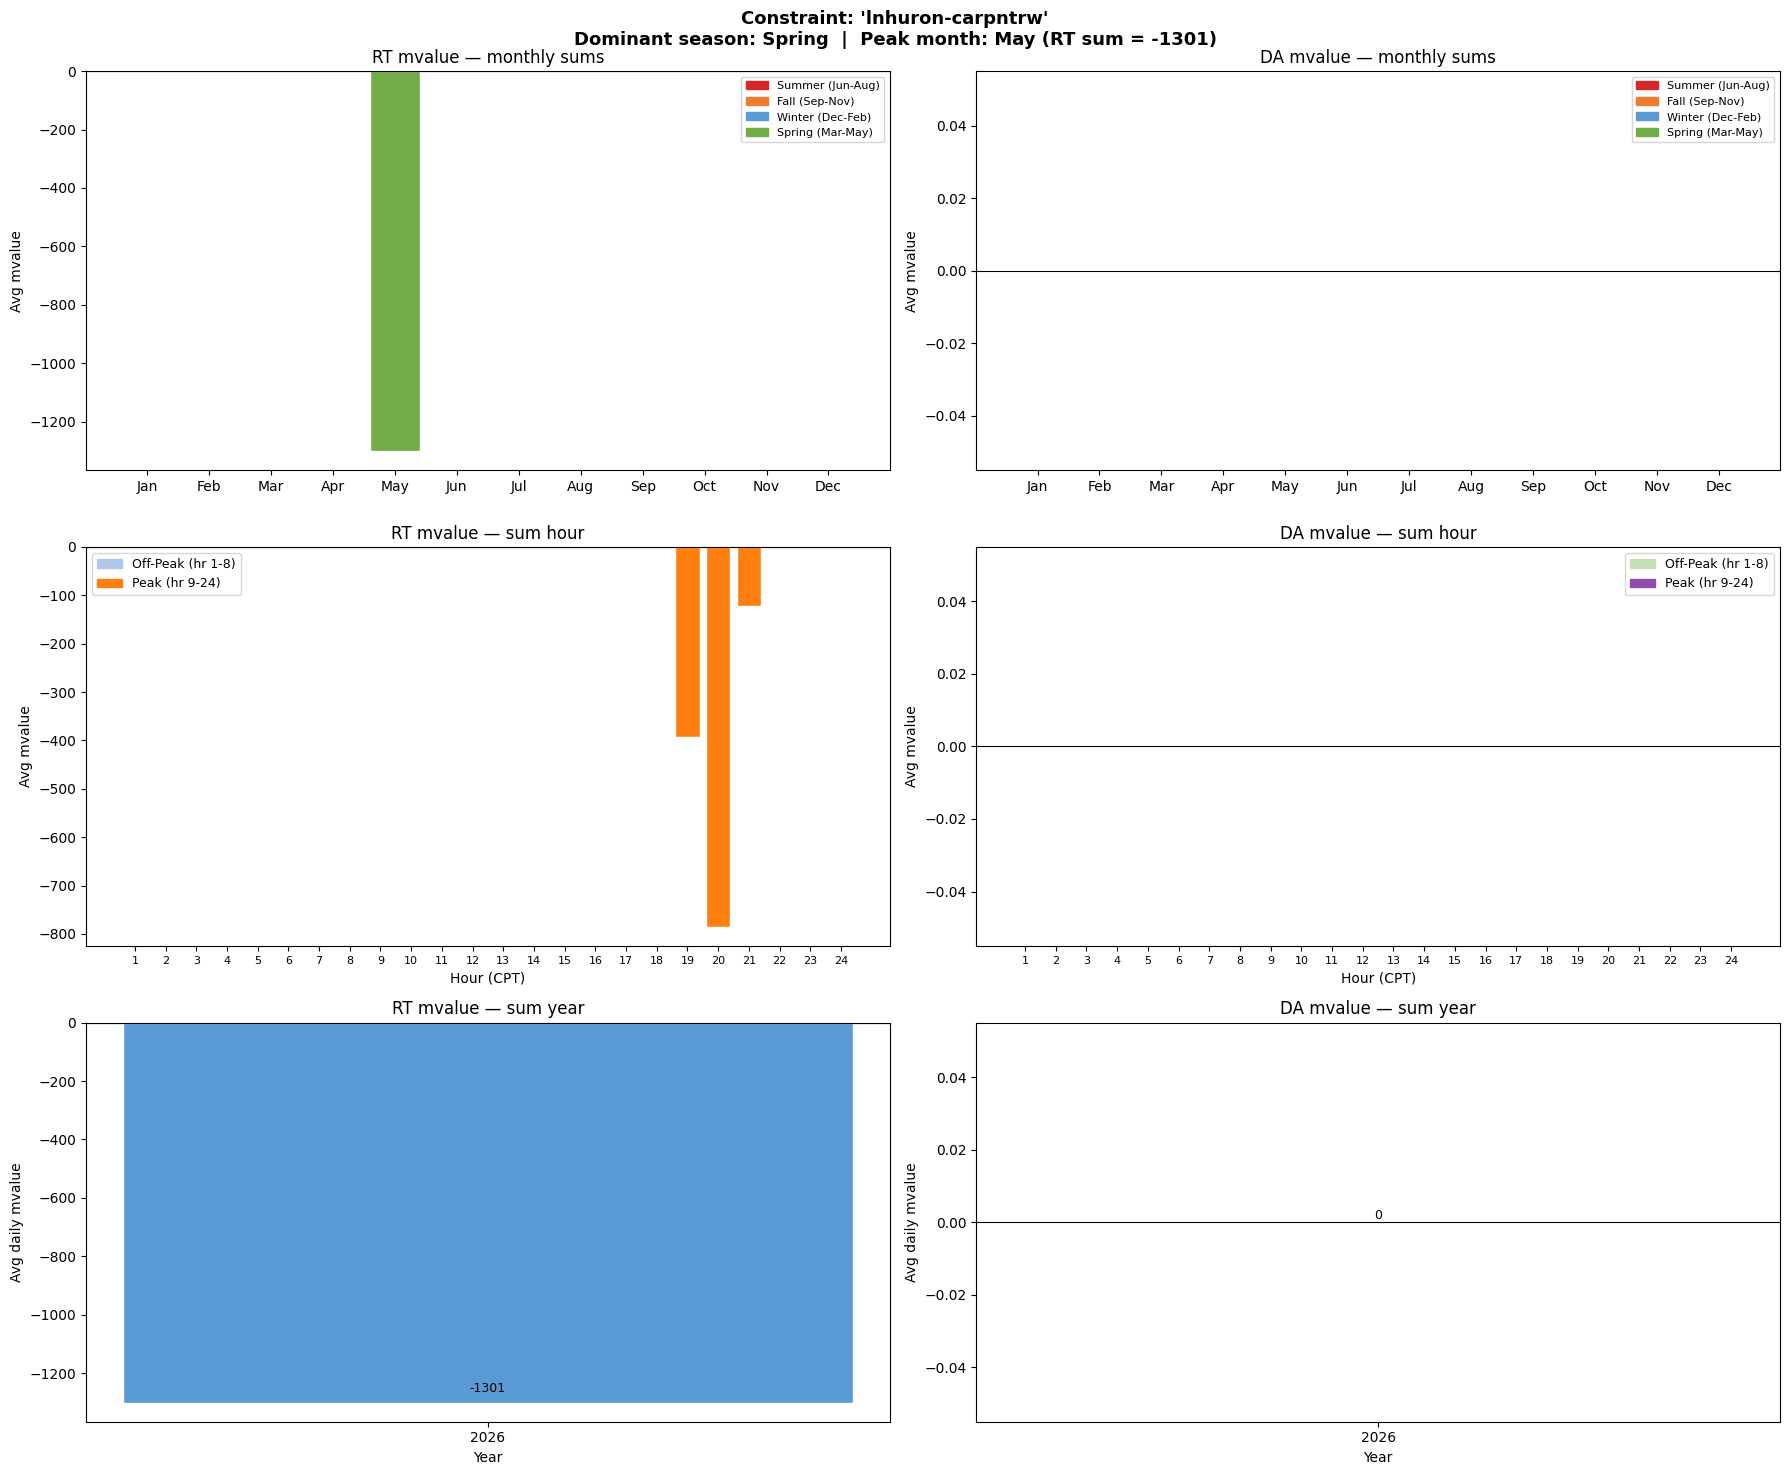

Dominant season : Spring

RT  peak sum   (hr  9-24):   -1301.08  |  off-peak (hr 1-8):       0.00
DA  peak sum   (hr  9-24):       0.00  |  off-peak (hr 1-8):       0.00
'lnhuron-carpntrw'  |  2026-05-18 → 2026-05-28  |  1 days


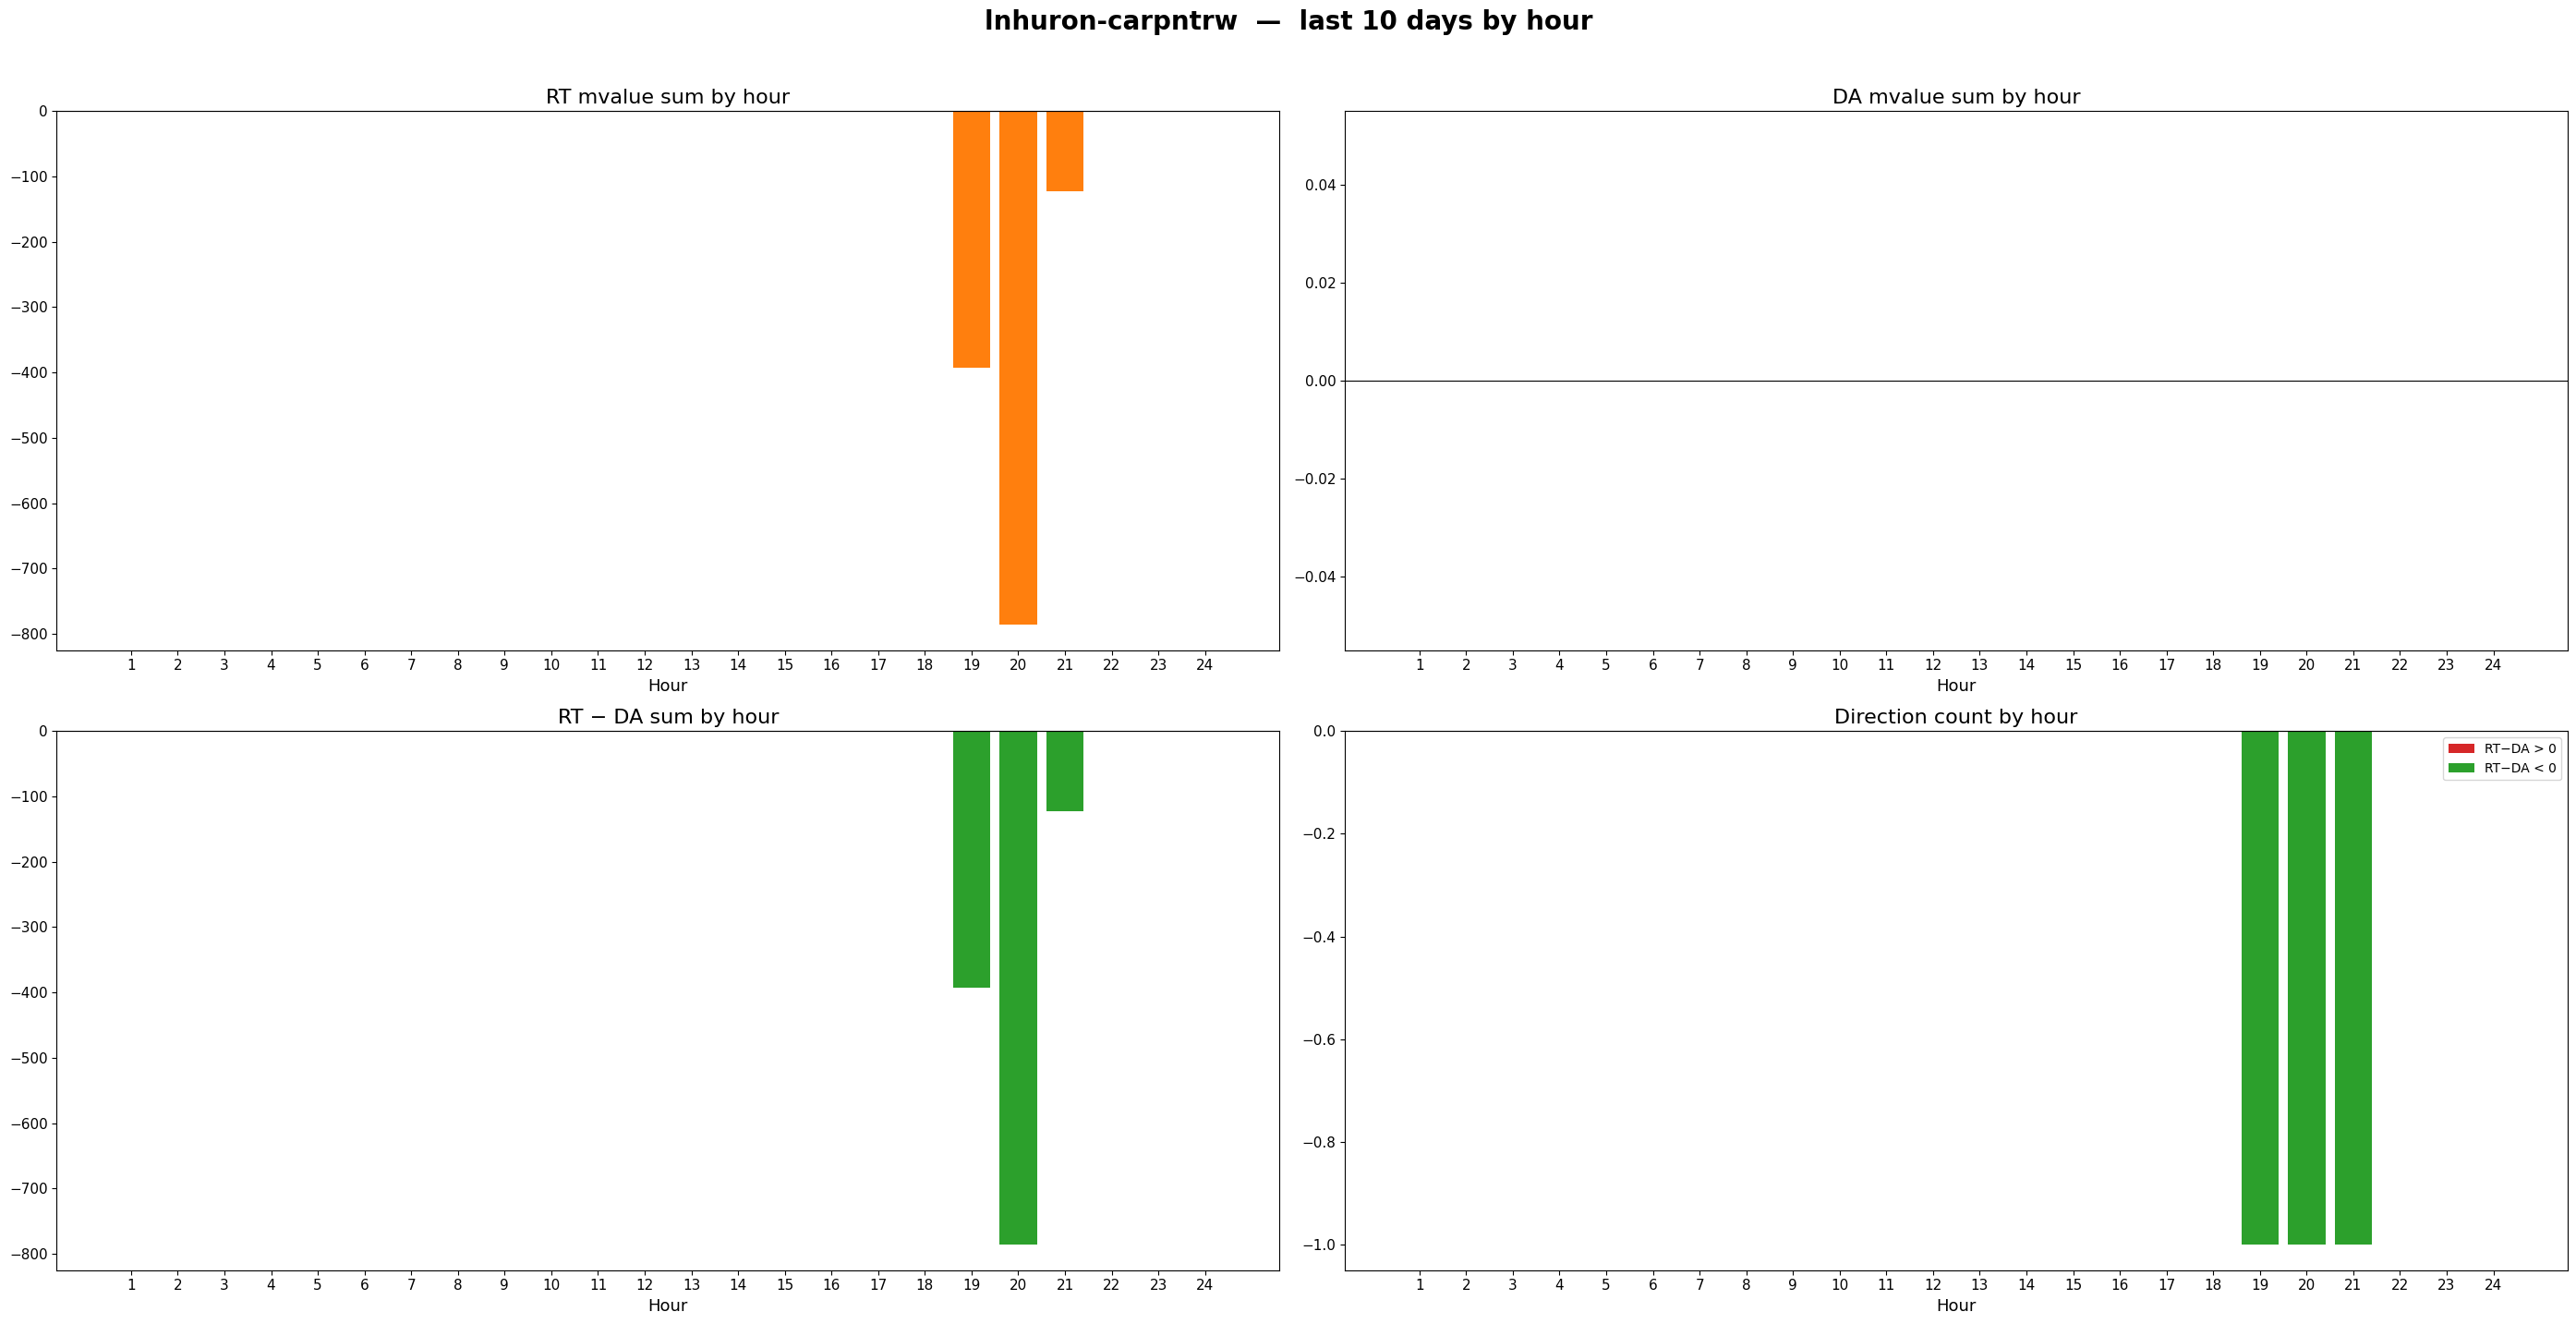


Total rows: 102

  lnhuron-carpntrw


,node_num,dfax,corr,sign_acc,mean_pred,mean_actual,n
0,953,-0.1807,0.998990,0.666667,-78.368650,-60.502533,3.0
1,1371,-0.1807,0.998689,0.666667,-78.368650,-67.041969,3.0
2,924,0.1473,0.998383,1.000000,63.883244,96.978966,3.0
3,878,0.1185,0.997975,1.000000,51.392834,84.446373,3.0
4,947,0.0874,0.997713,1.000000,37.904926,70.531303,3.0
5,1163,0.0826,0.997700,1.000000,35.823190,69.169136,3.0
6,966,-0.0537,0.997656,0.333333,-23.289411,5.979368,3.0
7,1197,0.0818,0.997459,1.000000,35.476235,68.321198,3.0
8,906,-0.0930,0.996622,0.333333,-40.333616,-5.390968,3.0
9,874,0.0882,0.992643,1.000000,38.251881,72.574768,3.0


Constraint  : 'xfmrtech-tech'
Reserve zone: 4  |  Columns: ['rz4_spp_res_zonal_wind_forecast_f', 'rz4_spp_res_zonal_load_forecast_f']
Baseline binding rate: 0.0005  |  Total hours: 17496


,monitored,reserve_zone,fundamental,baseline_prob,cond_prob_top95pct,lift_pct
0,xfmrtech-tech,4,rz4_spp_res_zonal_wind_forecast_f,0.0005,0.0,-1.0
1,xfmrtech-tech,4,rz4_spp_res_zonal_load_forecast_f,0.0005,0.0,-1.0


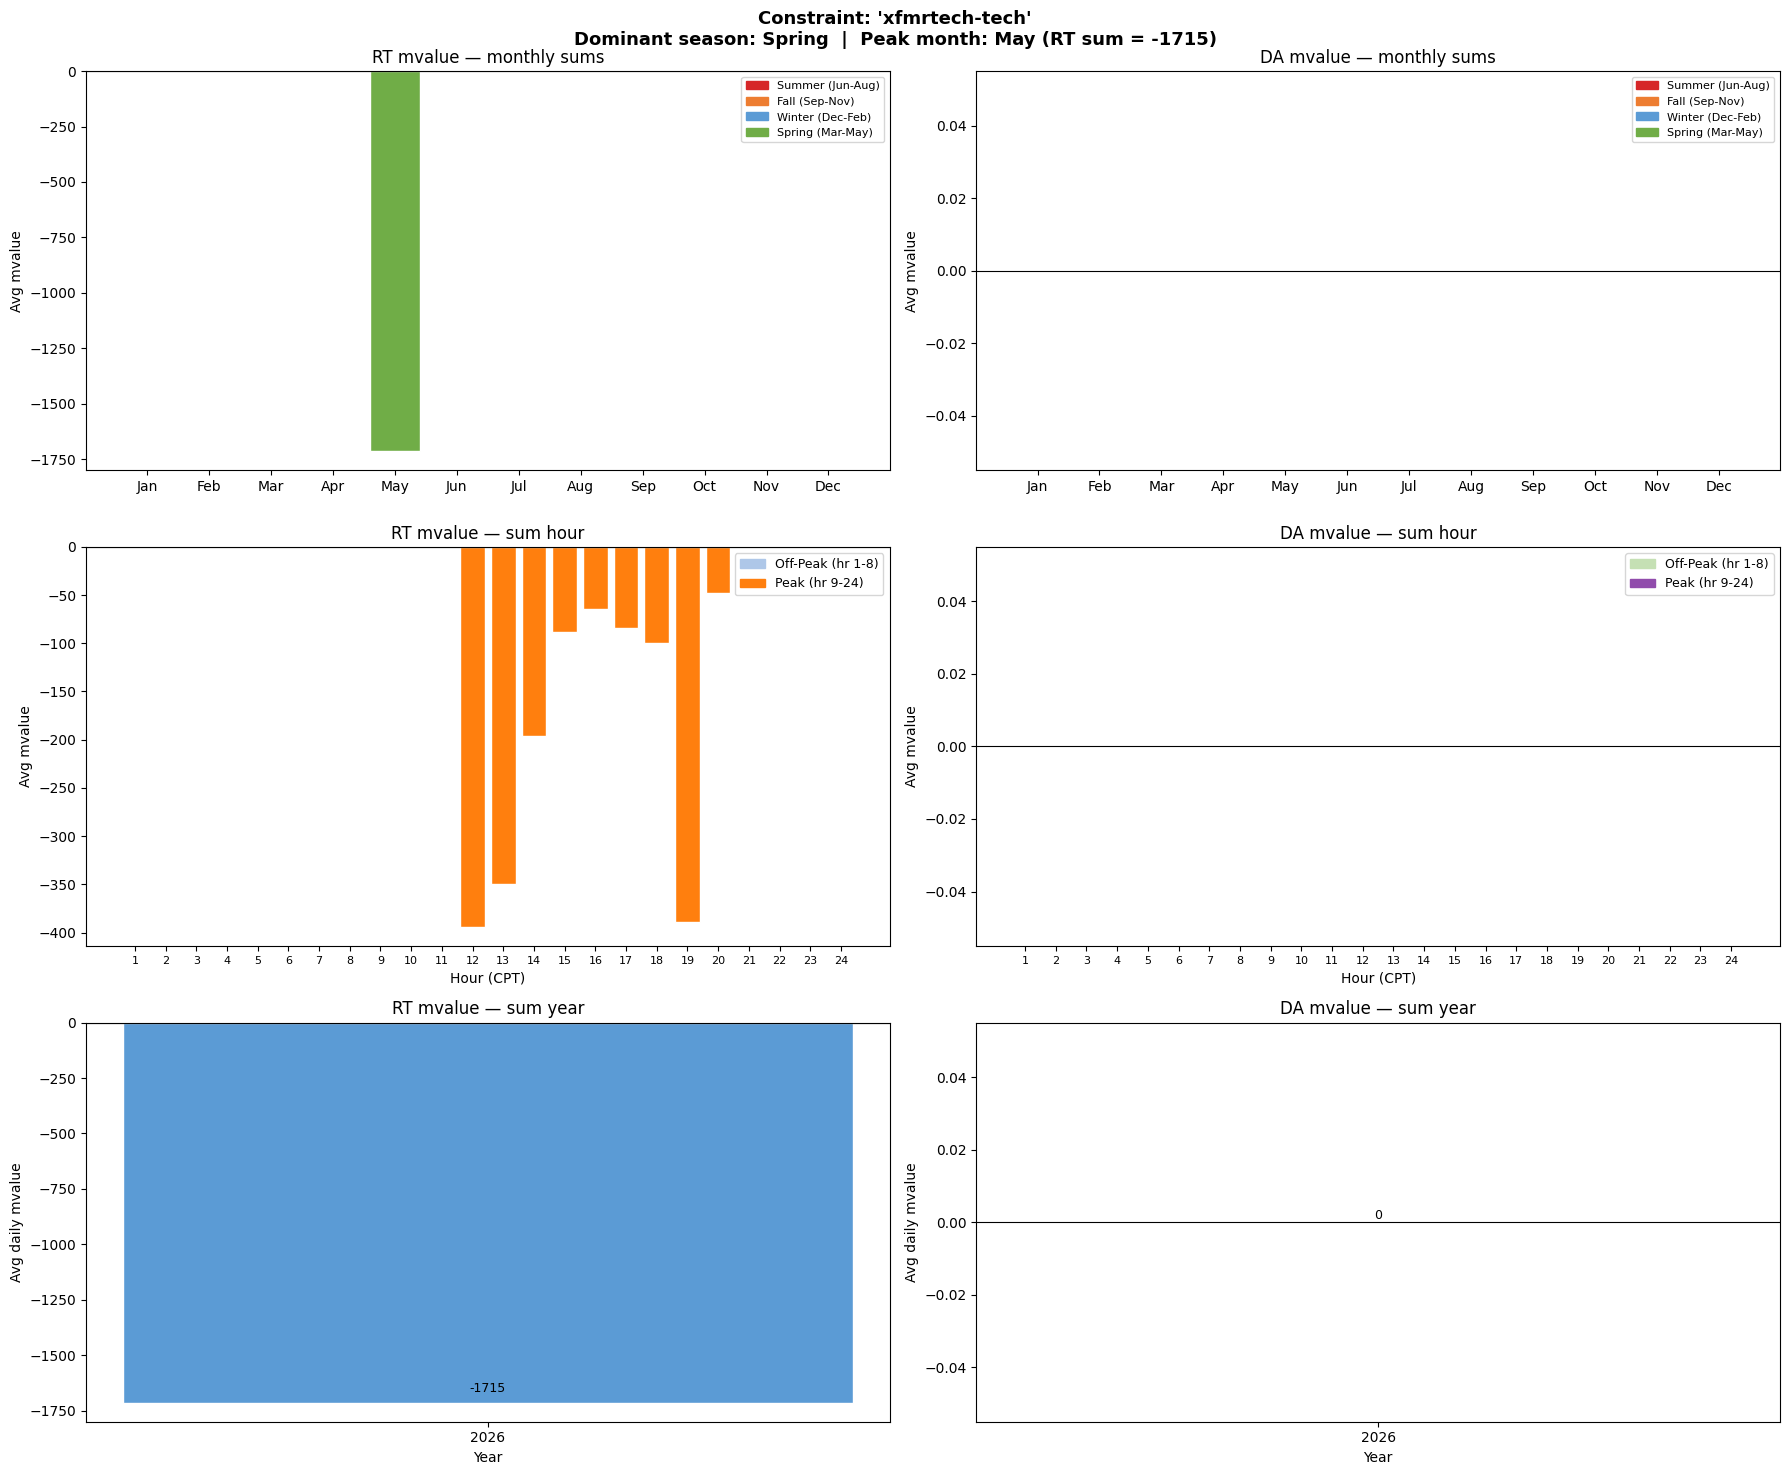

Dominant season : Spring

RT  peak sum   (hr  9-24):   -1714.76  |  off-peak (hr 1-8):       0.00
DA  peak sum   (hr  9-24):       0.00  |  off-peak (hr 1-8):       0.00
'xfmrtech-tech'  |  2026-05-18 → 2026-05-28  |  1 days


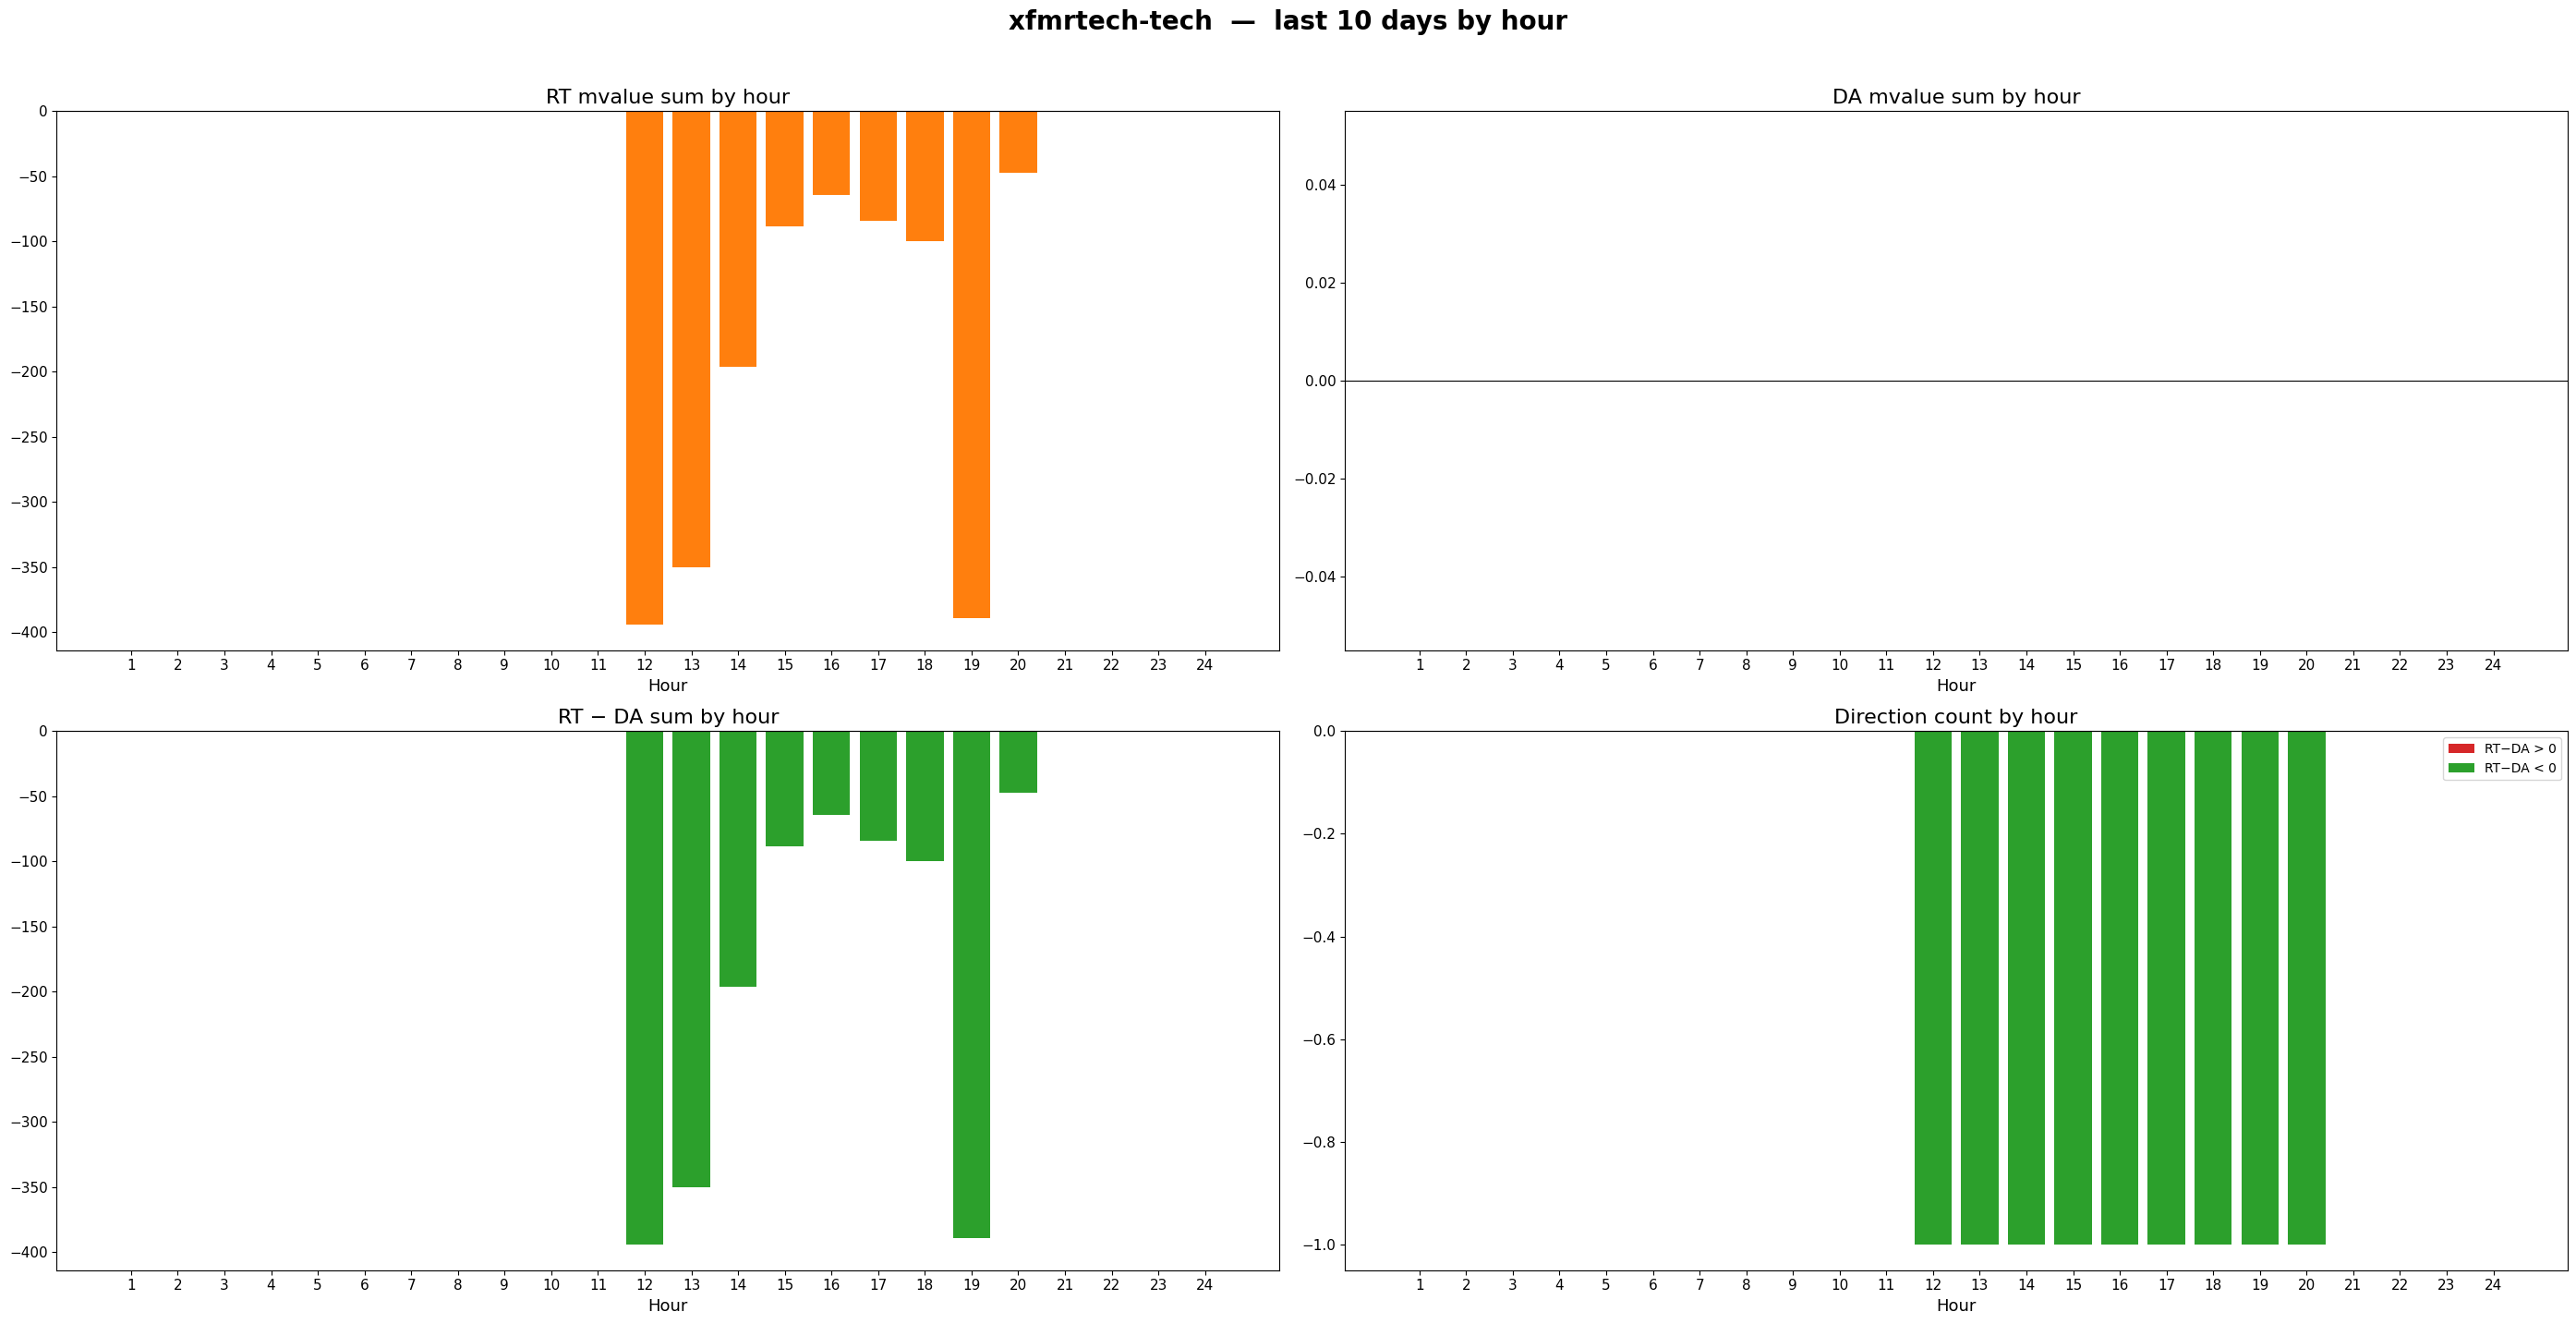

xfmrtech-tech could not find the dfax value


Constraint  : 'lnmidj-pent'
Reserve zone: 4  |  Columns: ['rz4_spp_res_zonal_wind_forecast_f', 'rz4_spp_res_zonal_load_forecast_f']
Baseline binding rate: 0.0008  |  Total hours: 17496


,monitored,reserve_zone,fundamental,baseline_prob,cond_prob_top95pct,lift_pct
0,lnmidj-pent,4,rz4_spp_res_zonal_wind_forecast_f,0.0008,0.0,-1.0
1,lnmidj-pent,4,rz4_spp_res_zonal_load_forecast_f,0.0008,0.0,-1.0


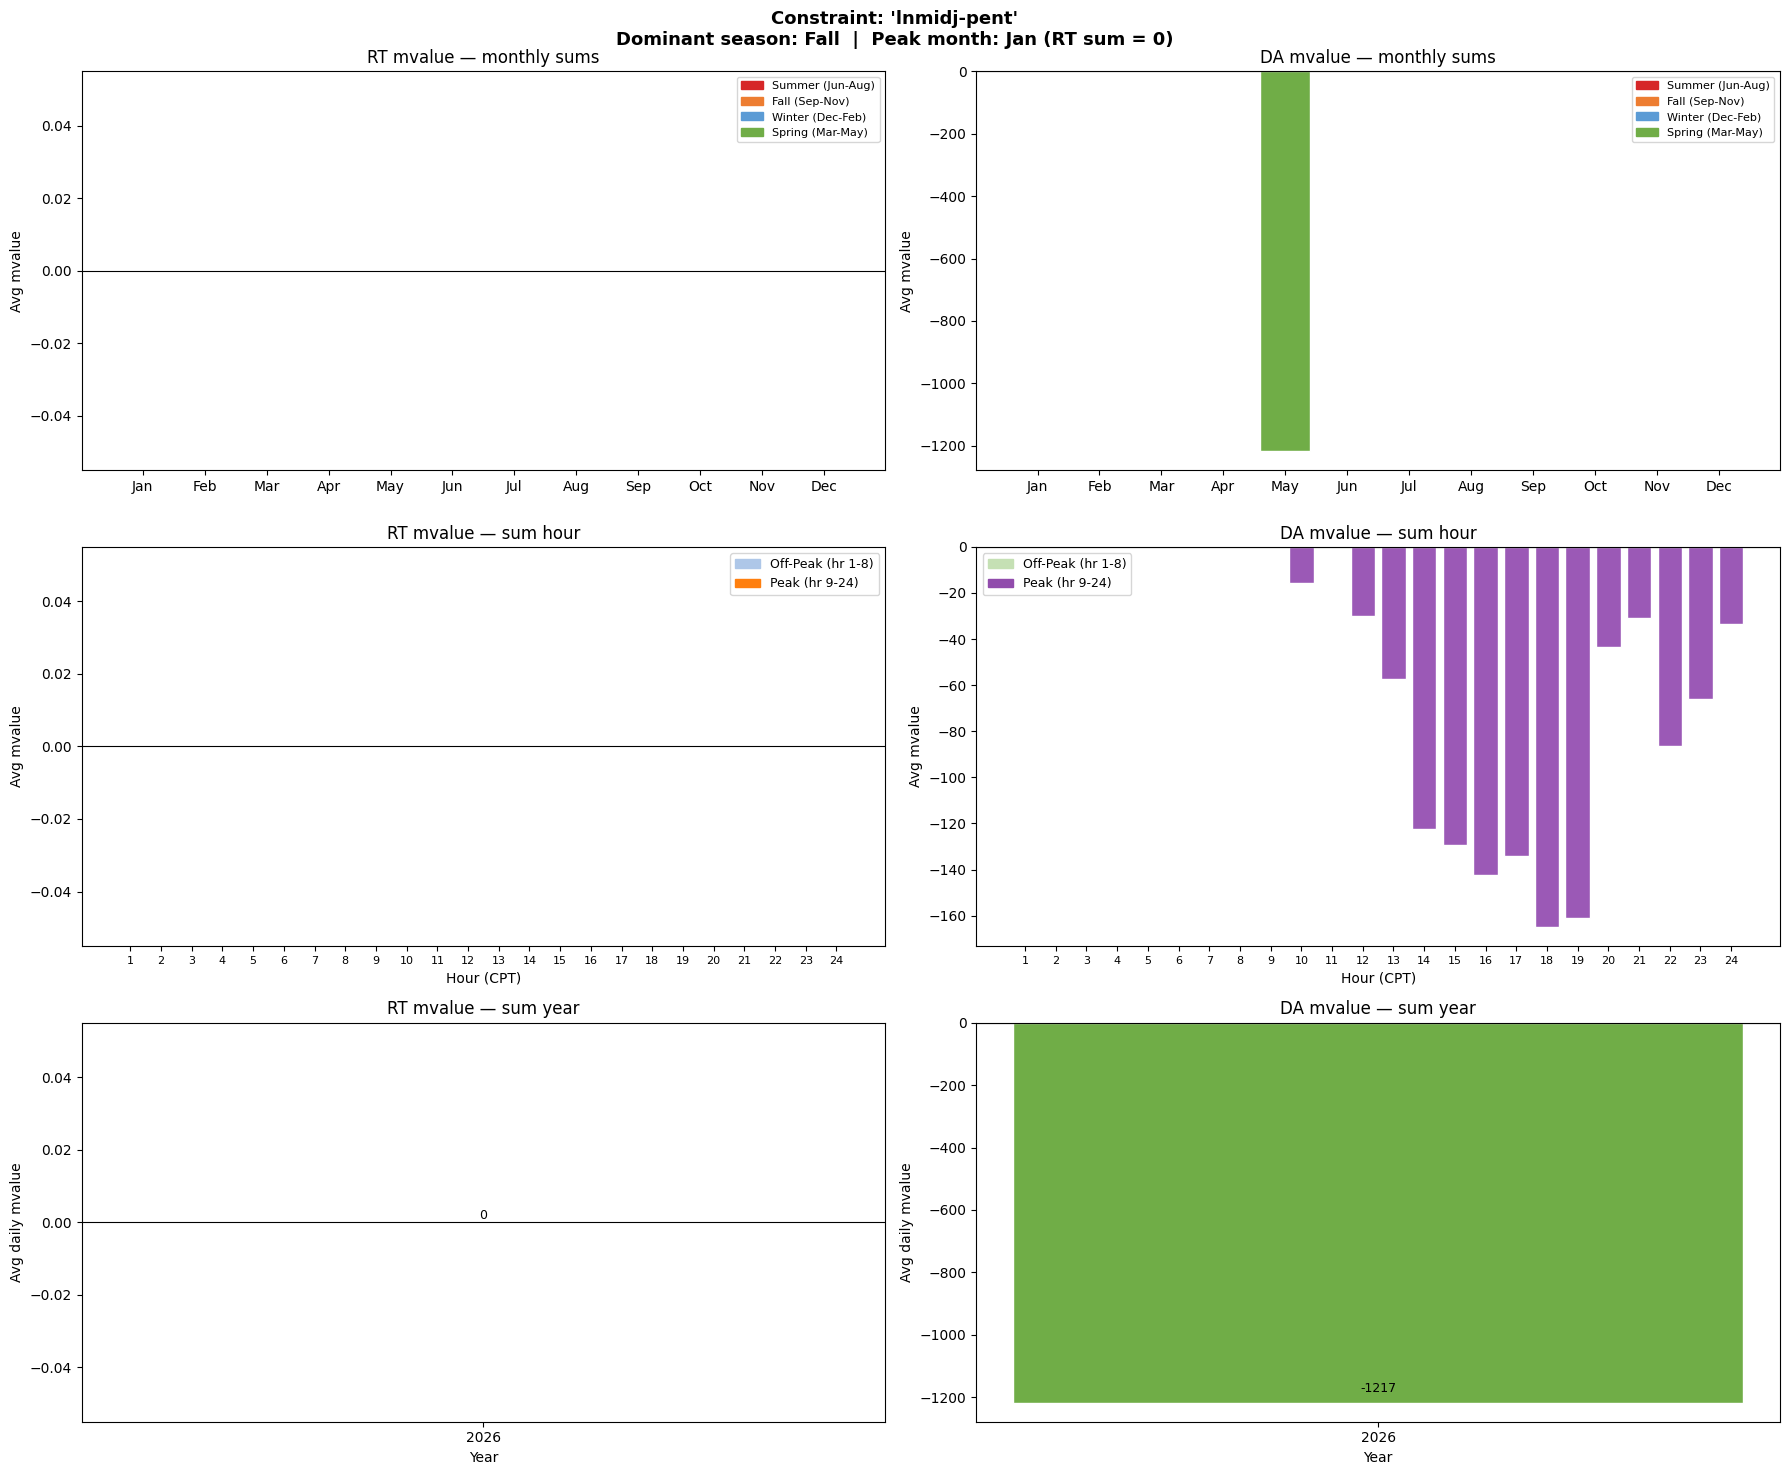

Dominant season : Fall

RT  peak sum   (hr  9-24):       0.00  |  off-peak (hr 1-8):       0.00
DA  peak sum   (hr  9-24):   -1217.03  |  off-peak (hr 1-8):       0.00
'lnmidj-pent'  |  2026-05-18 → 2026-05-28  |  1 days


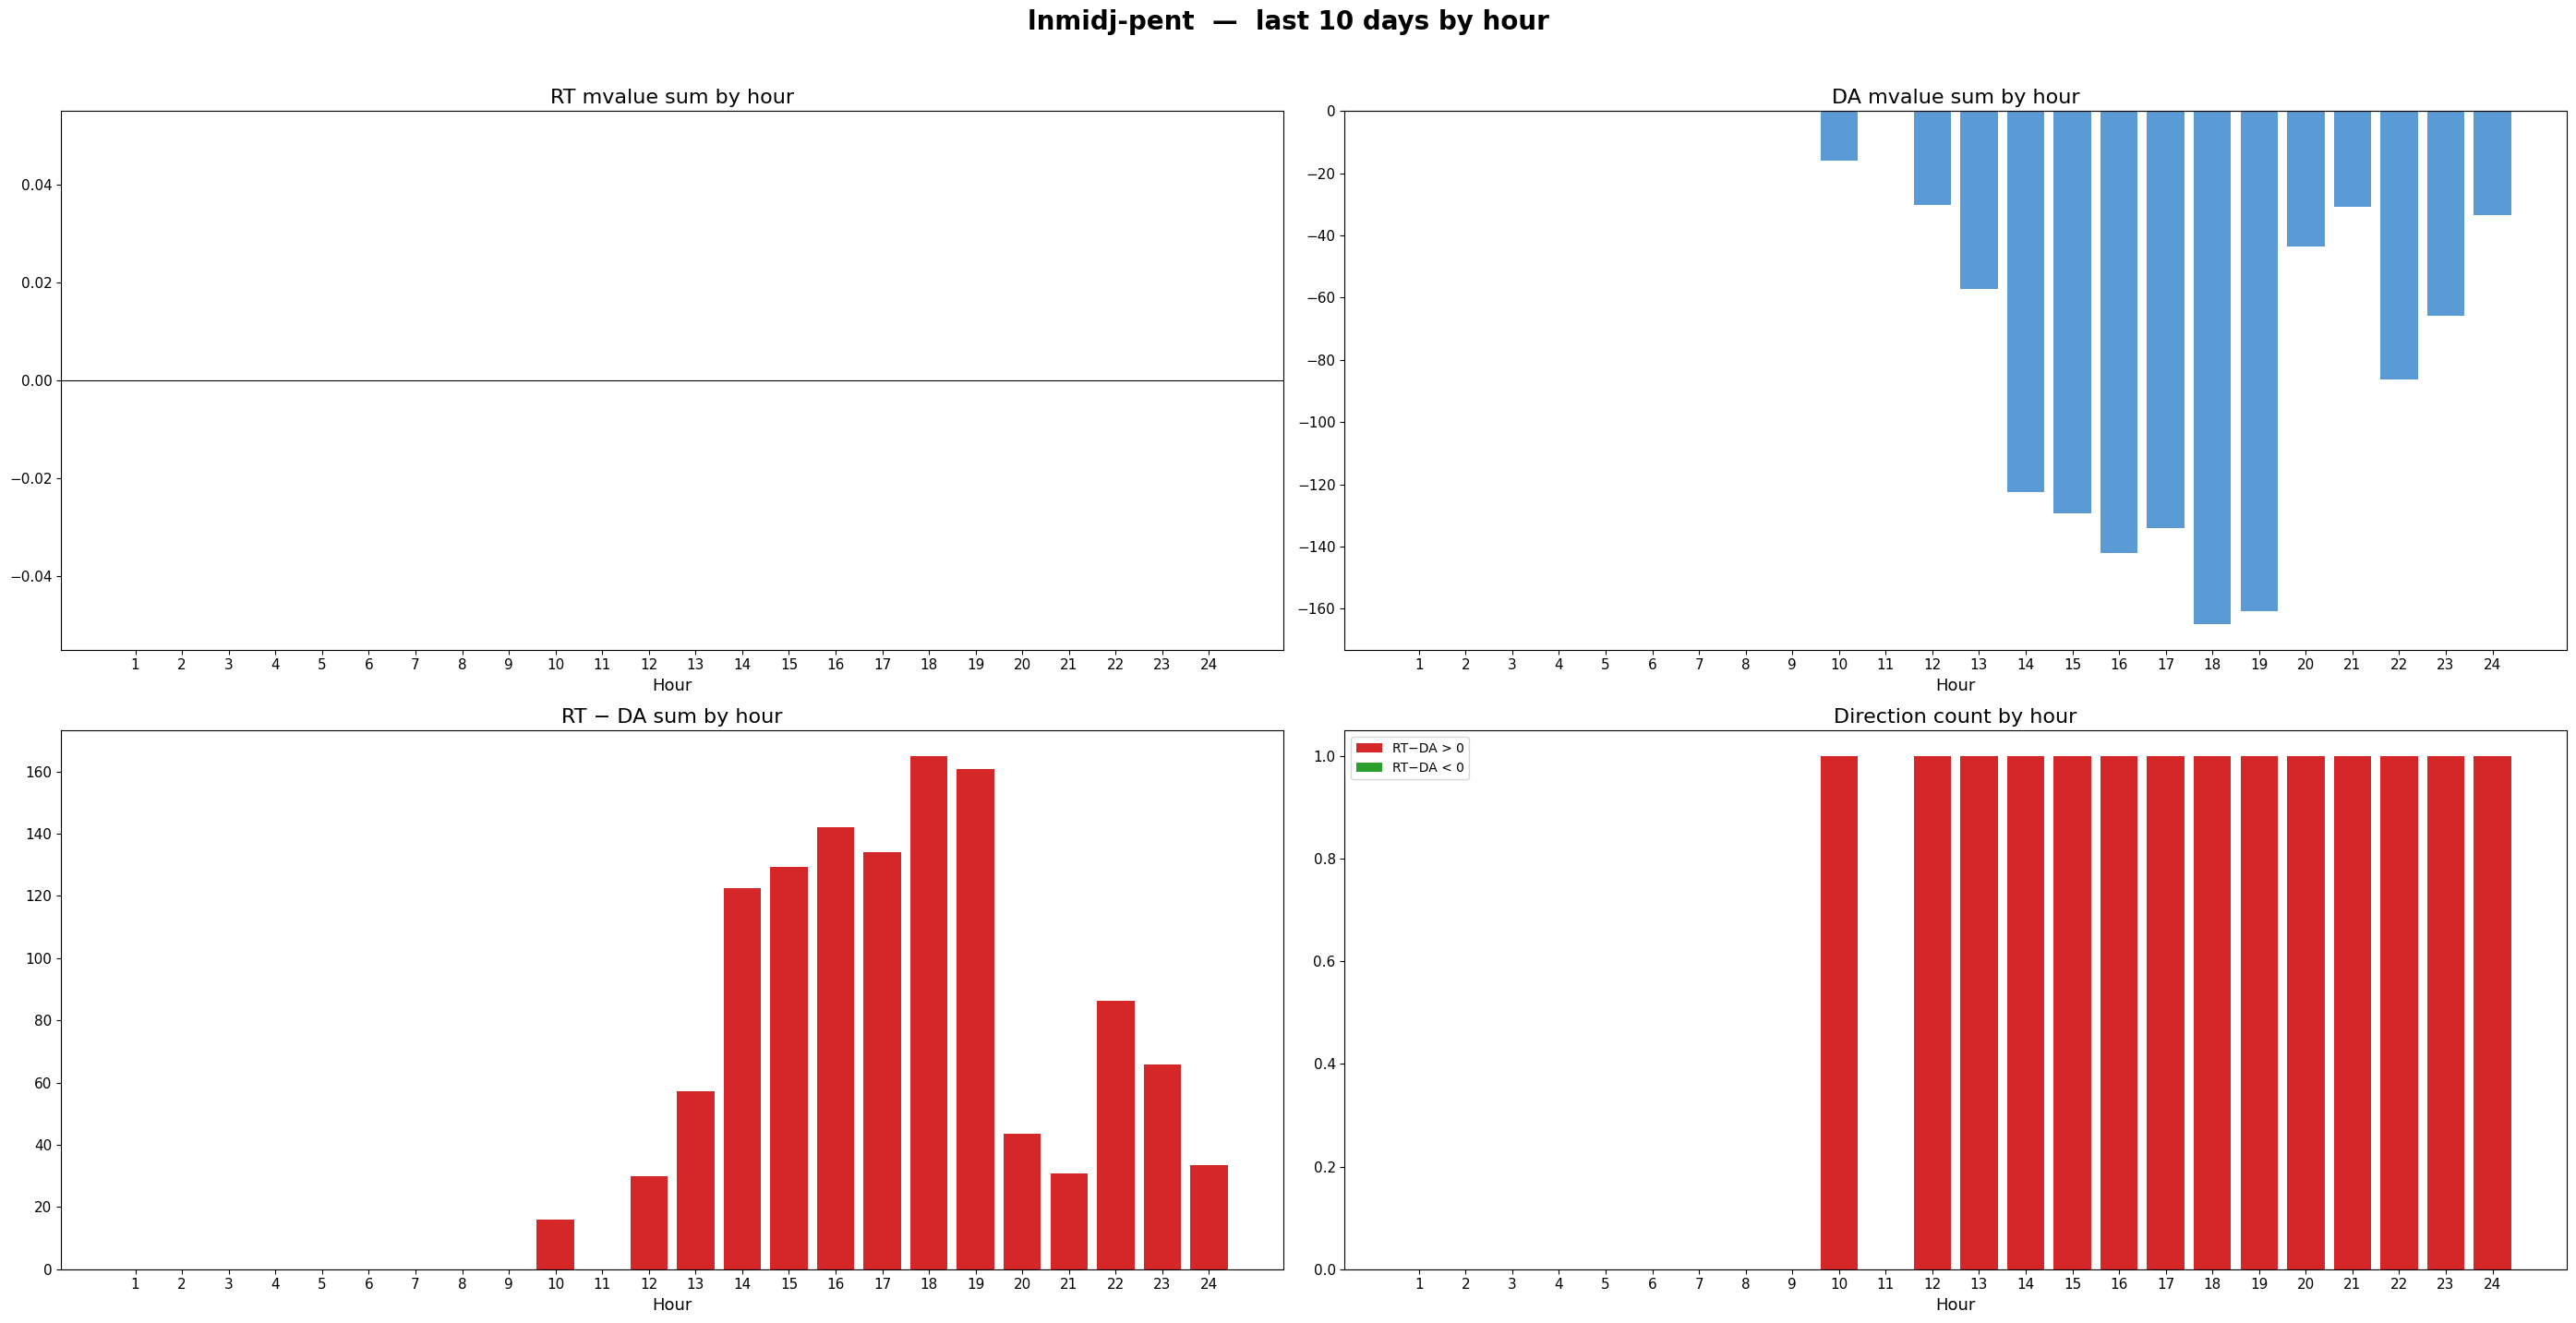

lnmidj-pent could not find the dfax value


Constraint  : 'lneeur-vaug_rev23'
Reserve zone: 4  |  Columns: ['rz4_spp_res_zonal_wind_forecast_f', 'rz4_spp_res_zonal_load_forecast_f']
Baseline binding rate: 0.0019  |  Total hours: 17496


,monitored,reserve_zone,fundamental,baseline_prob,cond_prob_top95pct,lift_pct
0,lneeur-vaug_rev23,4,rz4_spp_res_zonal_wind_forecast_f,0.0019,0.0,-1.0
1,lneeur-vaug_rev23,4,rz4_spp_res_zonal_load_forecast_f,0.0019,0.0,-1.0


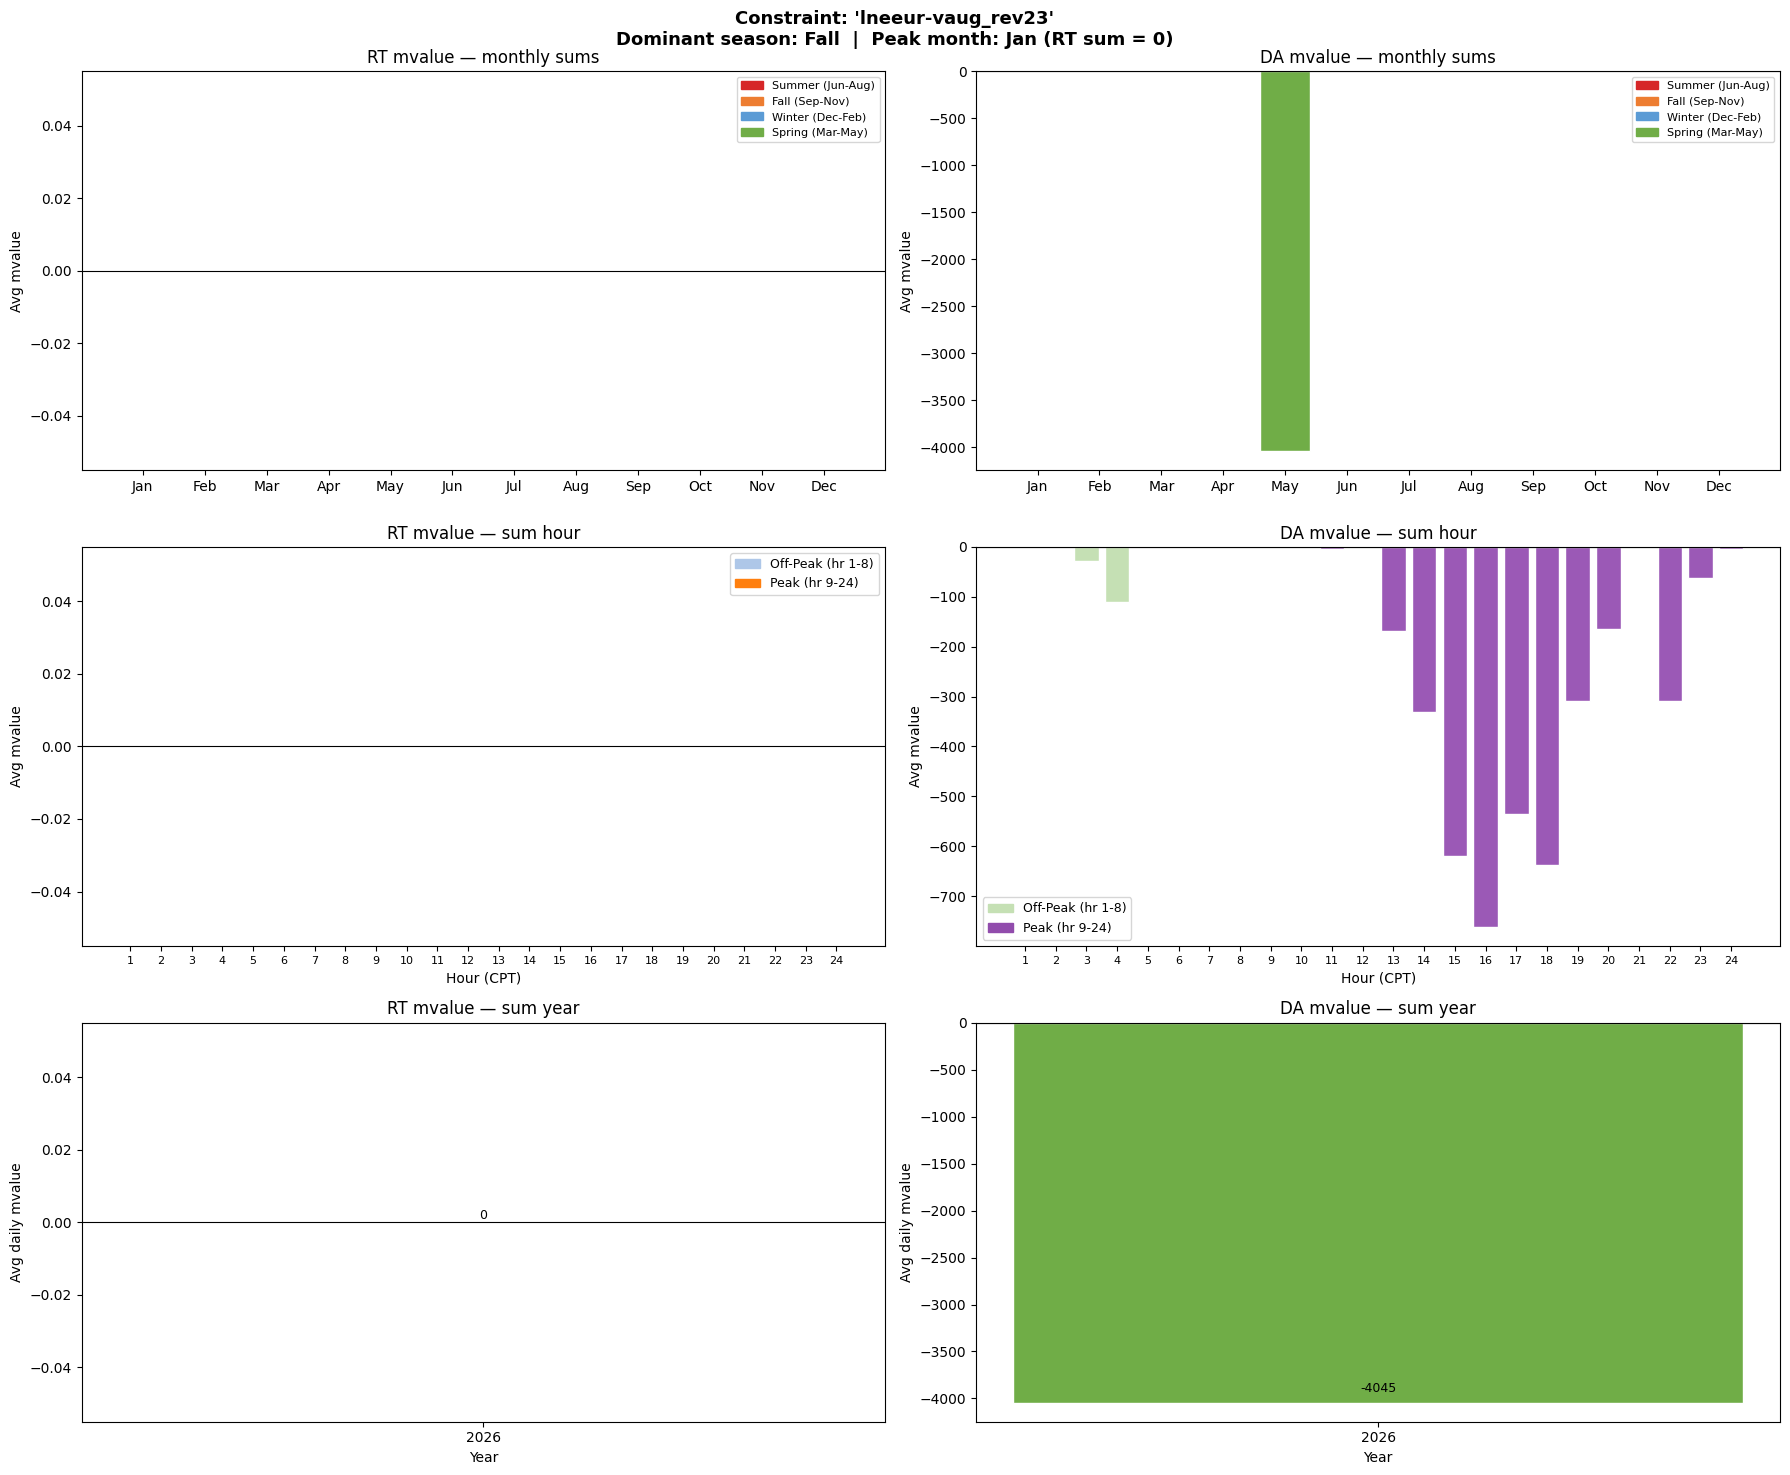

Dominant season : Fall

RT  peak sum   (hr  9-24):       0.00  |  off-peak (hr 1-8):       0.00
DA  peak sum   (hr  9-24):   -3906.88  |  off-peak (hr 1-8):    -138.16
'lneeur-vaug_rev23'  |  2026-05-18 → 2026-05-28  |  3 days


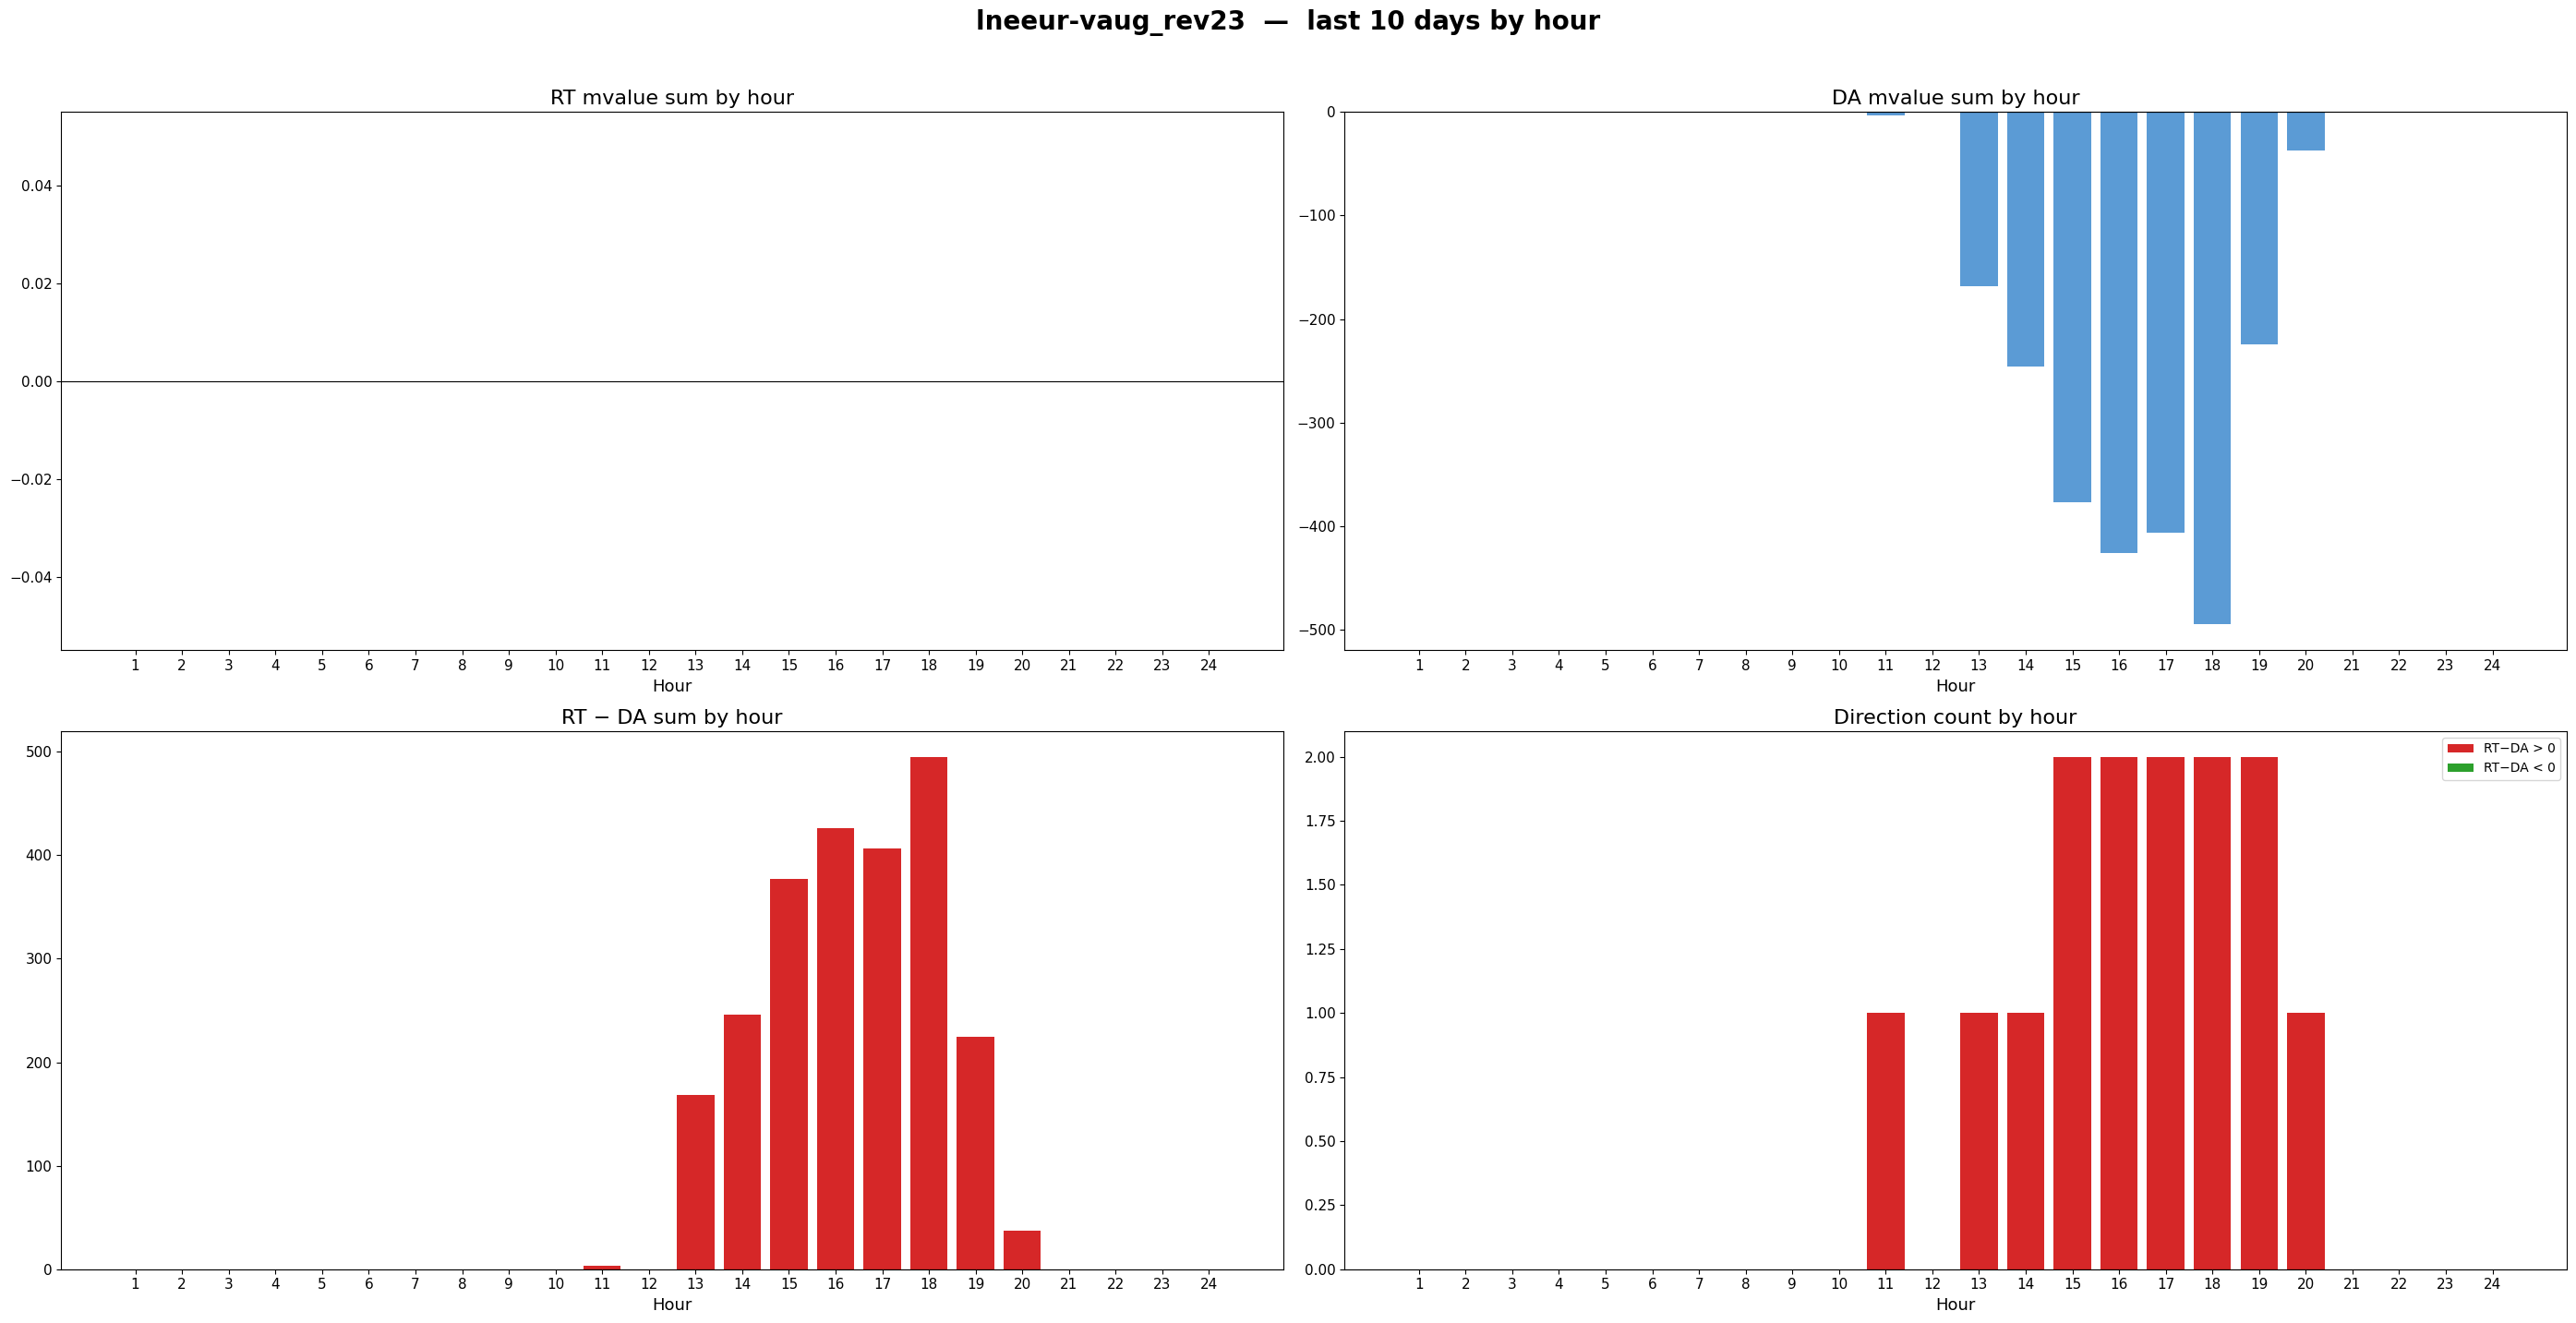

lneeur-vaug_rev23 could not find the dfax value


Constraint  : 'lnanta_tp-anita'
Reserve zone: 4  |  Columns: ['rz4_spp_res_zonal_wind_forecast_f', 'rz4_spp_res_zonal_load_forecast_f']
Baseline binding rate: 0.0070  |  Total hours: 17496


,monitored,reserve_zone,fundamental,baseline_prob,cond_prob_top95pct,lift_pct
1,lnanta_tp-anita,4,rz4_spp_res_zonal_load_forecast_f,0.007,0.0011,-0.84
0,lnanta_tp-anita,4,rz4_spp_res_zonal_wind_forecast_f,0.007,0.0000,-1.00


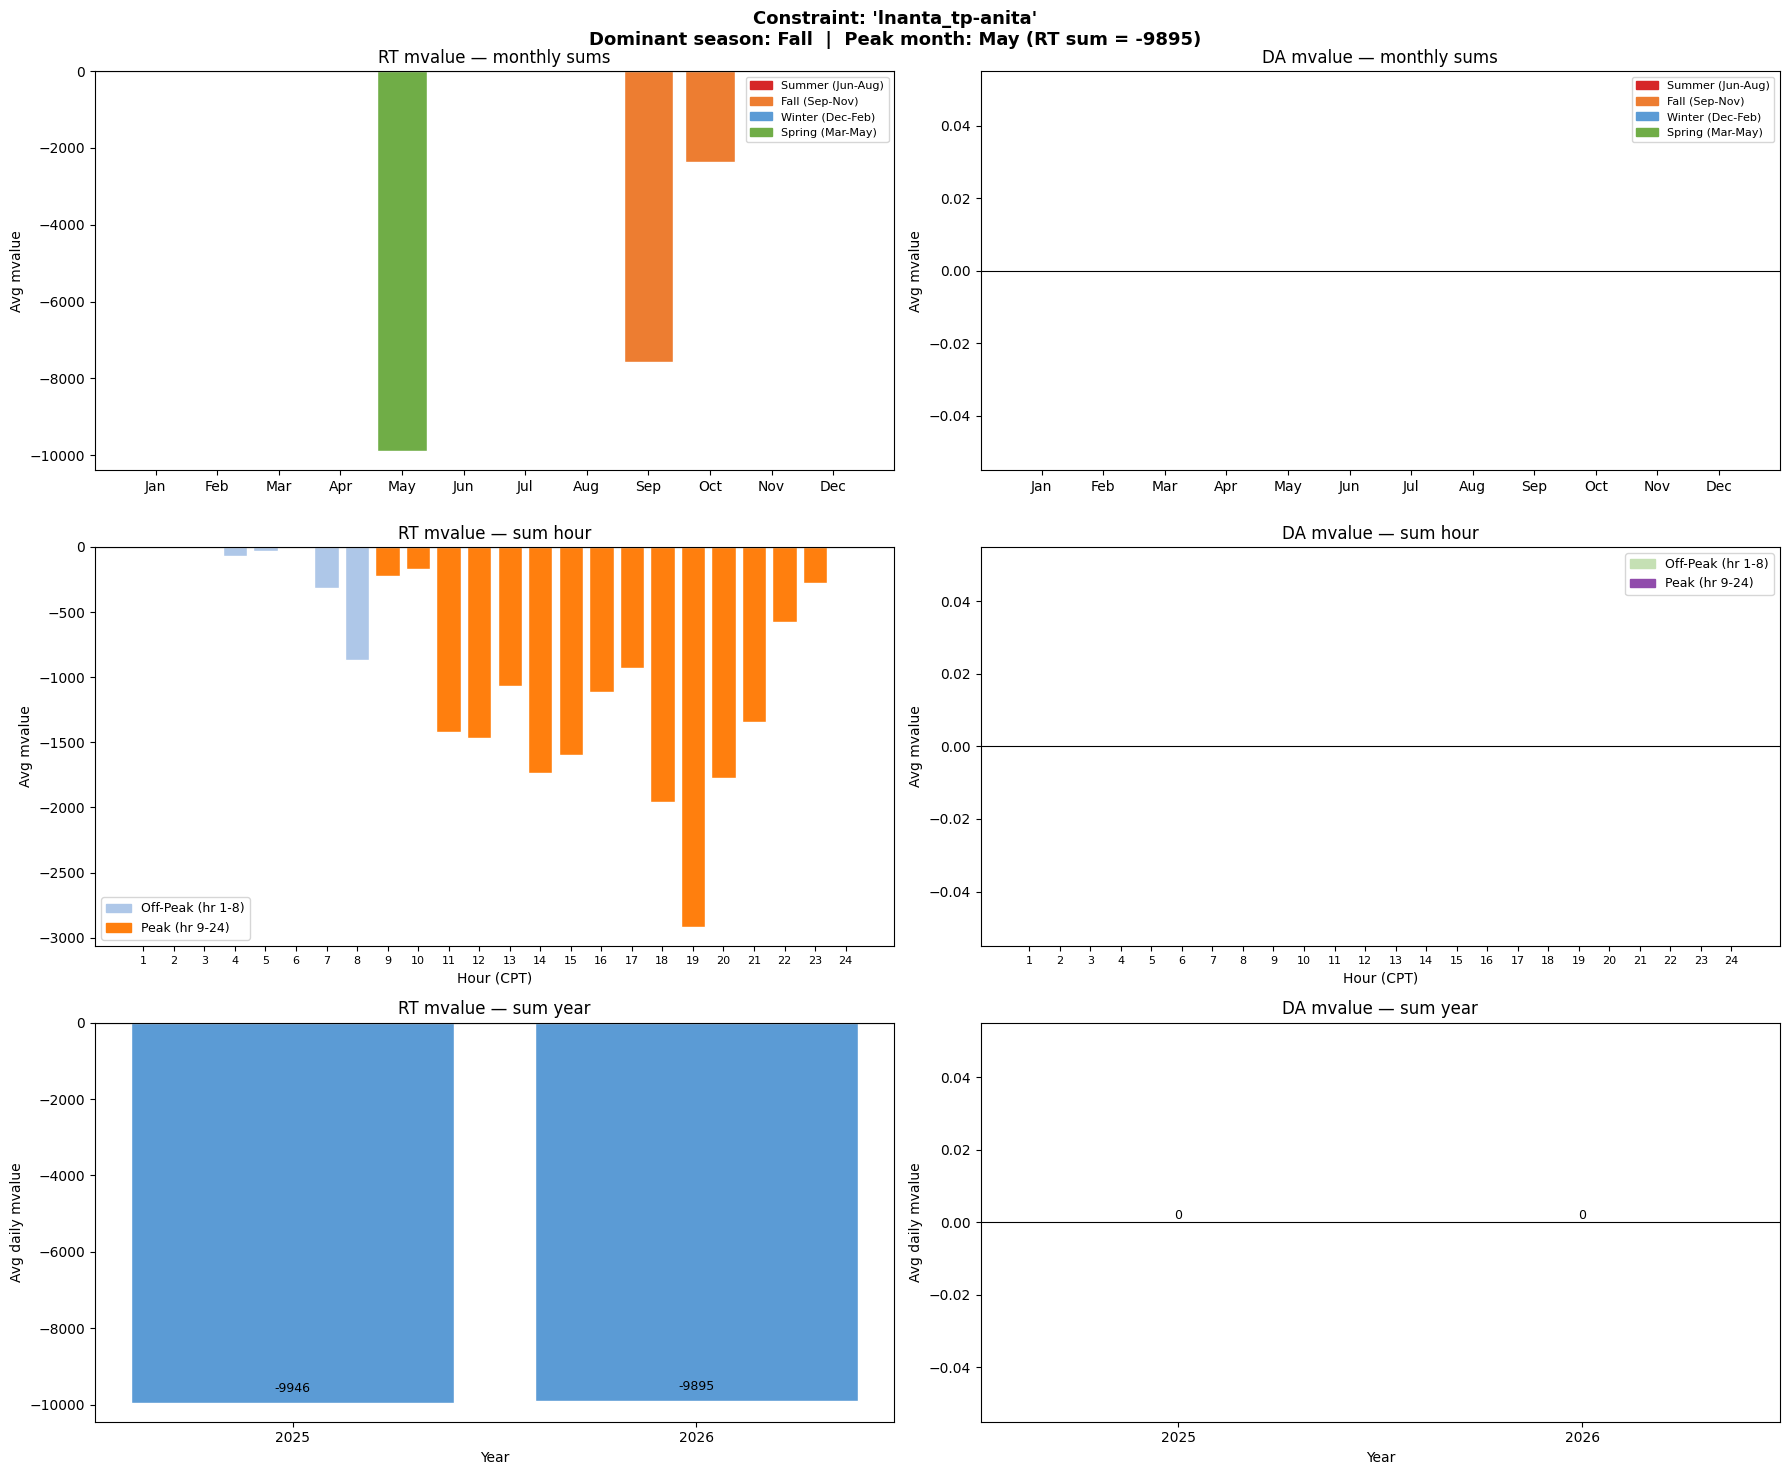

Dominant season : Fall

RT  peak sum   (hr  9-24):  -18564.55  |  off-peak (hr 1-8):   -1277.21
DA  peak sum   (hr  9-24):       0.00  |  off-peak (hr 1-8):       0.00
'lnanta_tp-anita'  |  2026-05-18 → 2026-05-28  |  3 days


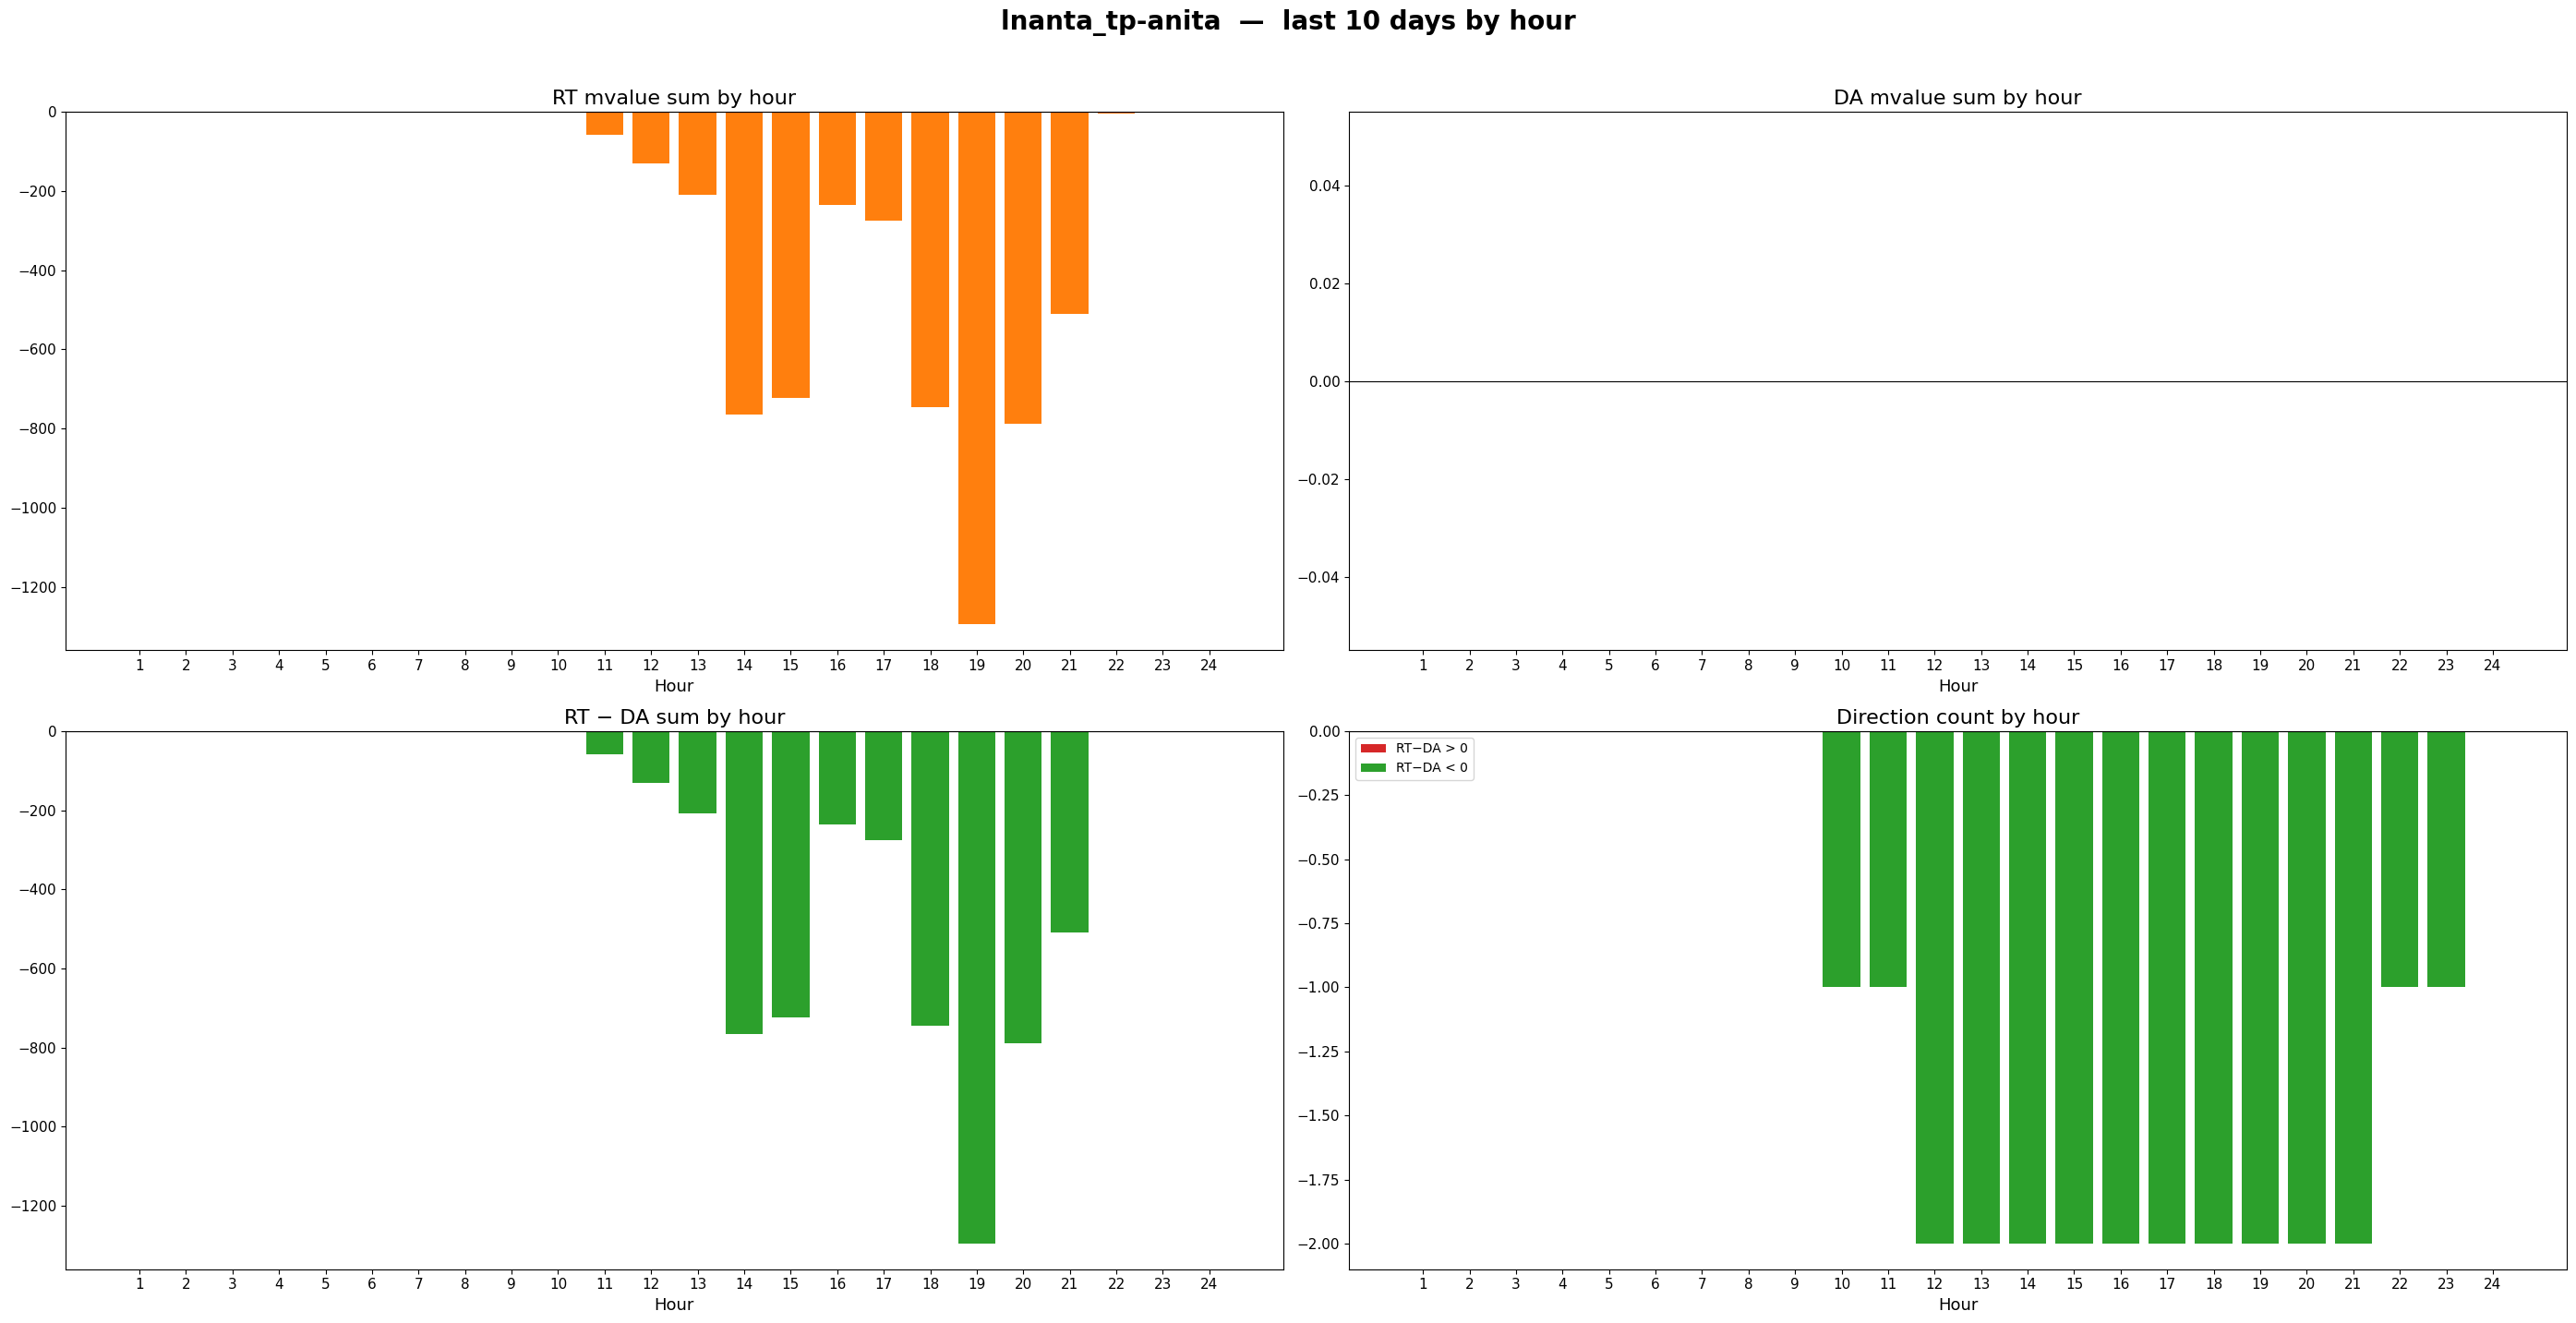


Total rows: 1107

  lnanta_tp-anita


,node_num,dfax,corr,sign_acc,mean_pred,mean_actual,n
0,921,-0.6197,0.743217,0.804878,-99.966947,-65.399246,123.0
1,920,-0.6197,0.743215,0.804878,-99.966947,-65.378372,123.0
2,922,-0.6197,0.743087,0.804878,-99.966947,-65.412857,123.0
3,1740,0.1091,0.670405,0.630769,20.564054,41.977821,65.0
4,928,0.1098,0.607556,0.585366,17.712394,37.695992,123.0
5,1429,0.1091,0.606360,0.585366,17.599474,37.642776,123.0
6,2048,0.0573,0.596698,0.761905,13.499972,45.780468,42.0
7,2049,0.0573,0.596698,0.761905,13.499972,45.780468,42.0
8,1683,-0.0952,-0.160305,0.747967,-15.357194,-0.853206,123.0


Constraint  : 'lnlenexa-shwnmsn5'
Reserve zone: 4  |  Columns: ['rz4_spp_res_zonal_wind_forecast_f', 'rz4_spp_res_zonal_load_forecast_f']
Baseline binding rate: 0.0067  |  Total hours: 17496


,monitored,reserve_zone,fundamental,baseline_prob,cond_prob_top95pct,lift_pct
0,lnlenexa-shwnmsn5,4,rz4_spp_res_zonal_wind_forecast_f,0.0067,0.0149,1.2
1,lnlenexa-shwnmsn5,4,rz4_spp_res_zonal_load_forecast_f,0.0067,0.0000,-1.0


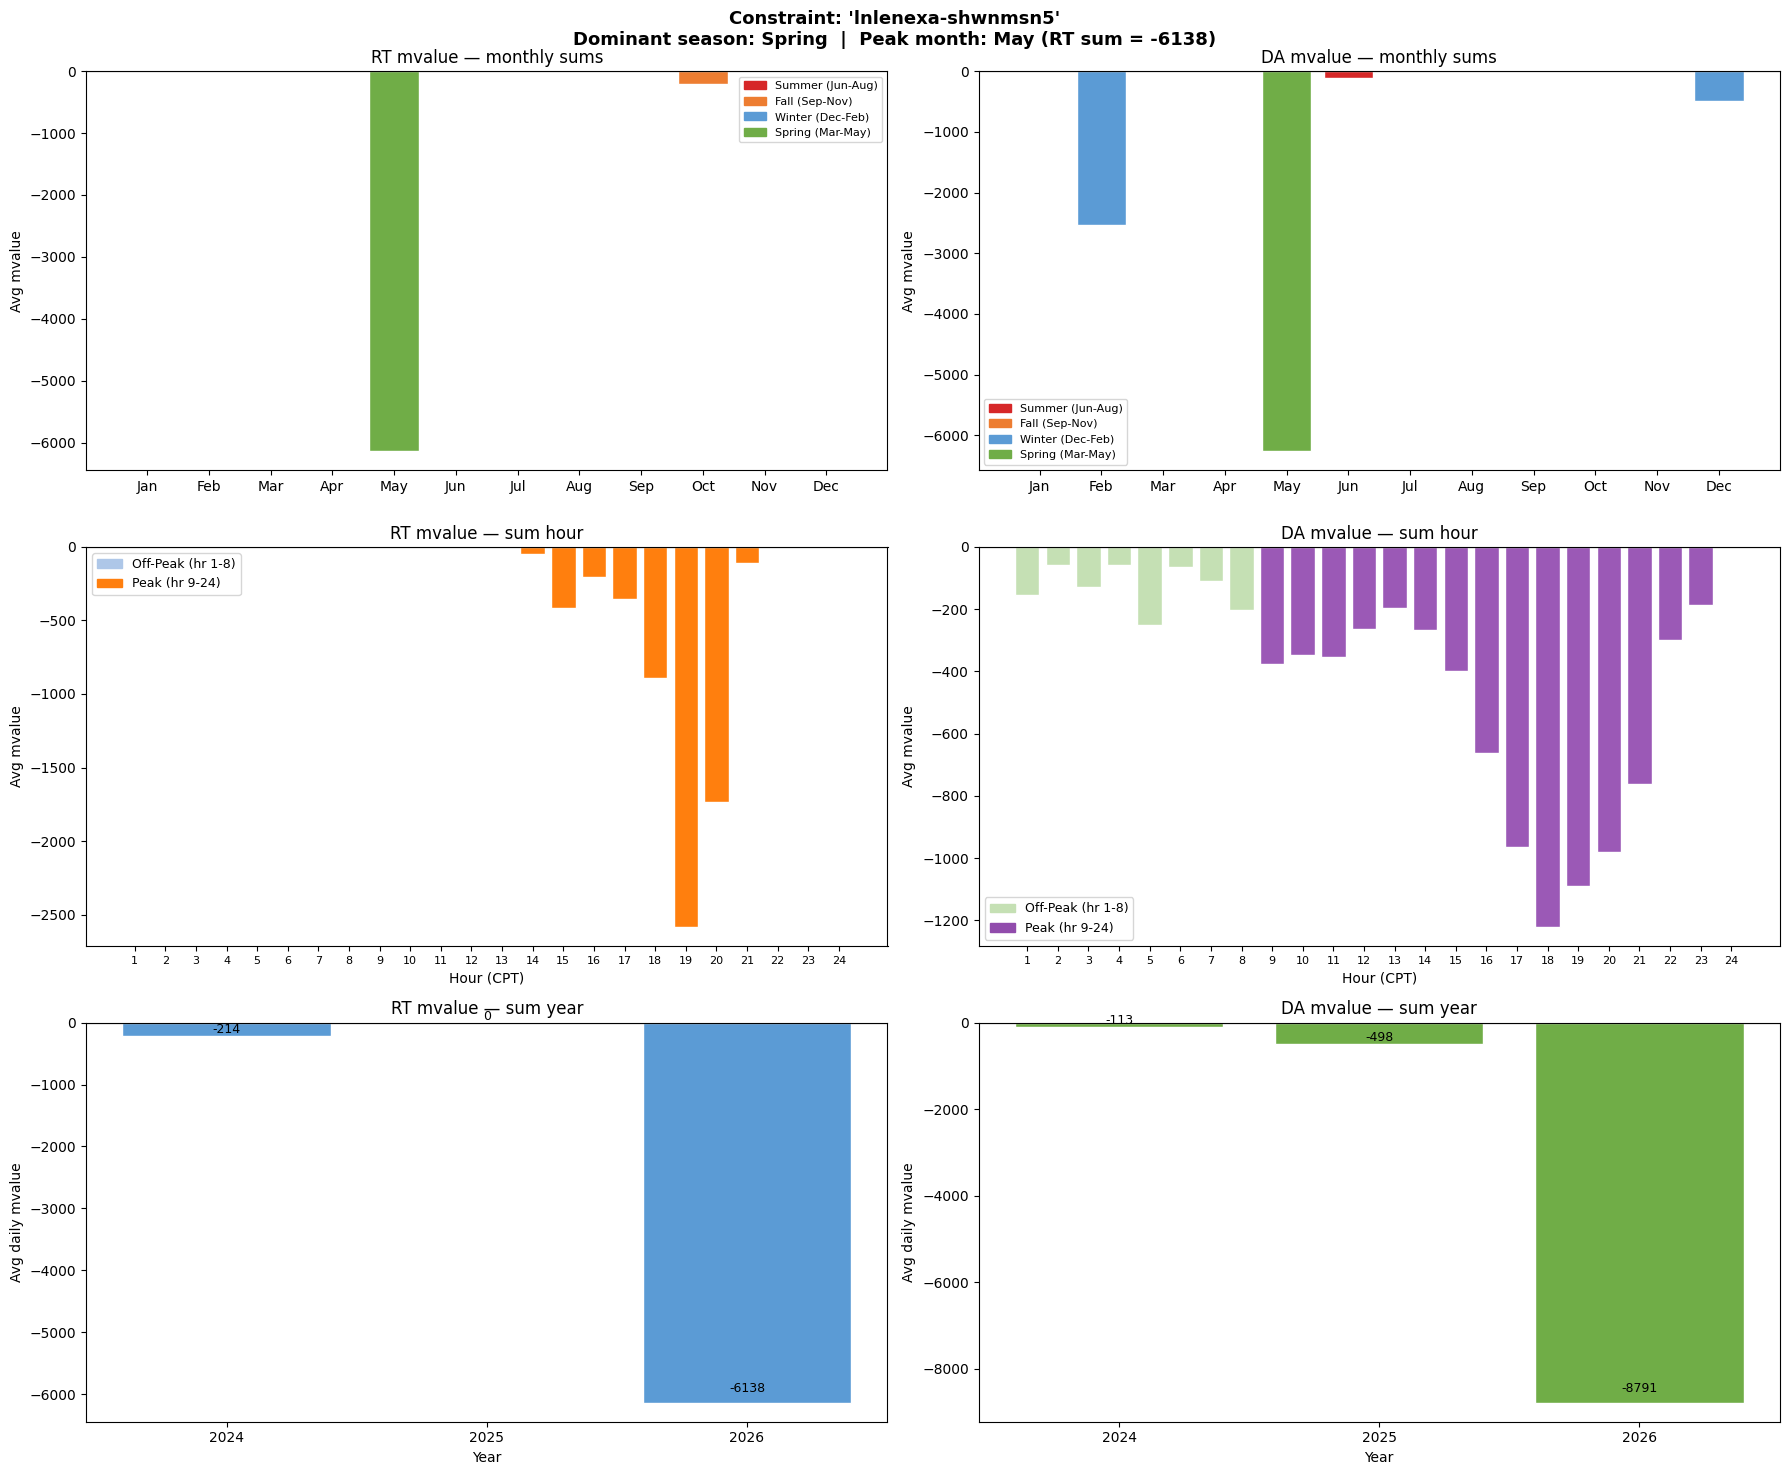

Dominant season : Spring

RT  peak sum   (hr  9-24):   -6352.00  |  off-peak (hr 1-8):       0.00
DA  peak sum   (hr  9-24):   -8370.20  |  off-peak (hr 1-8):   -1031.59
'lnlenexa-shwnmsn5'  |  2026-05-18 → 2026-05-28  |  3 days


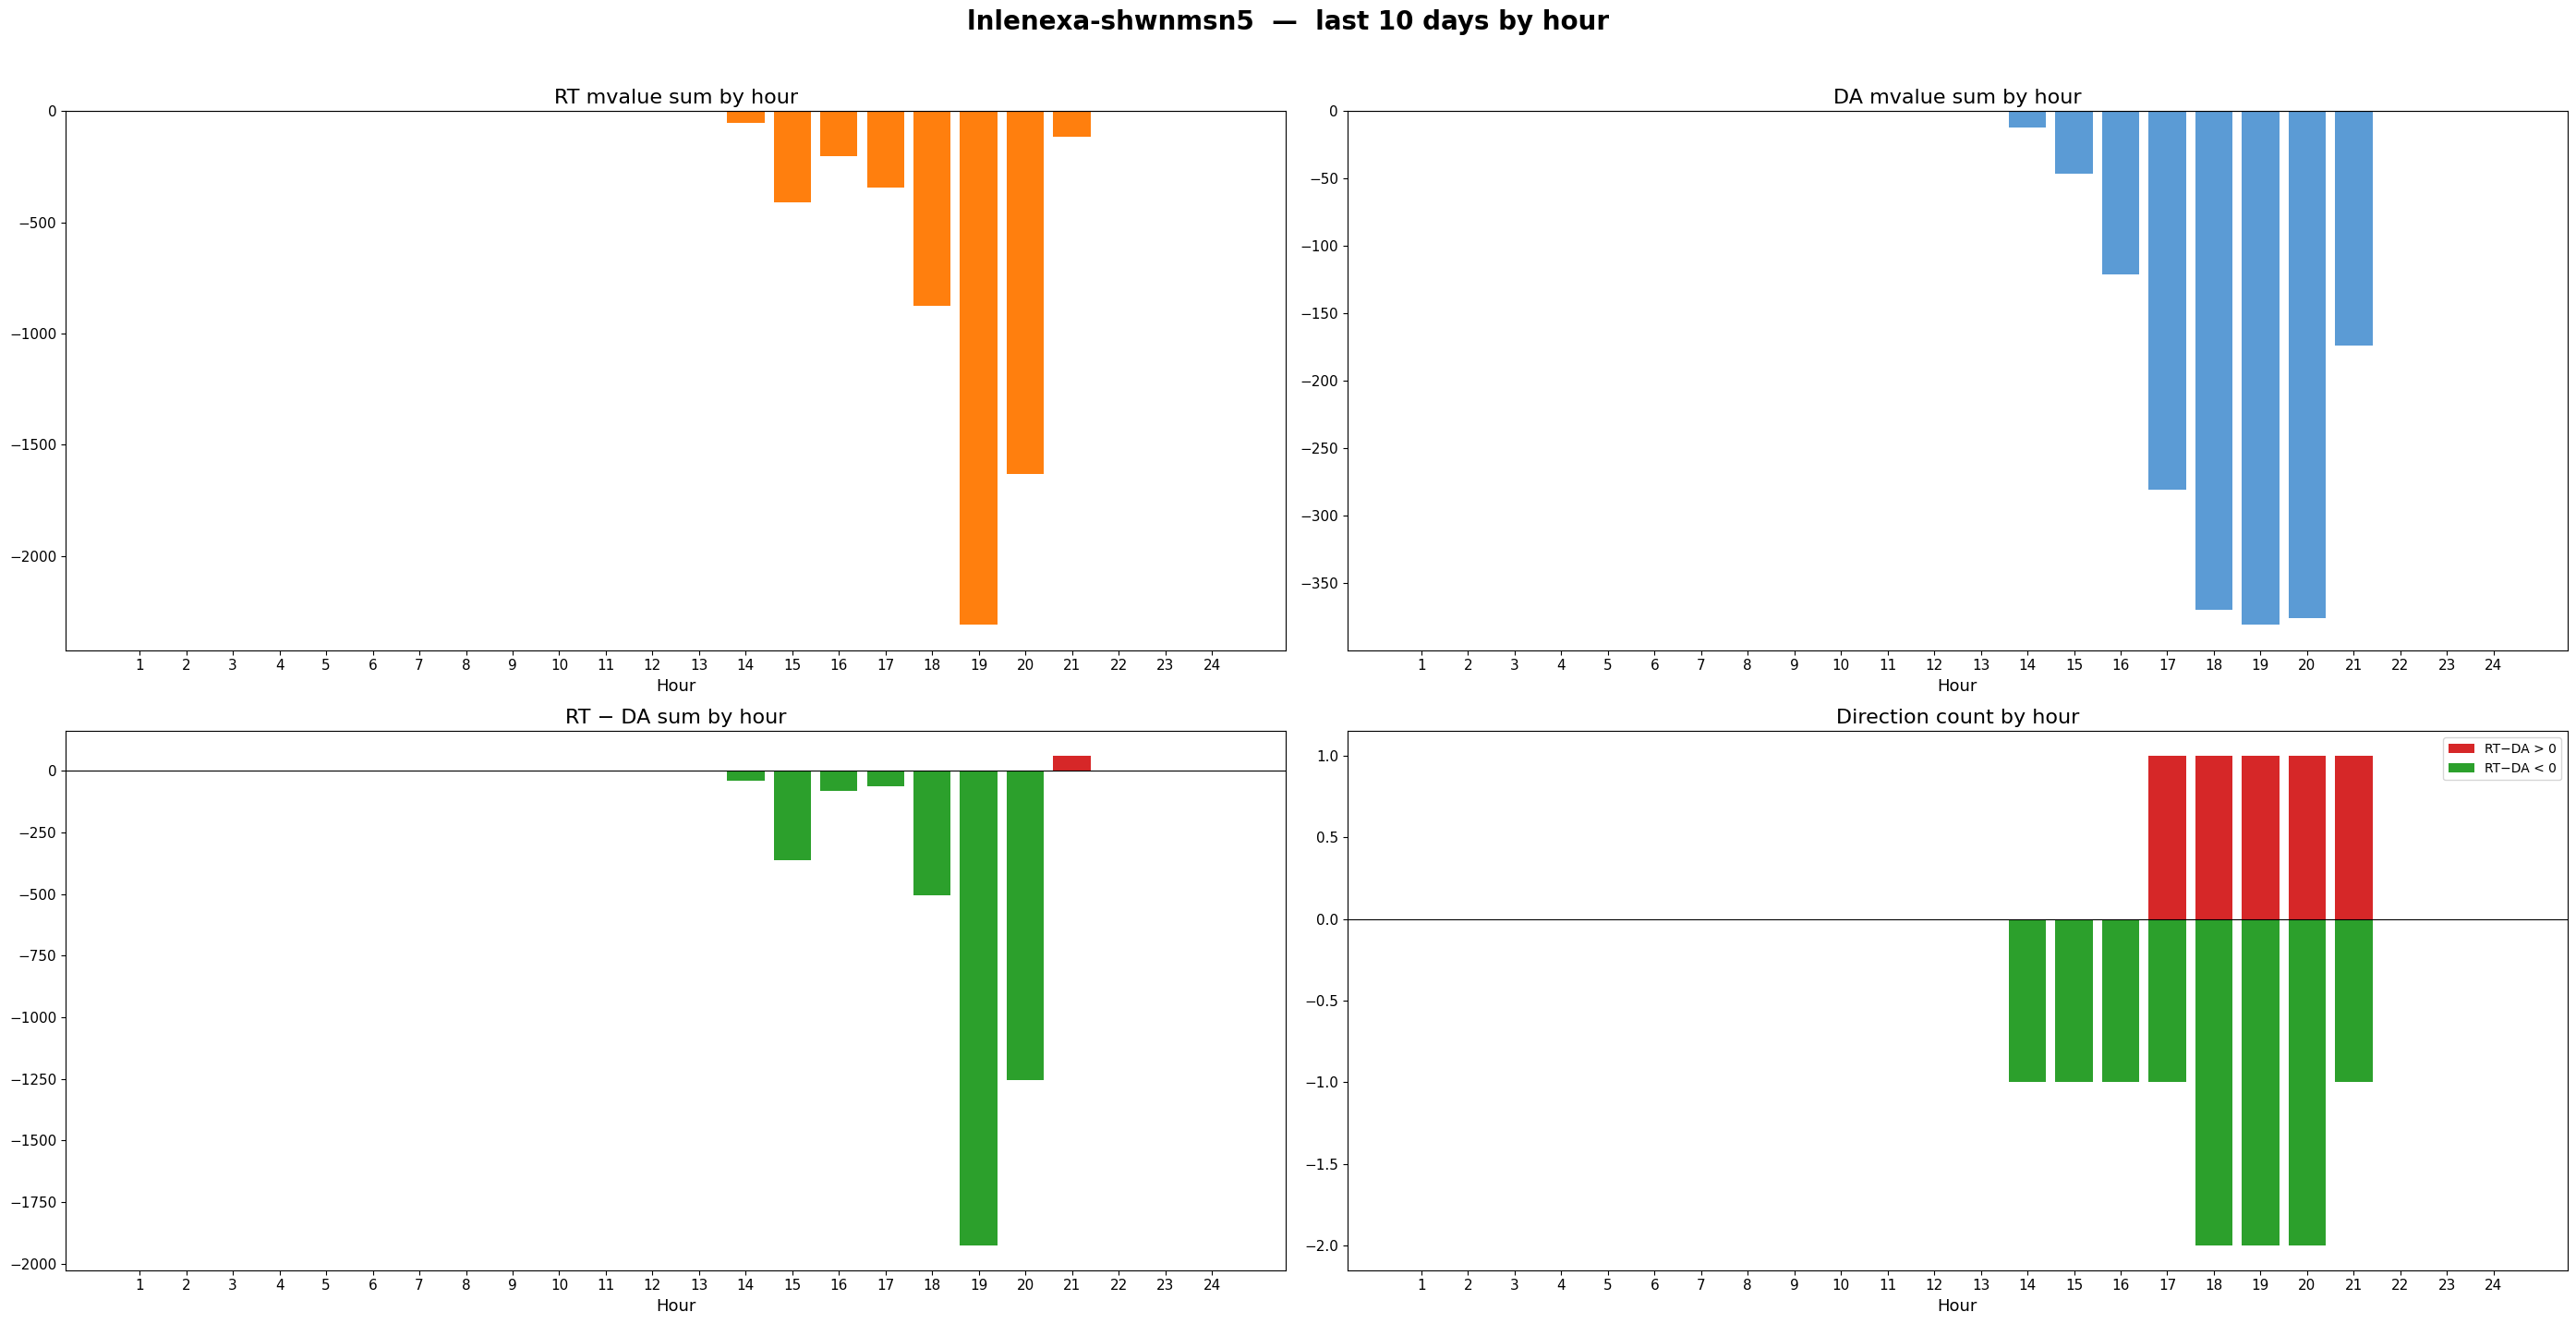


Total rows: 4738

  lnlenexa-shwnmsn5


,node_num,dfax,corr,sign_acc,mean_pred,mean_actual,n
0,228,0.2977,0.351837,0.693069,-15.595532,-5.846725,101.0
1,230,0.2977,0.351824,0.693069,-15.595532,-5.846255,101.0
2,233,0.2970,0.350311,0.683168,-15.558861,-5.547532,101.0
3,237,0.2962,0.350037,0.683168,-15.516952,-5.378425,101.0
4,232,0.2969,0.348959,0.683168,-15.553623,-5.262532,101.0
5,262,0.1595,0.266080,0.574257,-8.355685,3.172869,101.0
6,263,0.1595,0.266076,0.574257,-8.355685,3.172982,101.0
7,264,0.1595,0.265635,0.574257,-8.355685,3.188101,101.0
8,265,0.1595,0.265635,0.574257,-8.355685,3.188101,101.0
9,266,0.1595,0.265623,0.574257,-8.355685,3.187202,101.0


Constraint  : 'lnrugby230-rugby'
Reserve zone: 4  |  Columns: ['rz4_spp_res_zonal_wind_forecast_f', 'rz4_spp_res_zonal_load_forecast_f']
Baseline binding rate: 0.0083  |  Total hours: 17496


,monitored,reserve_zone,fundamental,baseline_prob,cond_prob_top95pct,lift_pct
0,lnrugby230-rugby,4,rz4_spp_res_zonal_wind_forecast_f,0.0083,0.0171,1.05
1,lnrugby230-rugby,4,rz4_spp_res_zonal_load_forecast_f,0.0083,0.0114,0.37


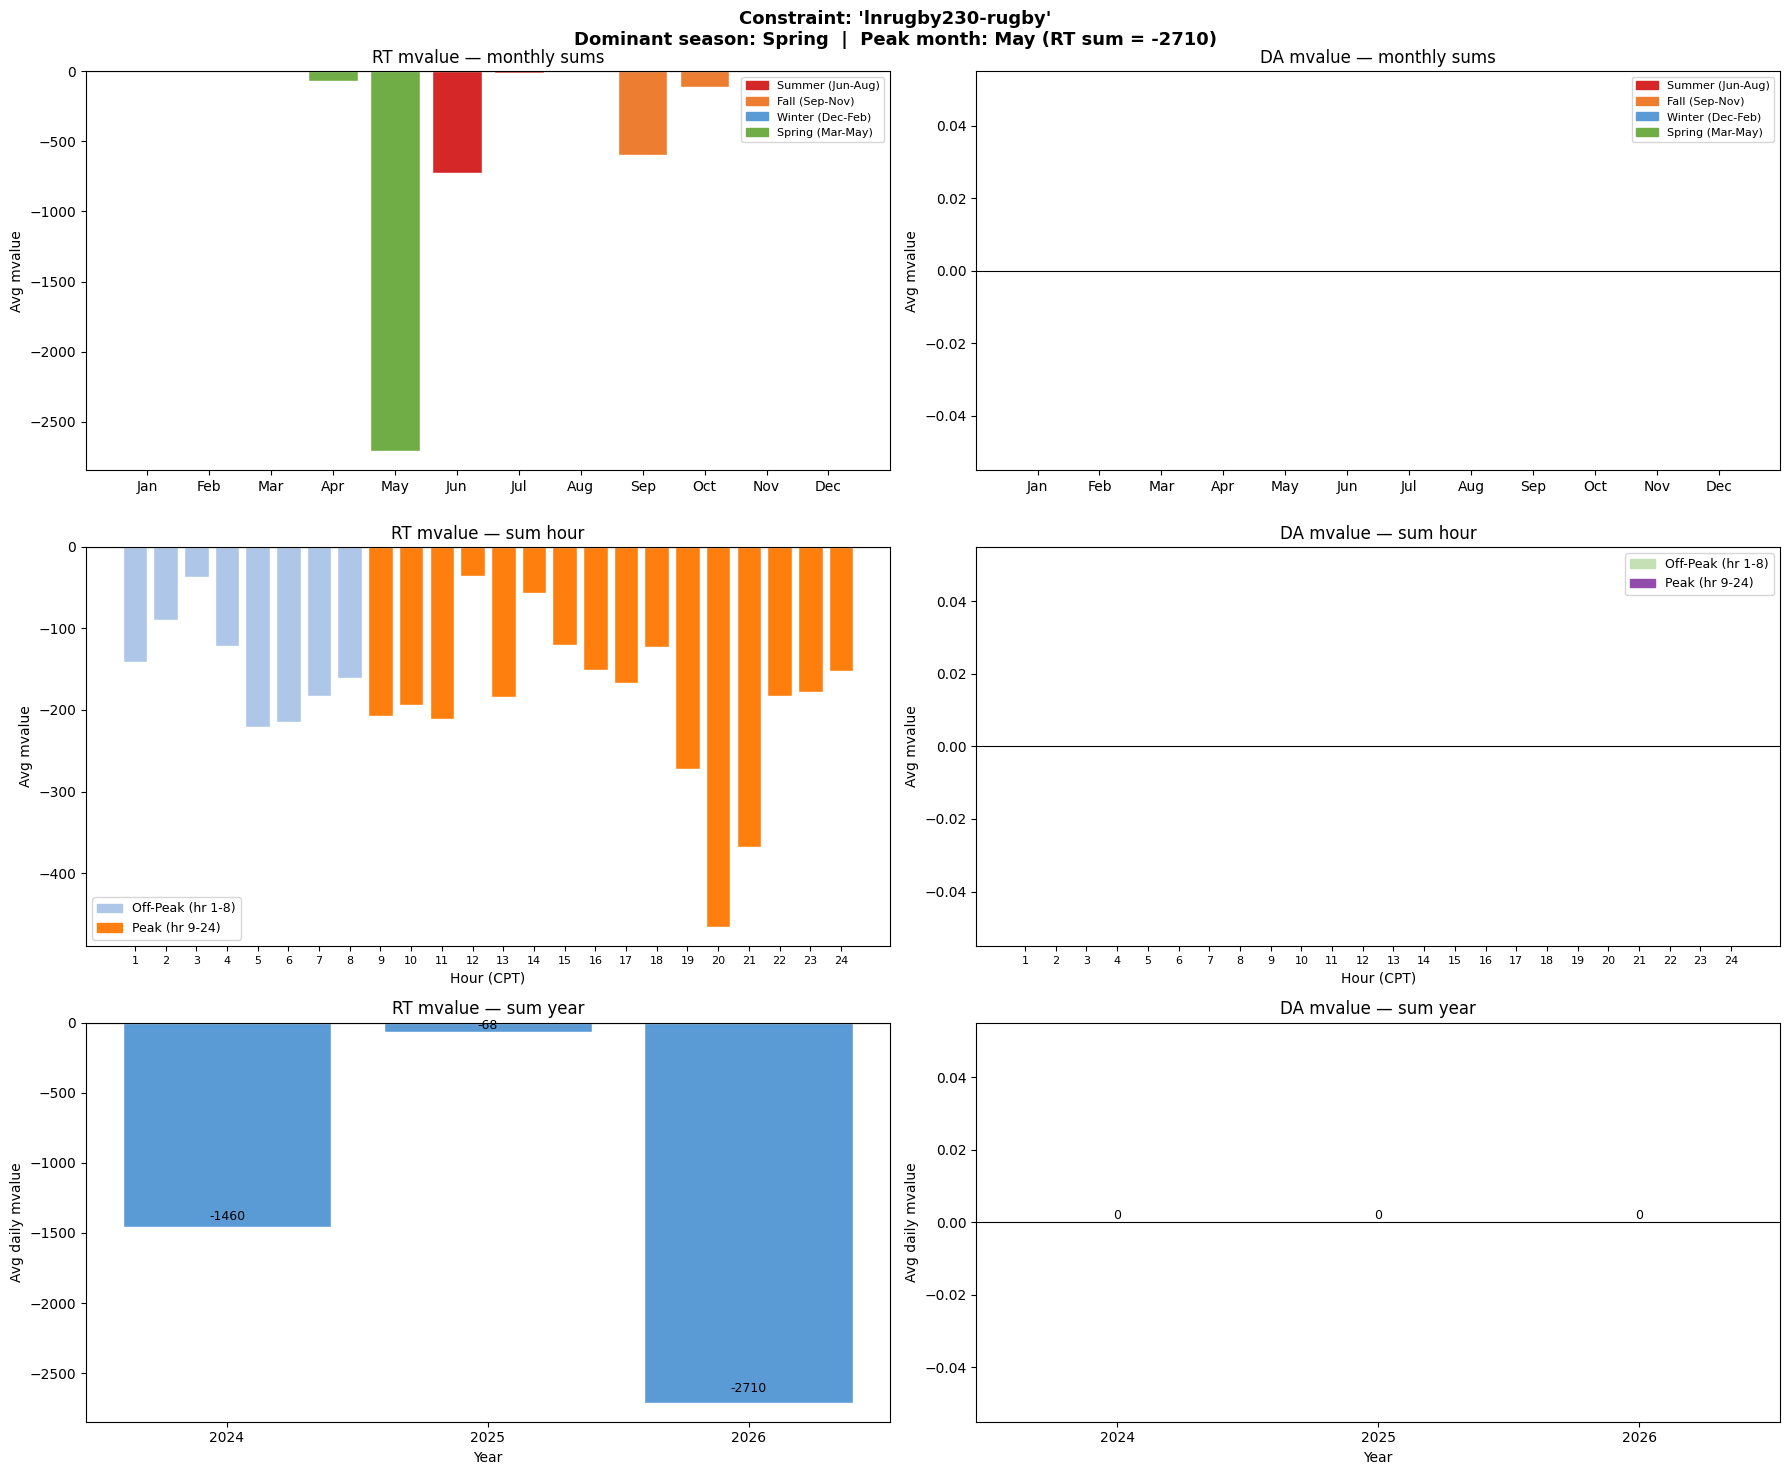

Dominant season : Spring

RT  peak sum   (hr  9-24):   -3068.65  |  off-peak (hr 1-8):   -1169.44
DA  peak sum   (hr  9-24):       0.00  |  off-peak (hr 1-8):       0.00
'lnrugby230-rugby'  |  2026-05-18 → 2026-05-28  |  5 days


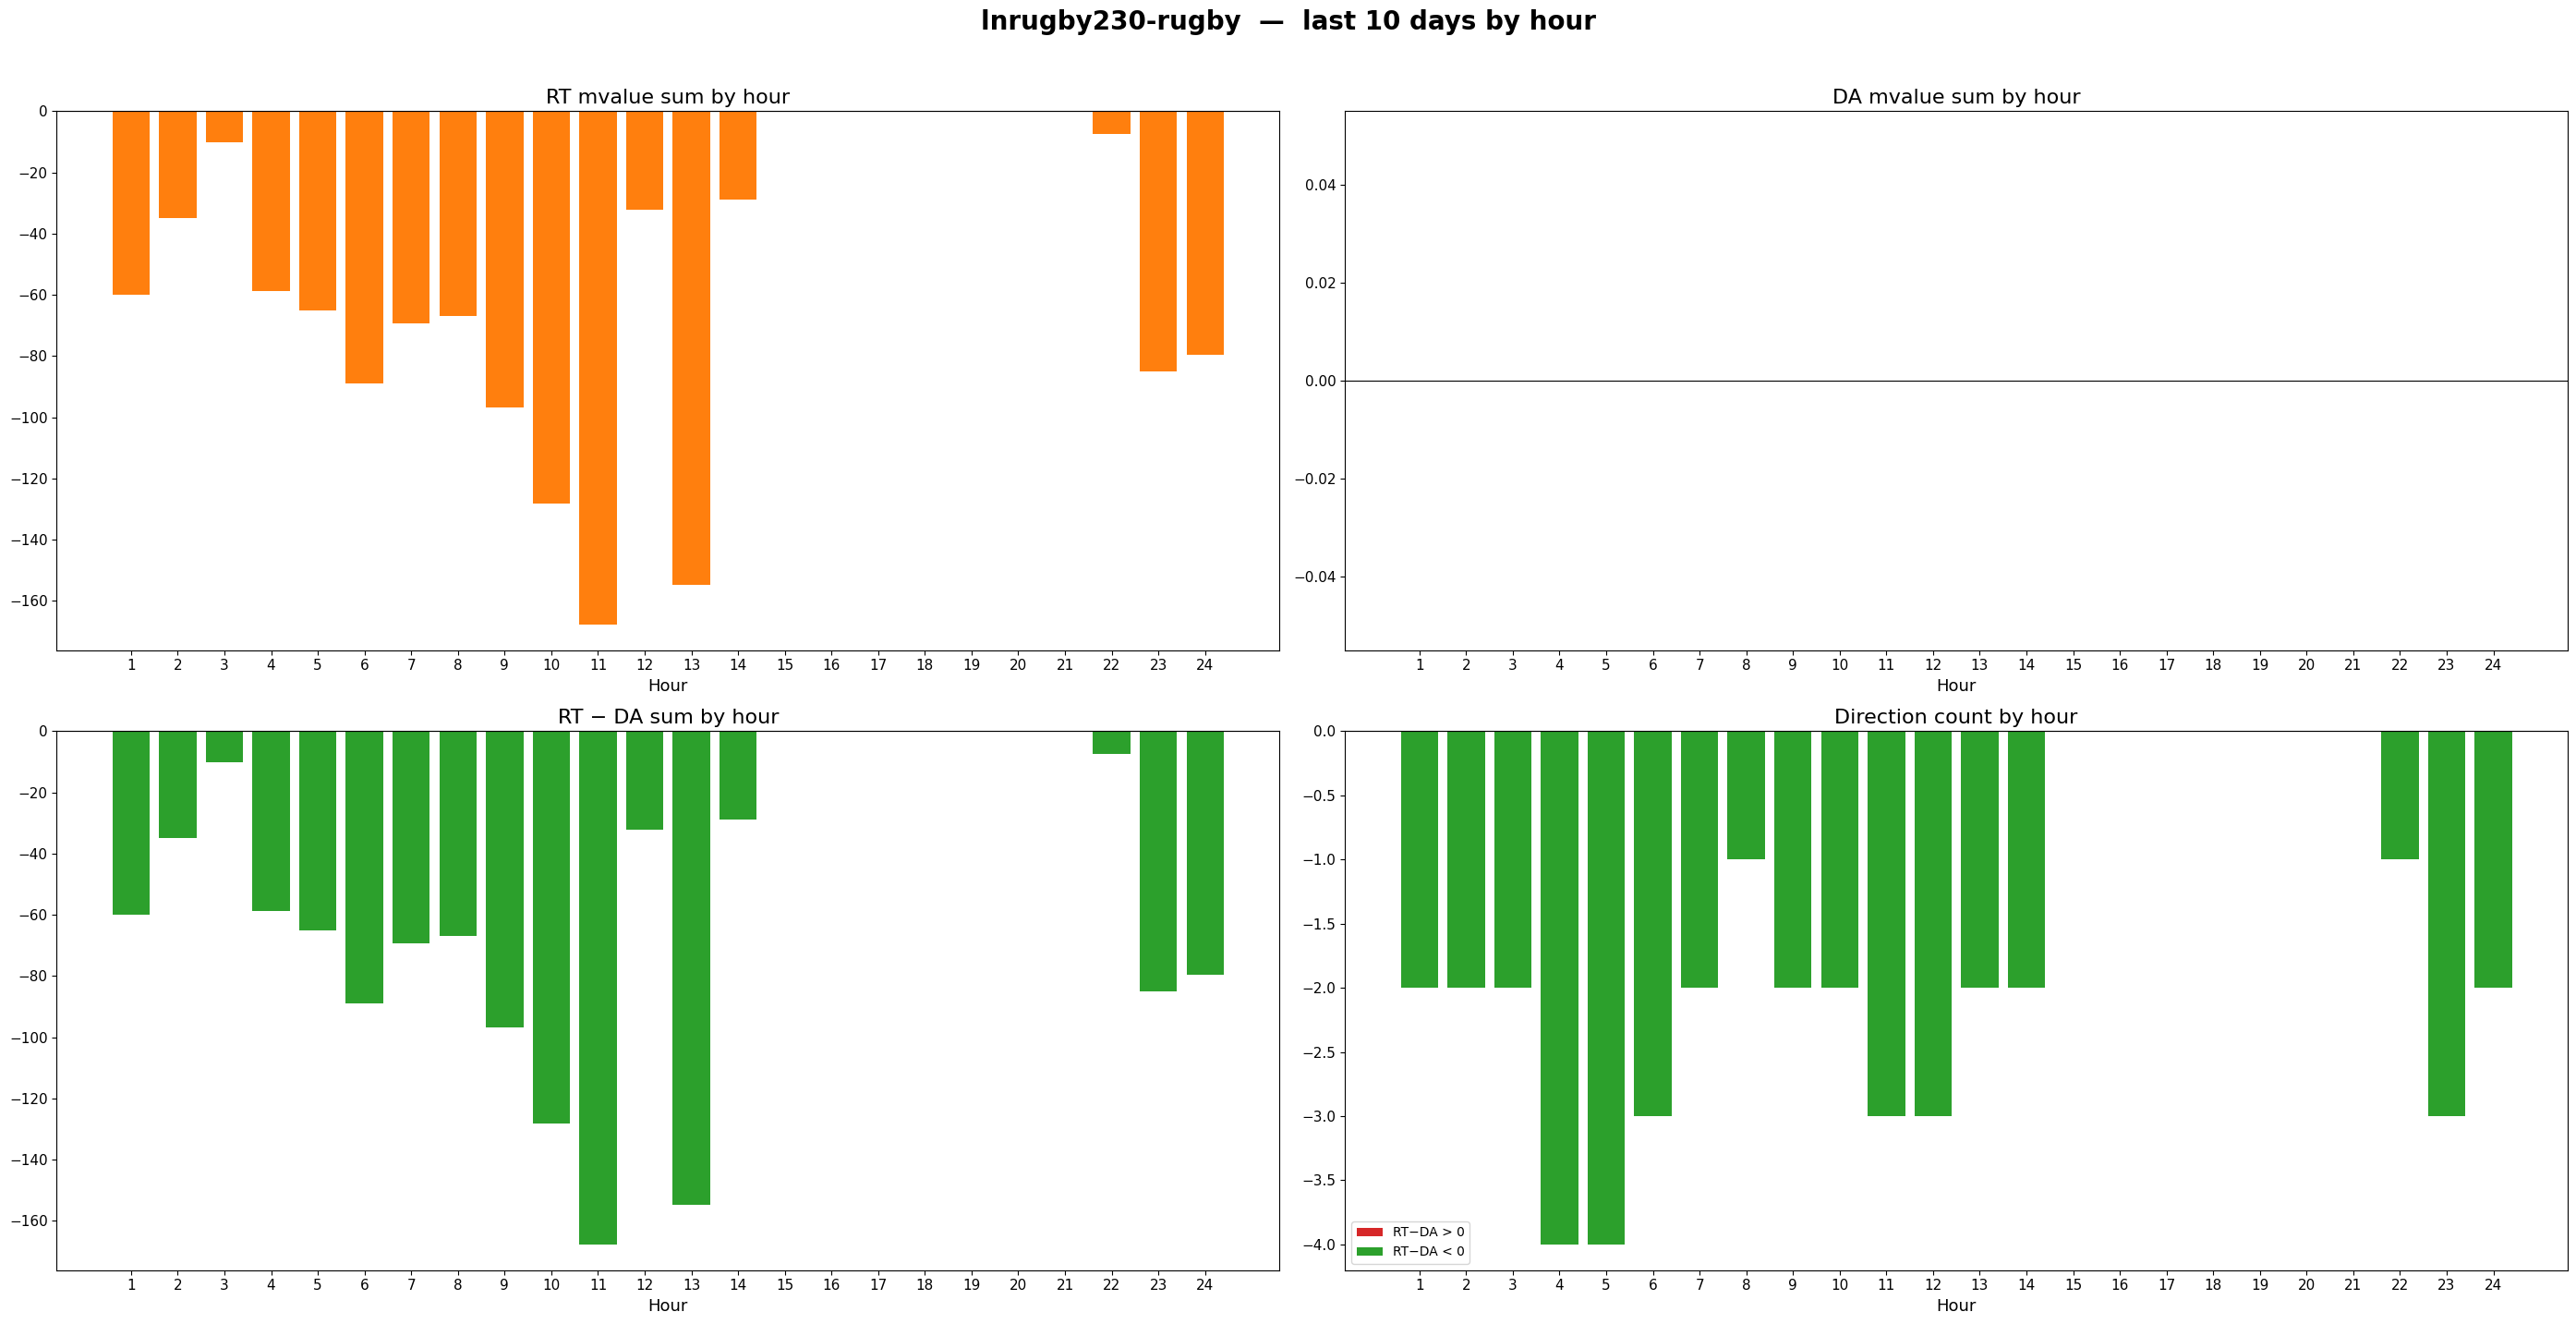


Total rows: 1314

  lnrugby230-rugby


,node_num,dfax,corr,sign_acc,mean_pred,mean_actual,n
0,979,0.2254,0.243300,0.561644,6.542916,10.266437,146.0
1,967,0.2254,0.237933,0.568493,6.542916,9.598641,146.0
2,1006,0.1288,0.161083,0.465753,3.738809,6.544486,146.0
3,896,0.1221,0.131712,0.438356,3.544321,6.982572,146.0
4,354,-0.1005,0.096678,0.719178,-2.917316,-0.266154,146.0
5,916,0.0564,0.092750,0.465753,1.637180,5.935709,146.0
6,1550,0.0574,0.077731,0.424658,1.666208,6.422135,146.0
7,964,0.0793,0.071841,0.410959,2.301922,7.452706,146.0
8,1444,0.0530,0.050461,0.383562,1.538485,7.170648,146.0


Constraint  : 'lnnebrcty-sub3456'
Reserve zone: 4  |  Columns: ['rz4_spp_res_zonal_wind_forecast_f', 'rz4_spp_res_zonal_load_forecast_f']
Baseline binding rate: 0.0097  |  Total hours: 17496


,monitored,reserve_zone,fundamental,baseline_prob,cond_prob_top95pct,lift_pct
1,lnnebrcty-sub3456,4,rz4_spp_res_zonal_load_forecast_f,0.0097,0.0046,-0.53
0,lnnebrcty-sub3456,4,rz4_spp_res_zonal_wind_forecast_f,0.0097,0.0034,-0.65


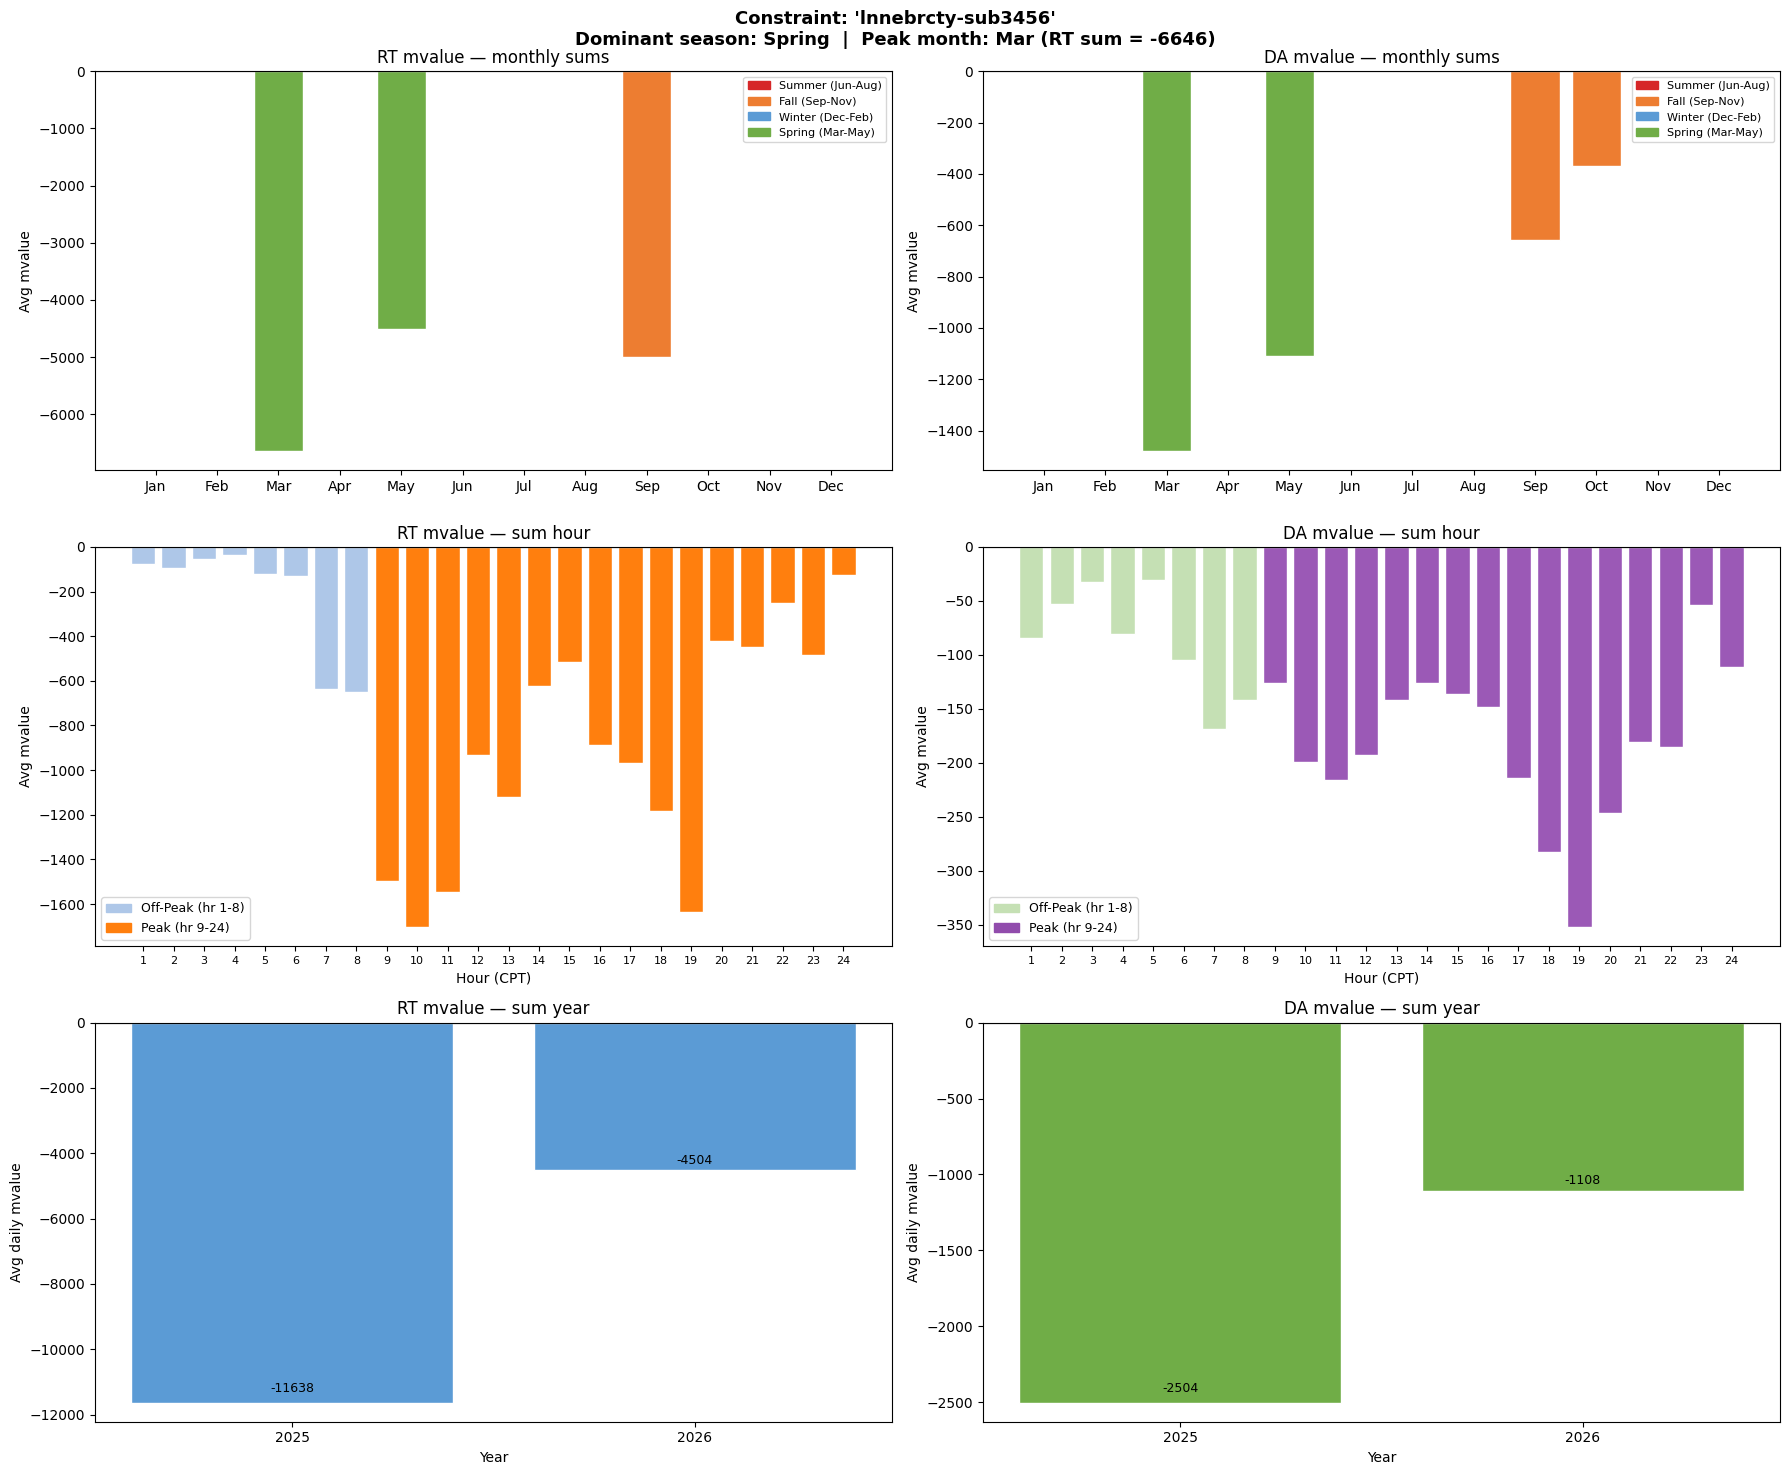

Dominant season : Spring

RT  peak sum   (hr  9-24):  -14345.97  |  off-peak (hr 1-8):   -1795.74
DA  peak sum   (hr  9-24):   -2913.74  |  off-peak (hr 1-8):    -698.35
'lnnebrcty-sub3456'  |  2026-05-18 → 2026-05-28  |  2 days


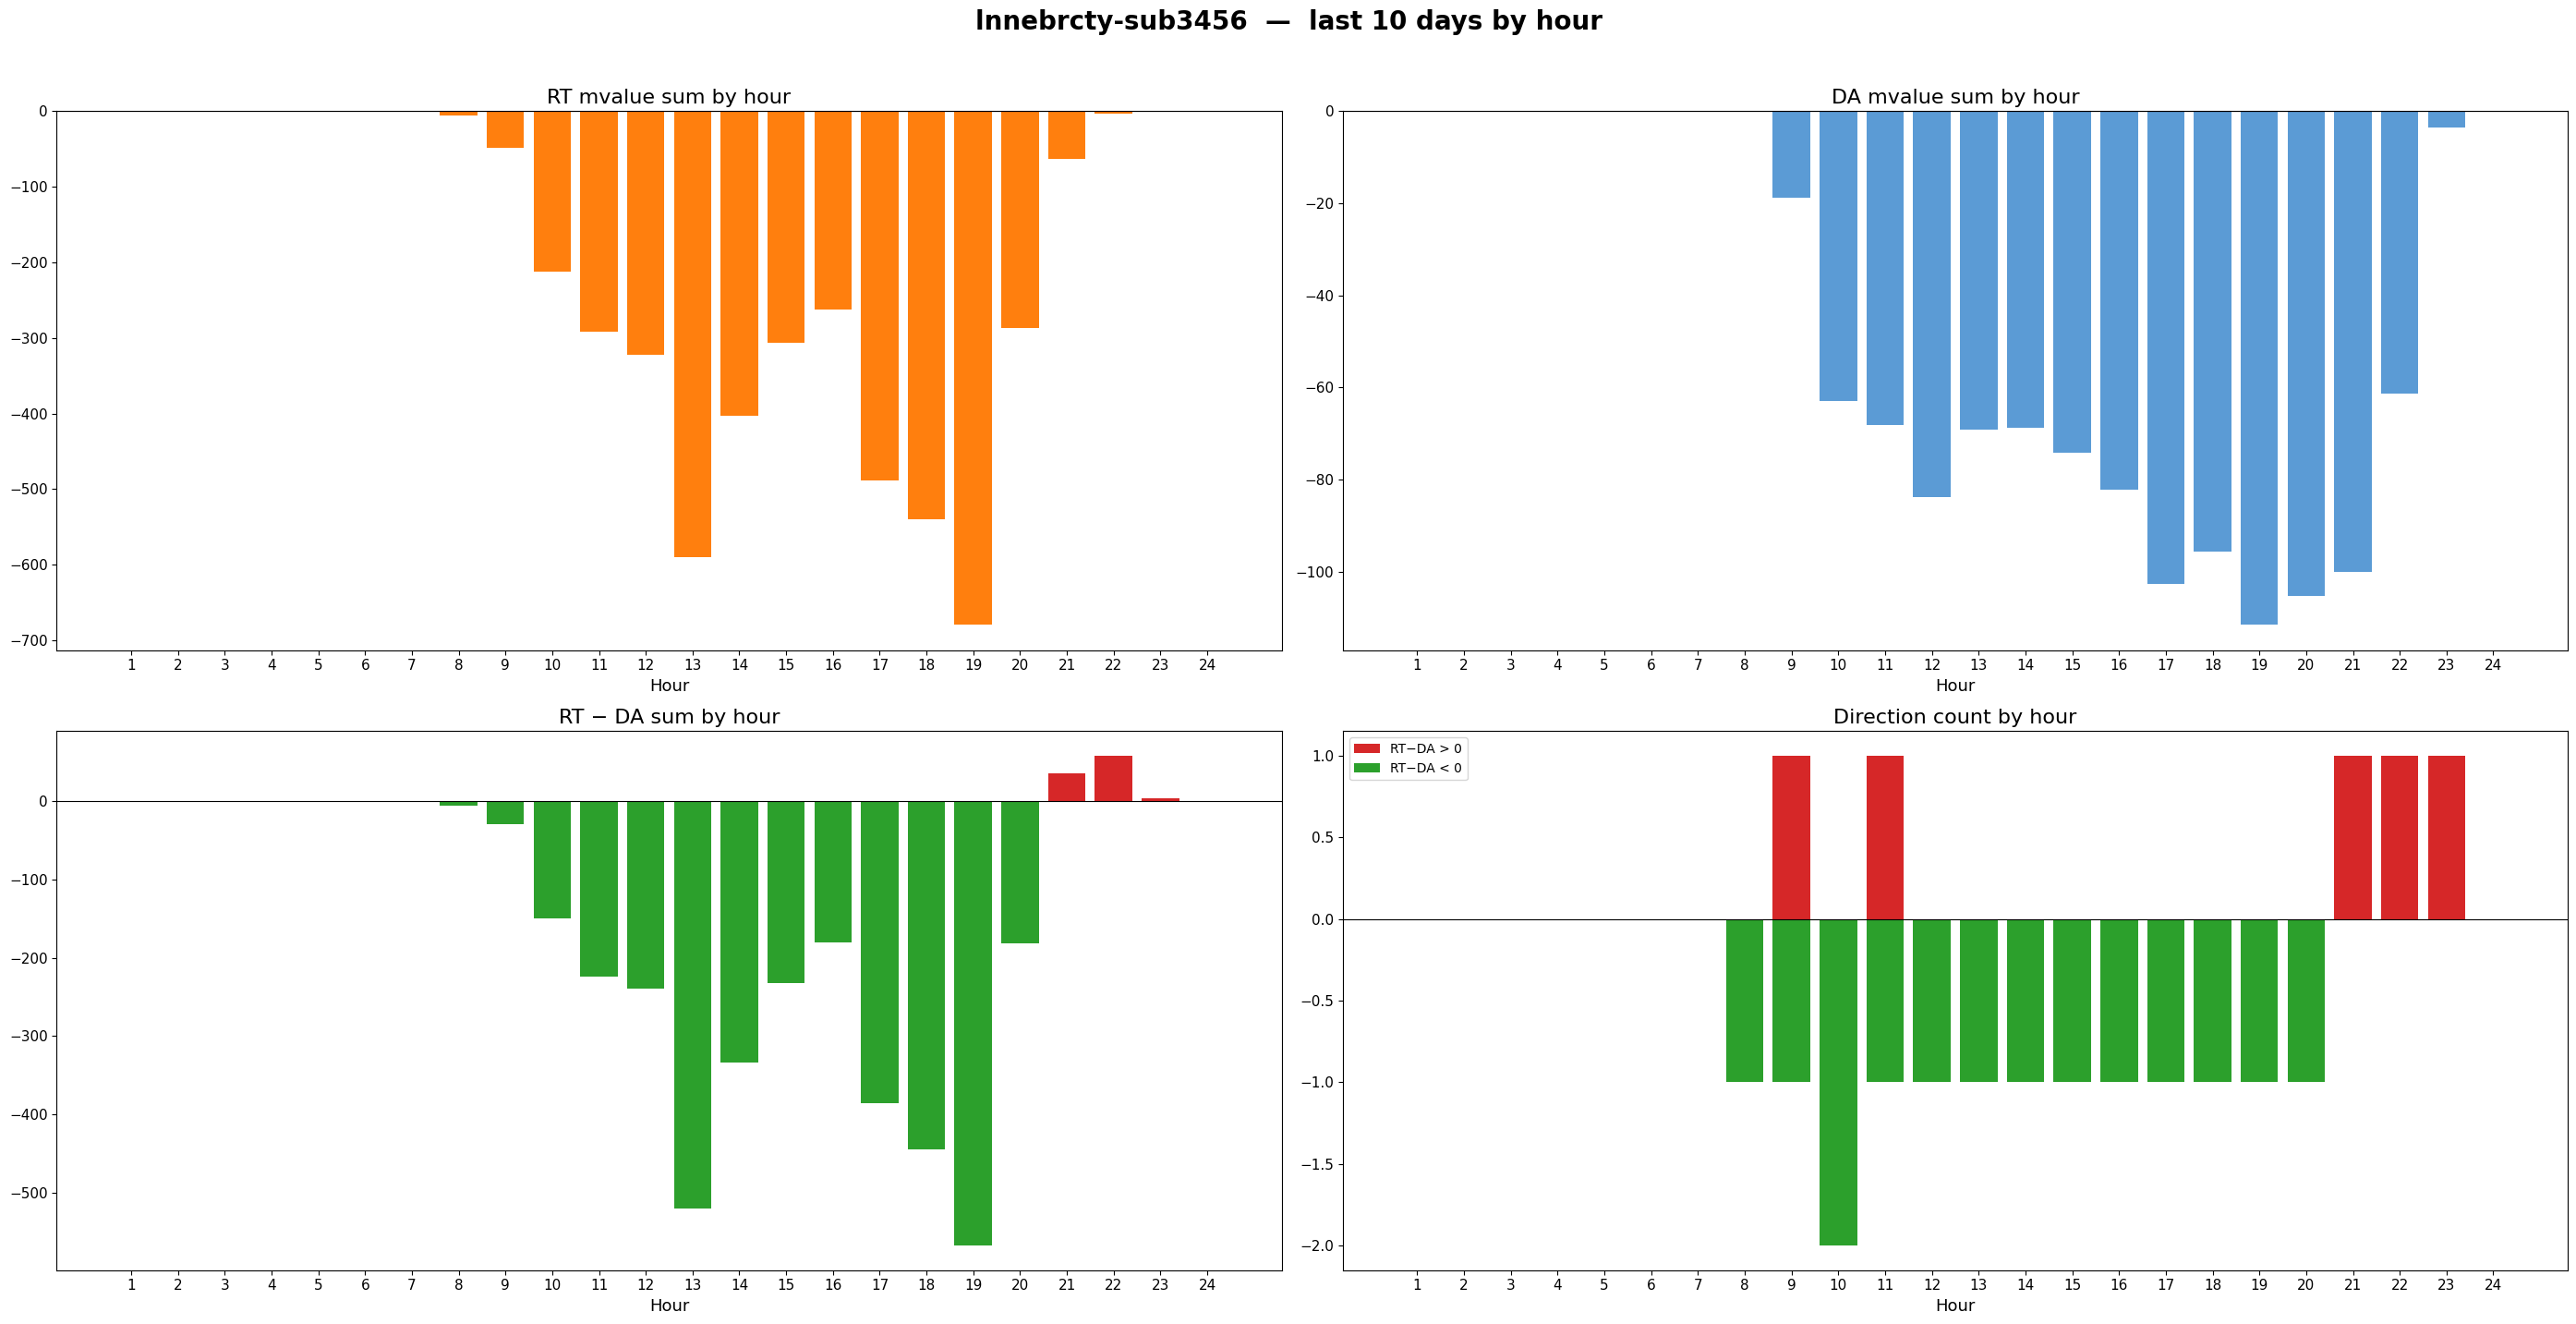


Total rows: 103104

  lnnebrcty-sub3456


,node_num,dfax,corr,sign_acc,mean_pred,mean_actual,n
0,343,0.2542,0.836784,0.639053,19.494139,21.556797,169.0
1,942,0.2542,0.836784,0.639053,19.494139,21.556797,169.0
2,342,0.2542,0.836778,0.639053,19.494139,21.557846,169.0
3,1466,0.2716,0.836735,0.627219,20.581922,21.846521,169.0
4,181,0.2350,0.835363,0.627219,18.415110,20.572384,169.0
...,...,...,...,...,...,...,...
552,1372,-0.0634,NaN,NaN,NaN,NaN,0.0
553,1380,-0.0752,NaN,NaN,NaN,NaN,0.0
554,1390,-0.0772,NaN,NaN,NaN,NaN,0.0
555,1393,-0.0543,NaN,NaN,NaN,NaN,0.0


Constraint  : 'lnmanfl7-clec_pel'
Reserve zone: 4  |  Columns: ['rz4_spp_res_zonal_wind_forecast_f', 'rz4_spp_res_zonal_load_forecast_f']
Baseline binding rate: 0.0142  |  Total hours: 17496


,monitored,reserve_zone,fundamental,baseline_prob,cond_prob_top95pct,lift_pct
0,lnmanfl7-clec_pel,4,rz4_spp_res_zonal_wind_forecast_f,0.0142,0.04,1.82
1,lnmanfl7-clec_pel,4,rz4_spp_res_zonal_load_forecast_f,0.0142,0.00,-1.00


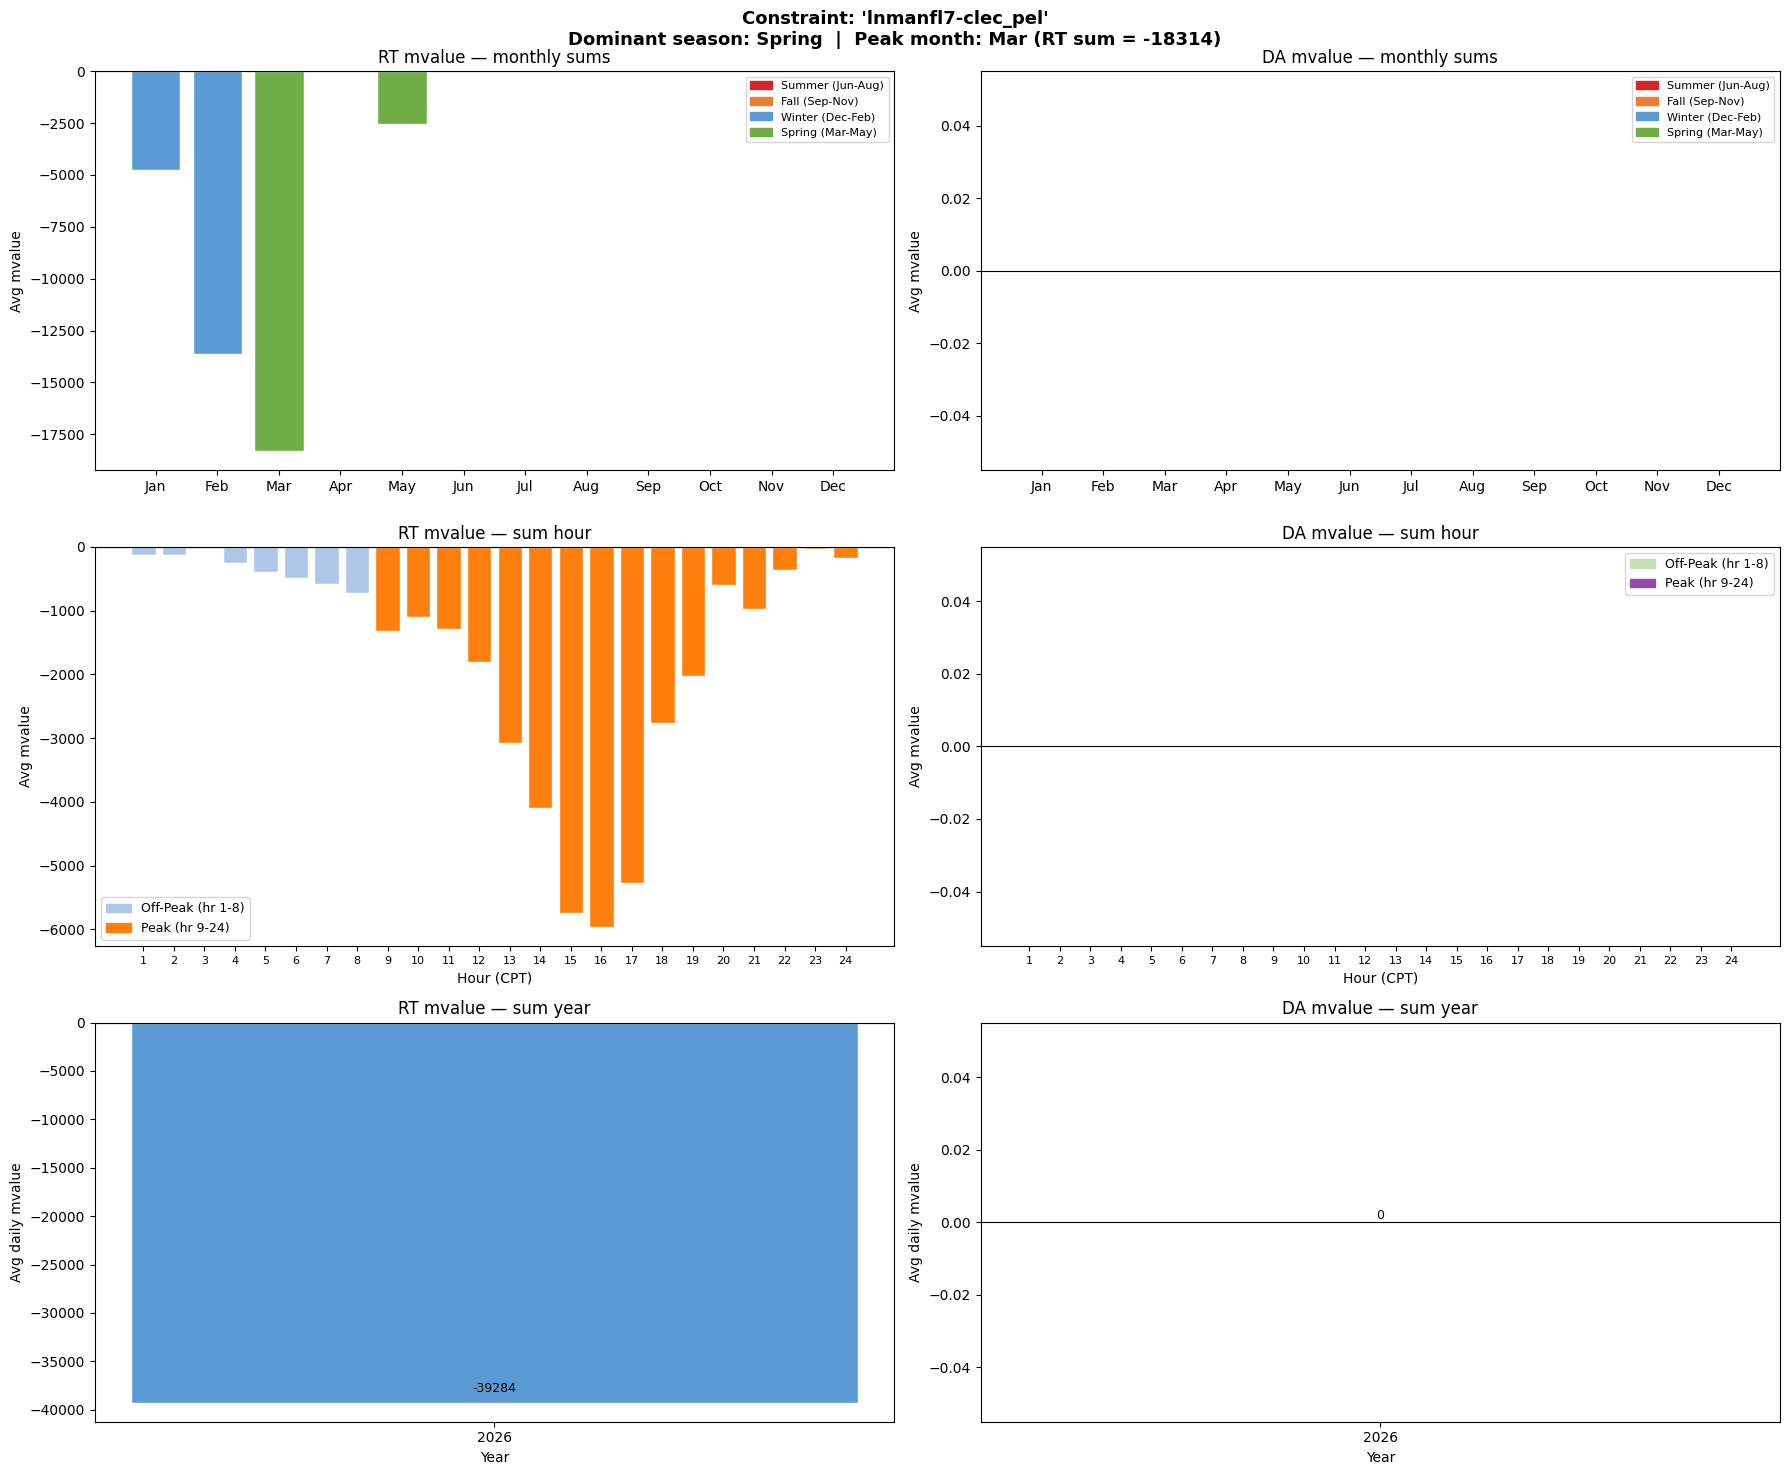

Dominant season : Spring

RT  peak sum   (hr  9-24):  -36587.94  |  off-peak (hr 1-8):   -2695.57
DA  peak sum   (hr  9-24):       0.00  |  off-peak (hr 1-8):       0.00
'lnmanfl7-clec_pel'  |  2026-05-18 → 2026-05-28  |  3 days


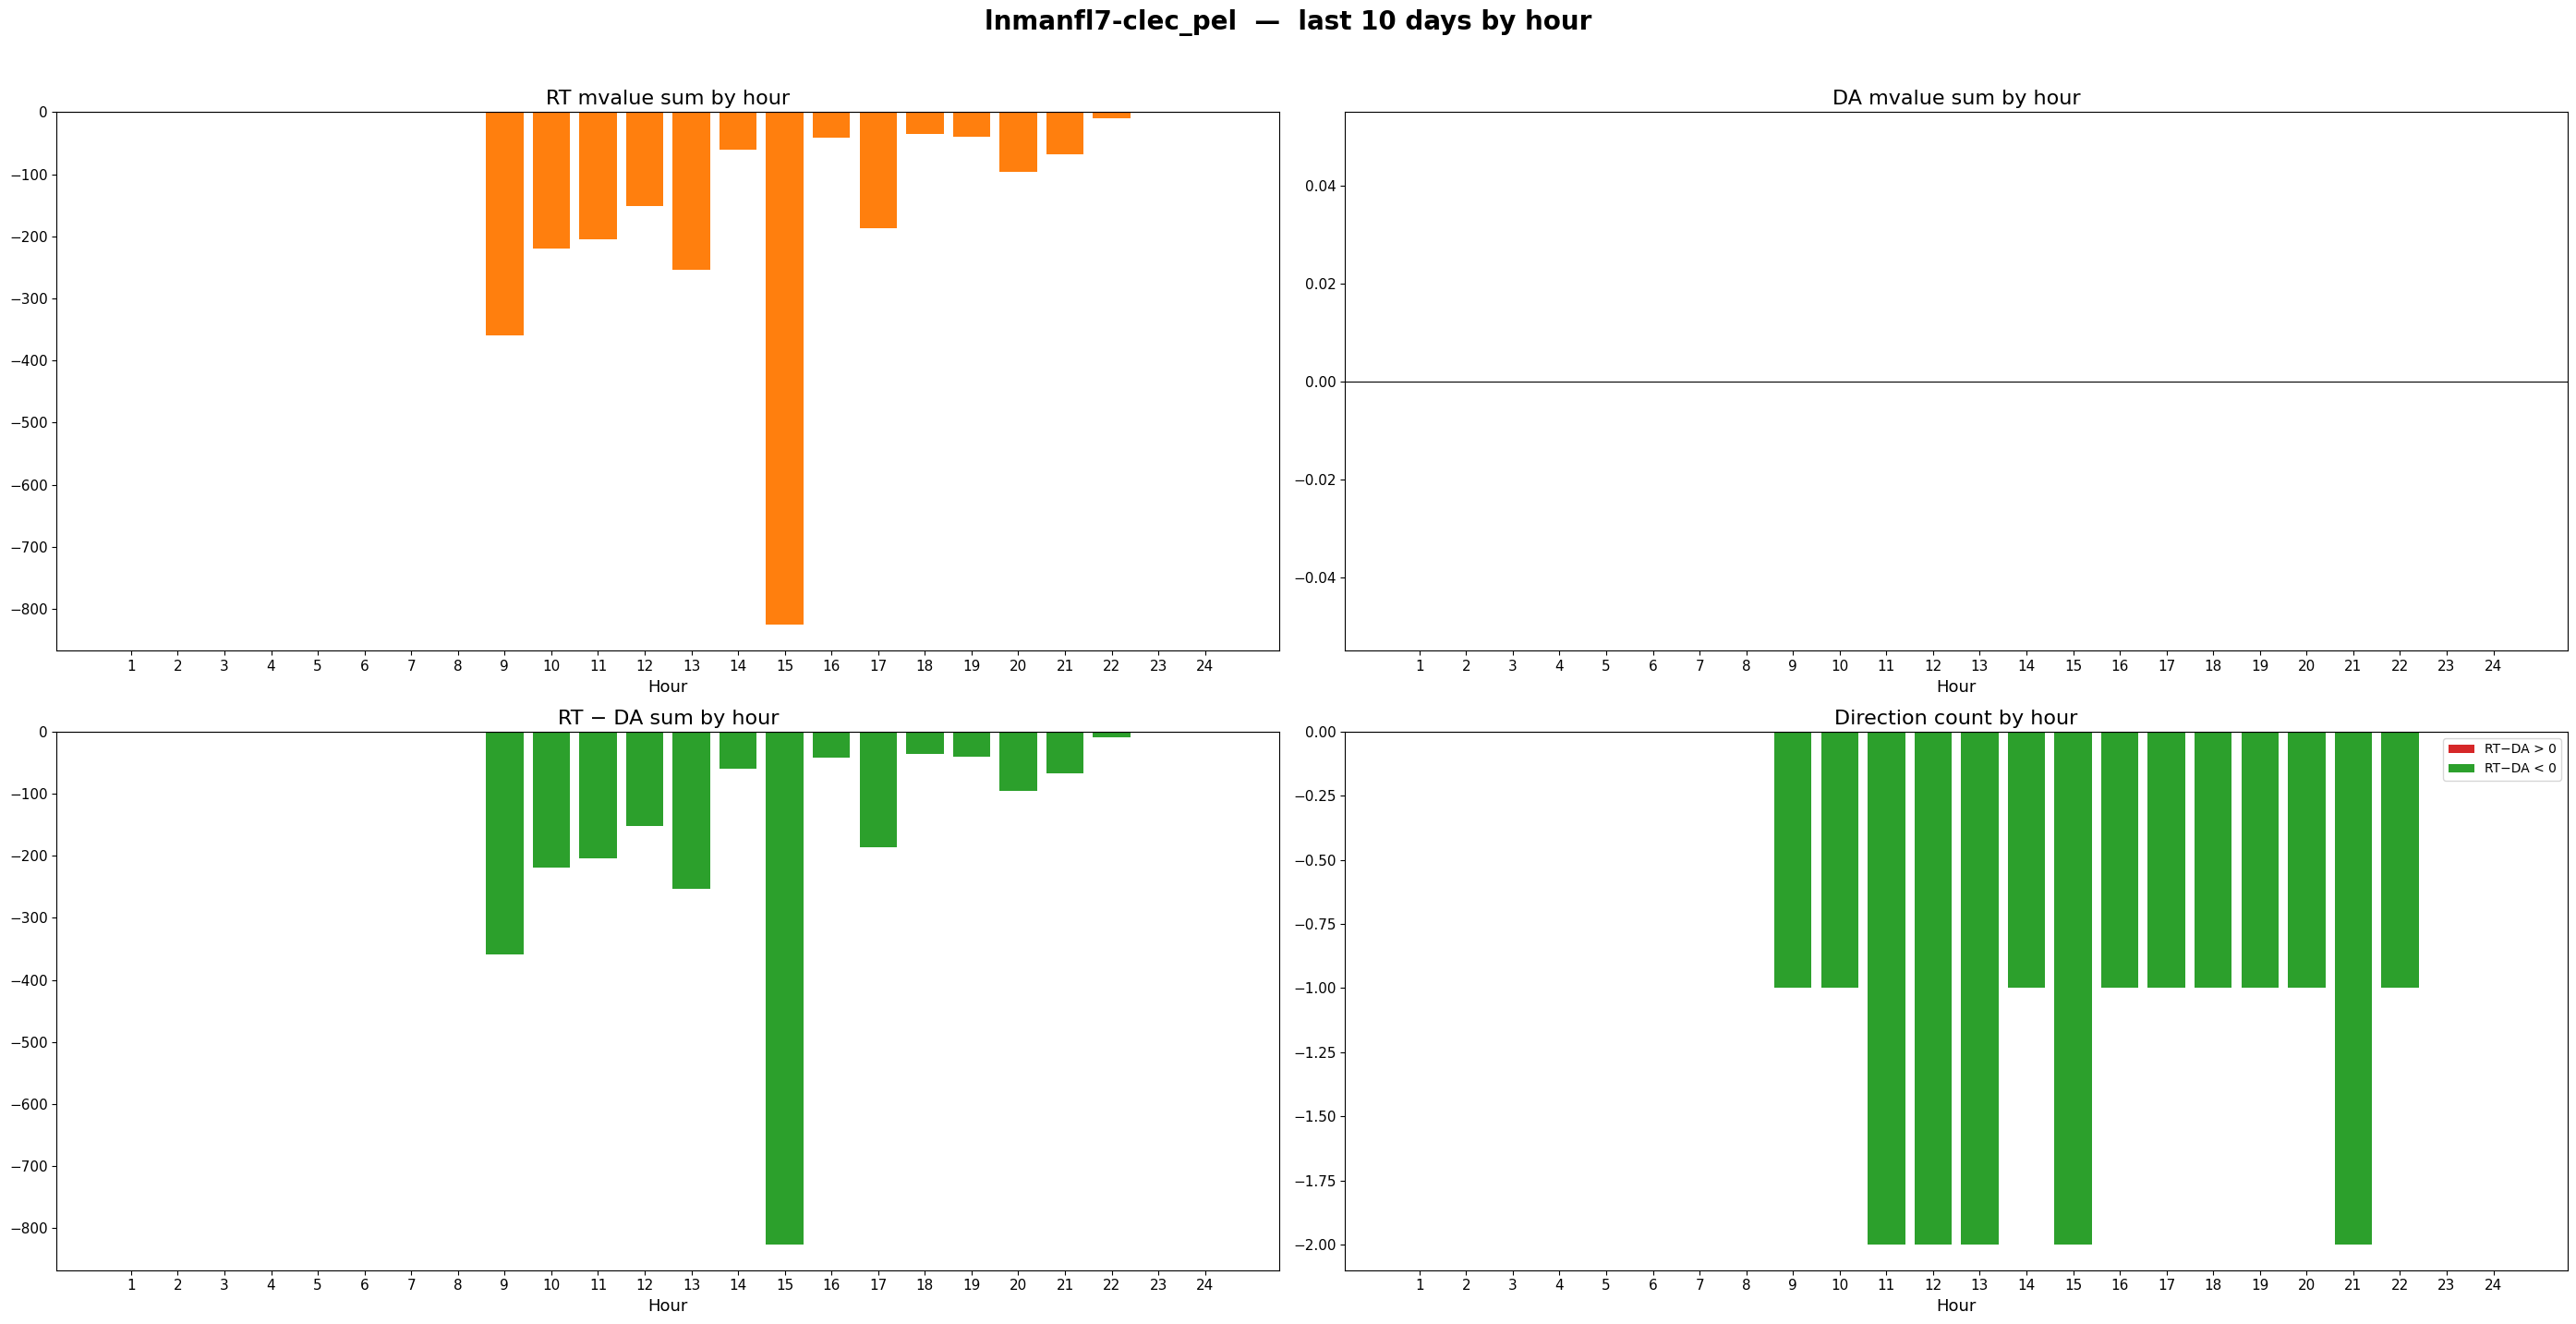


Total rows: 248

  lnmanfl7-clec_pel


,node_num,dfax,corr,sign_acc,mean_pred,mean_actual,n
0,1106,0.051,0.473454,0.487903,8.078463,5.072736,248.0


Constraint  : 'lnwemp-vaug'
Reserve zone: 4  |  Columns: ['rz4_spp_res_zonal_wind_forecast_f', 'rz4_spp_res_zonal_load_forecast_f']
Baseline binding rate: 0.0149  |  Total hours: 17496


,monitored,reserve_zone,fundamental,baseline_prob,cond_prob_top95pct,lift_pct
1,lnwemp-vaug,4,rz4_spp_res_zonal_load_forecast_f,0.0149,0.0331,1.22
0,lnwemp-vaug,4,rz4_spp_res_zonal_wind_forecast_f,0.0149,0.0000,-1.00


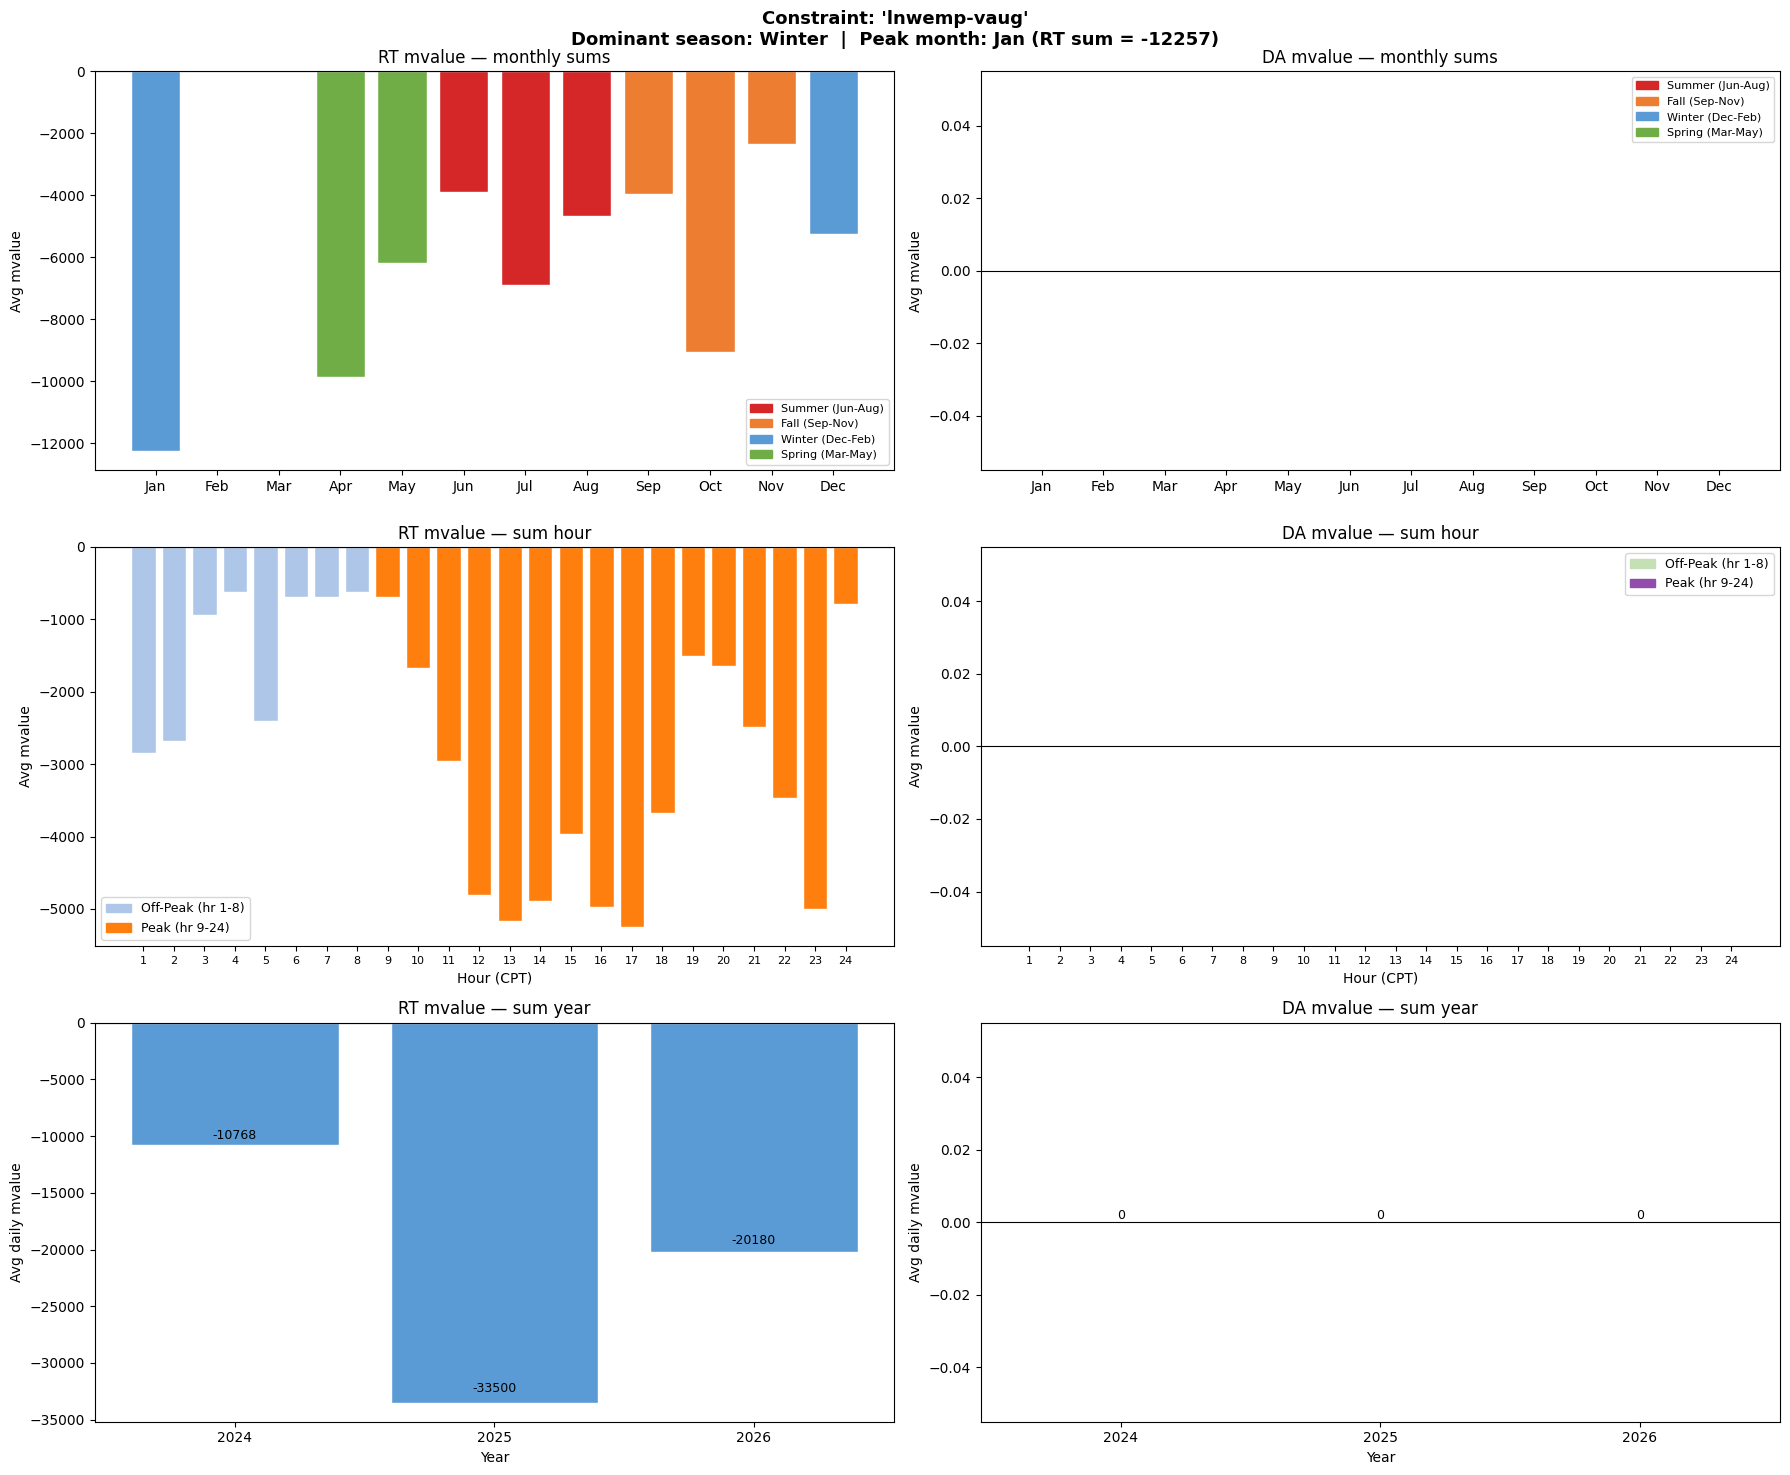

Dominant season : Winter

RT  peak sum   (hr  9-24):  -52939.61  |  off-peak (hr 1-8):  -11509.39
DA  peak sum   (hr  9-24):       0.00  |  off-peak (hr 1-8):       0.00
'lnwemp-vaug'  |  2026-05-18 → 2026-05-28  |  3 days


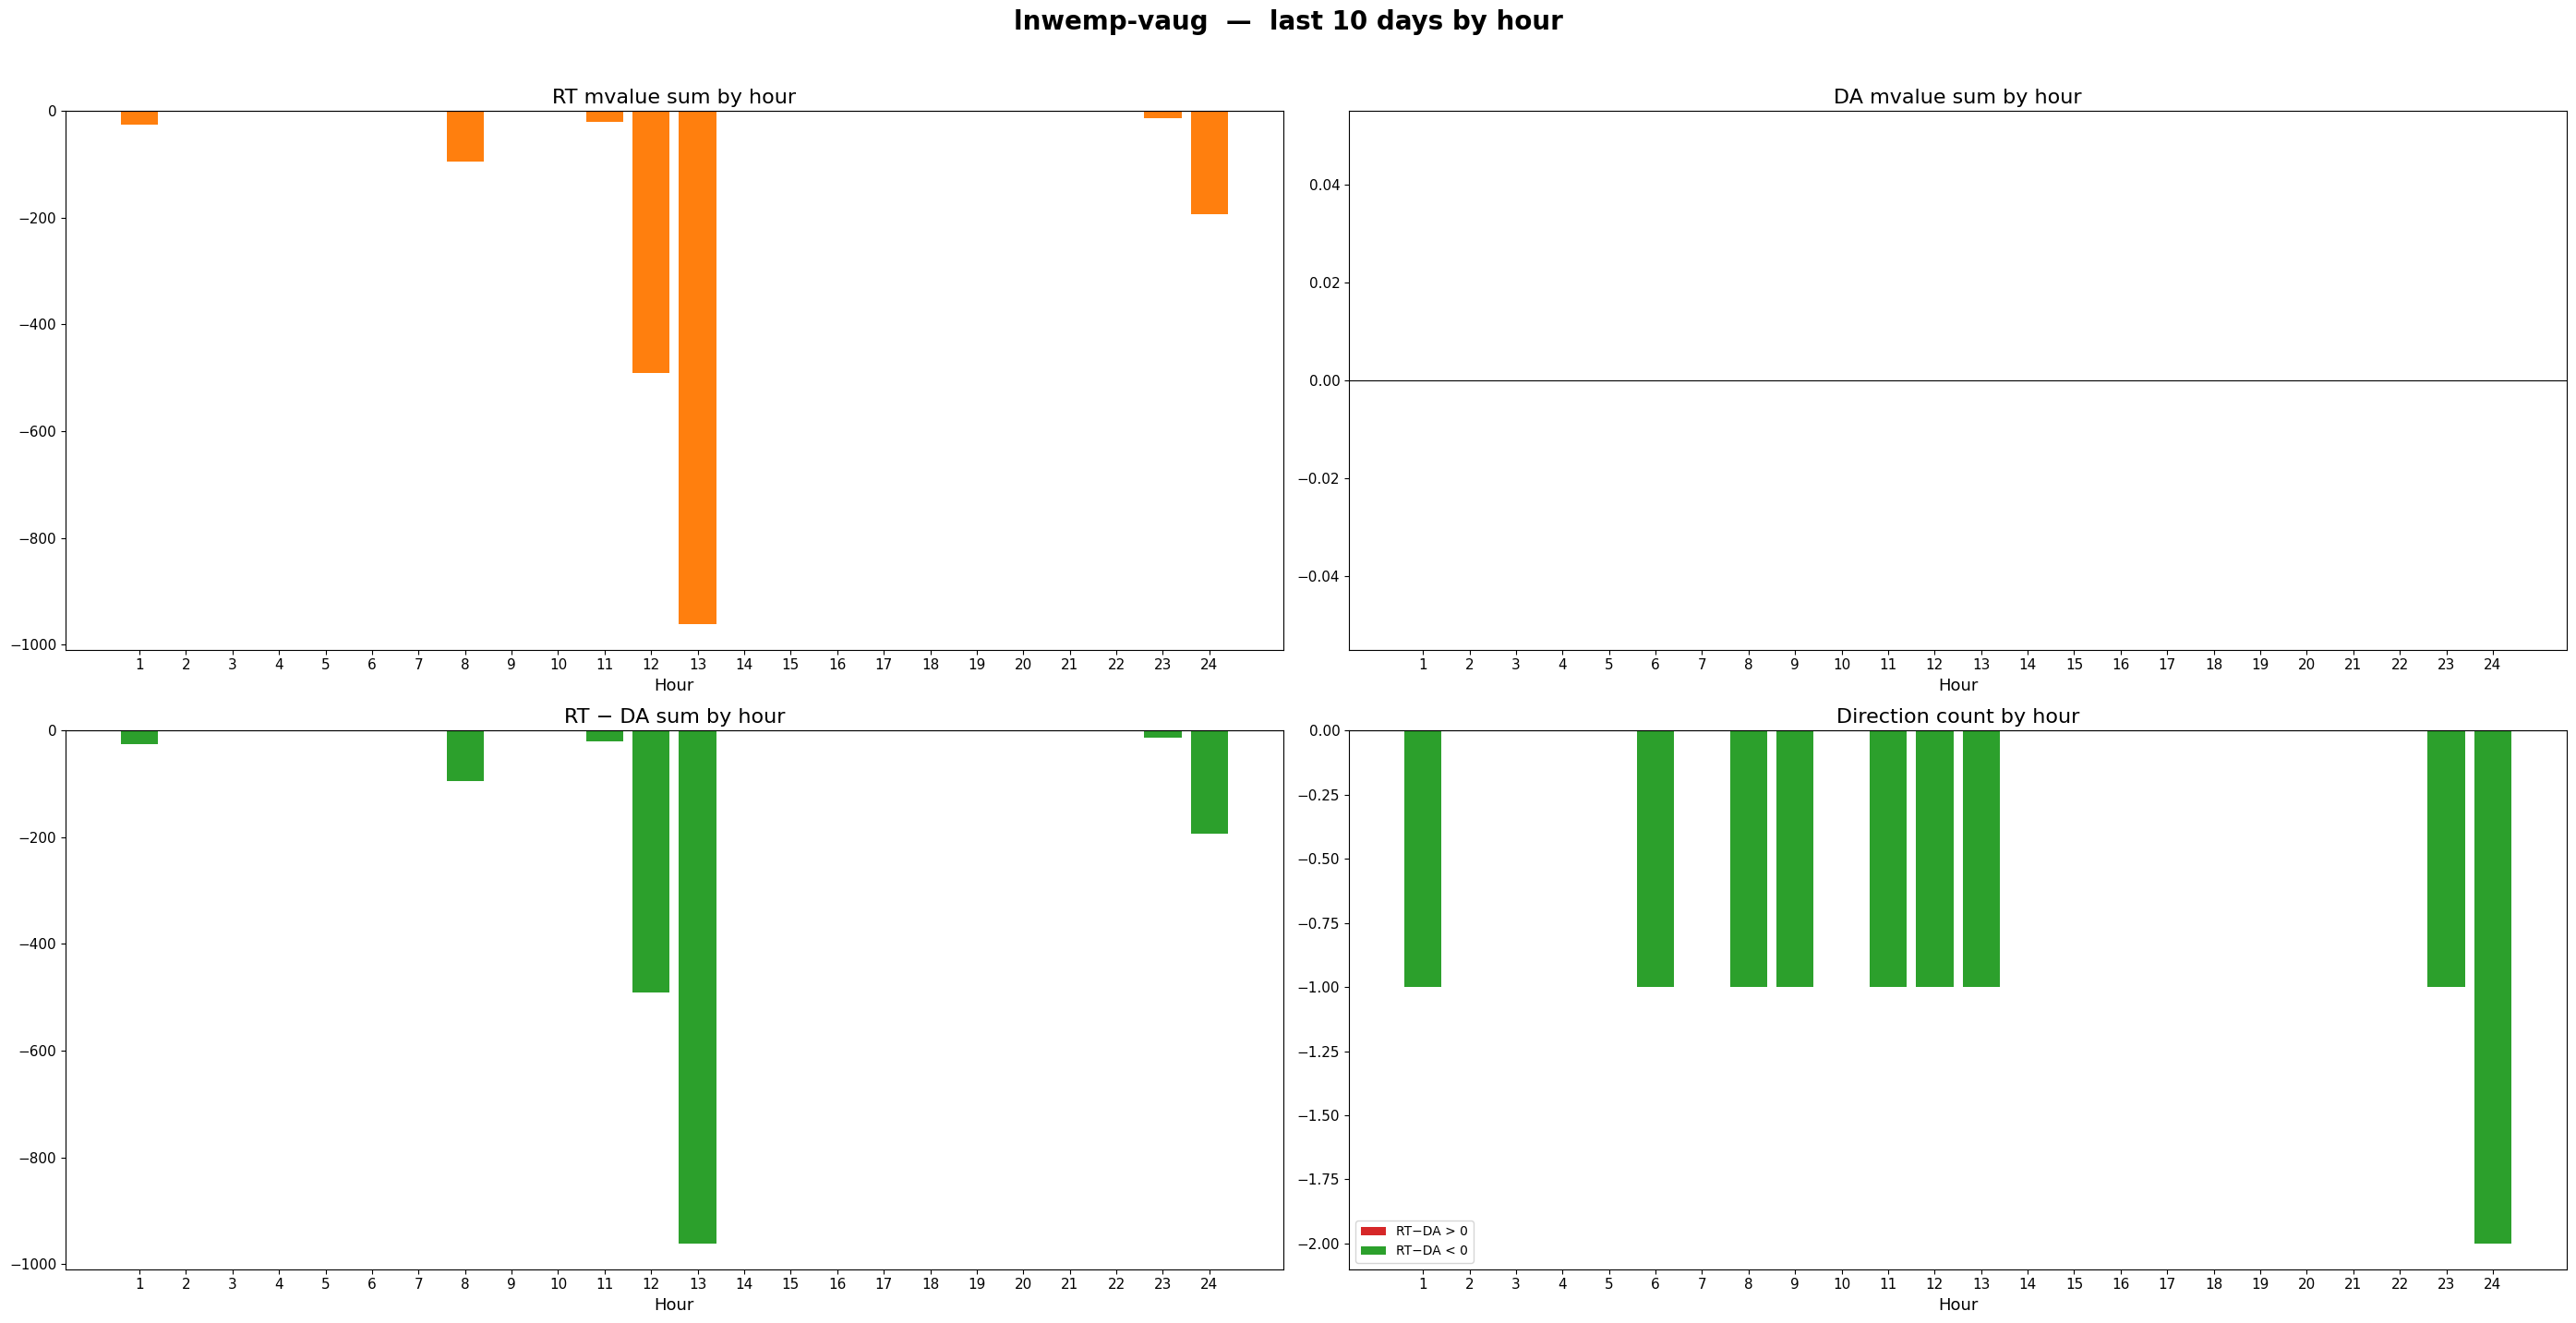


Total rows: 2221

  lnwemp-vaug


,node_num,dfax,corr,sign_acc,mean_pred,mean_actual,n
0,1464,0.0711,0.534316,0.347368,14.165398,4.725923,95.0
1,1506,-0.1434,0.418800,0.736842,-28.569875,-16.230675,95.0
2,1509,-0.1434,0.418800,0.736842,-28.569875,-16.230675,95.0
3,1507,-0.0847,0.214896,0.736842,-16.874954,-11.574233,95.0
4,1508,-0.0847,0.214896,0.736842,-16.874954,-11.574233,95.0
5,759,0.0770,0.017104,0.406130,19.667798,17.035208,261.0
6,810,0.0770,0.015553,0.421456,19.667798,17.003345,261.0
7,839,0.0692,0.012351,0.402299,17.863431,15.784888,261.0
8,1741,0.0770,-0.059340,0.492308,22.863362,23.743082,130.0


Constraint  : 'lnjarb-166thstr'
Reserve zone: 4  |  Columns: ['rz4_spp_res_zonal_wind_forecast_f', 'rz4_spp_res_zonal_load_forecast_f']
Baseline binding rate: 0.0189  |  Total hours: 17496


,monitored,reserve_zone,fundamental,baseline_prob,cond_prob_top95pct,lift_pct
0,lnjarb-166thstr,4,rz4_spp_res_zonal_wind_forecast_f,0.0189,0.0446,1.36
1,lnjarb-166thstr,4,rz4_spp_res_zonal_load_forecast_f,0.0189,0.0389,1.06


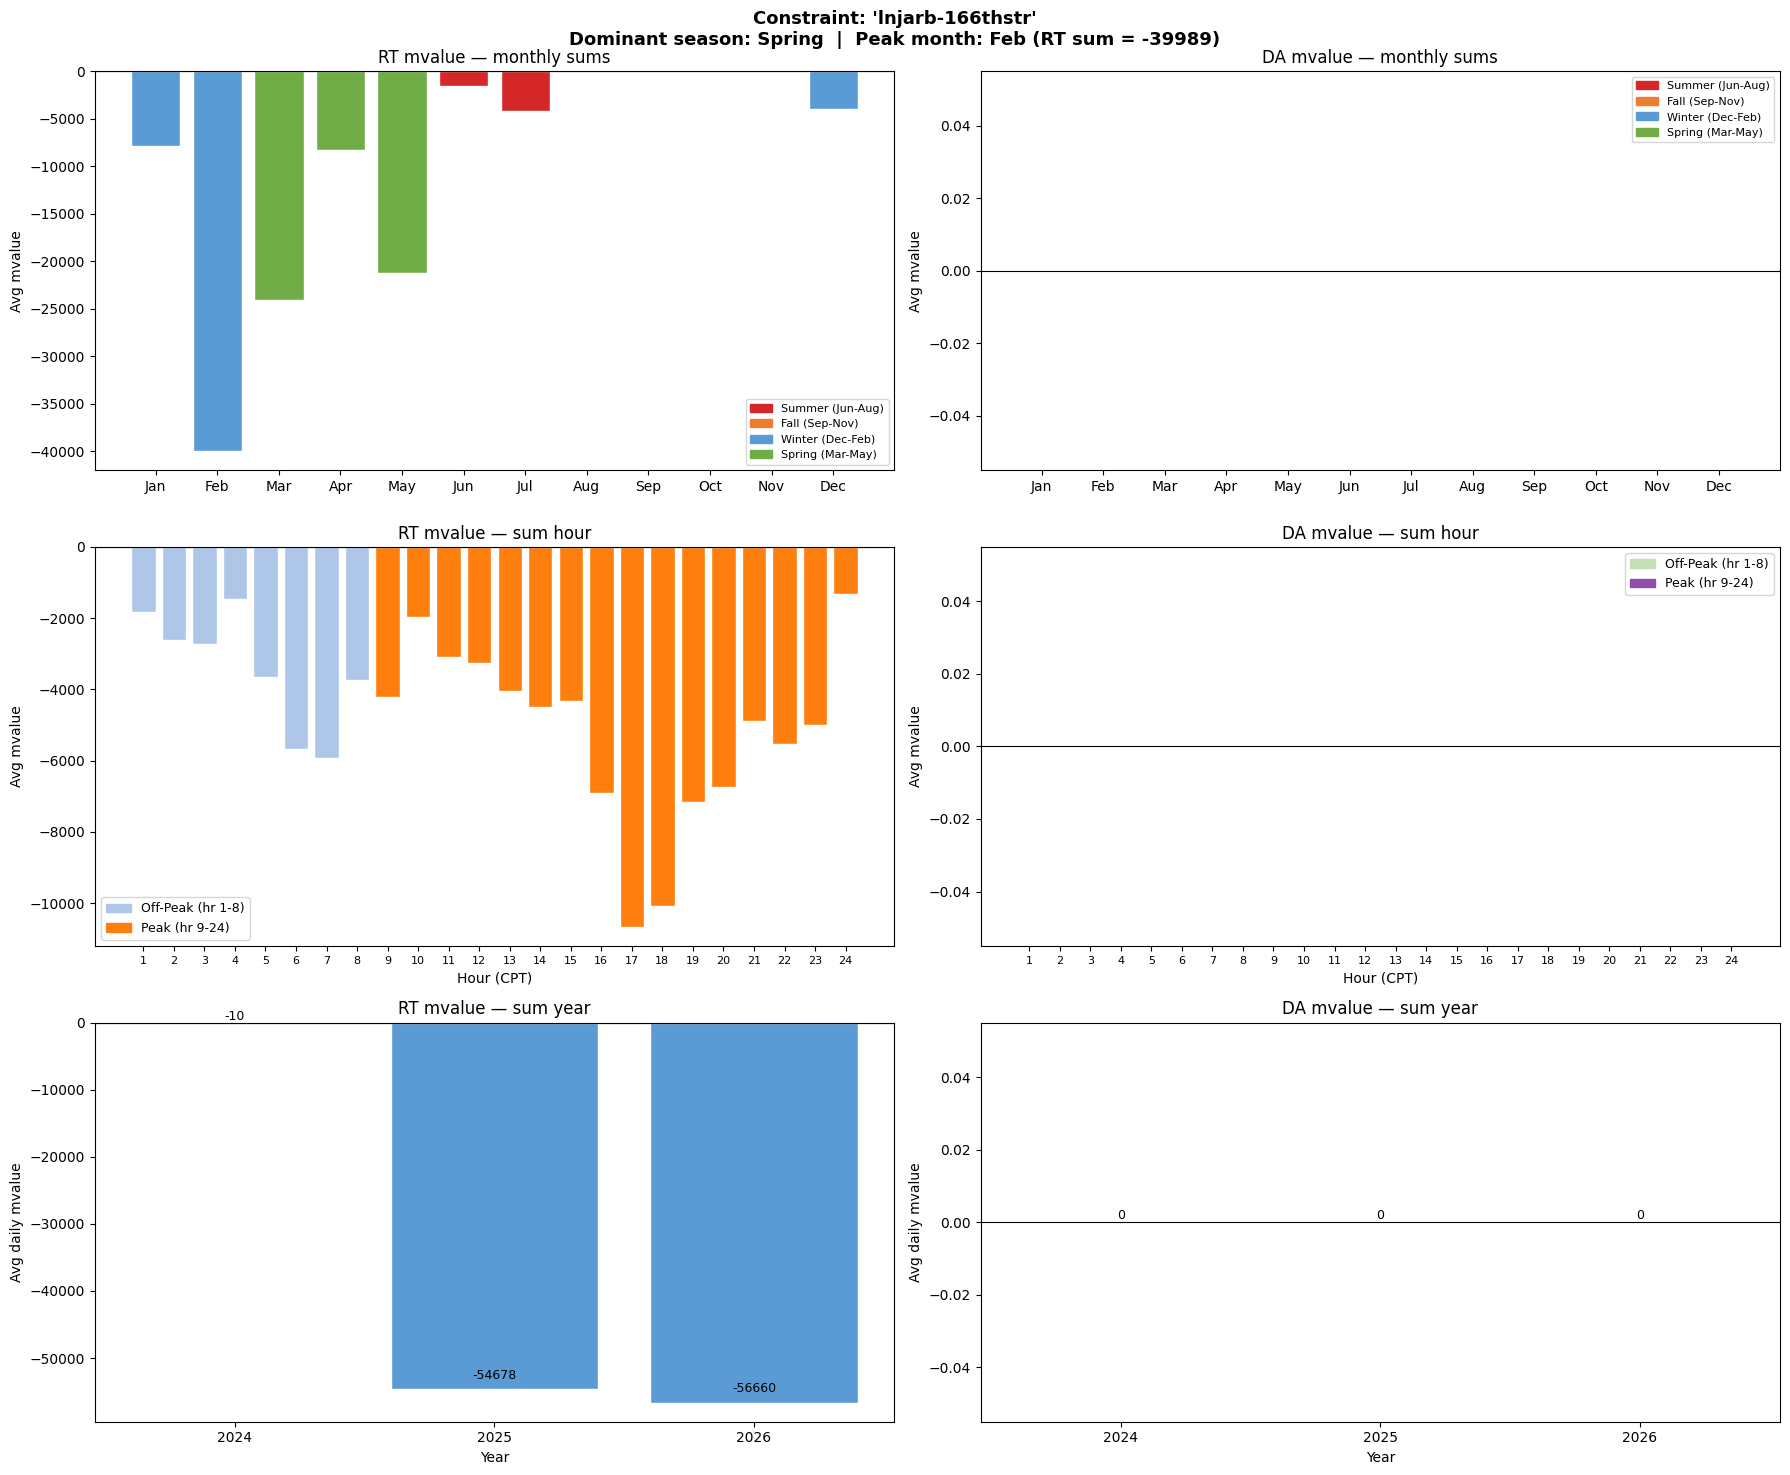

Dominant season : Spring

RT  peak sum   (hr  9-24):  -83688.45  |  off-peak (hr 1-8):  -27659.55
DA  peak sum   (hr  9-24):       0.00  |  off-peak (hr 1-8):       0.00
'lnjarb-166thstr'  |  2026-05-18 → 2026-05-28  |  4 days


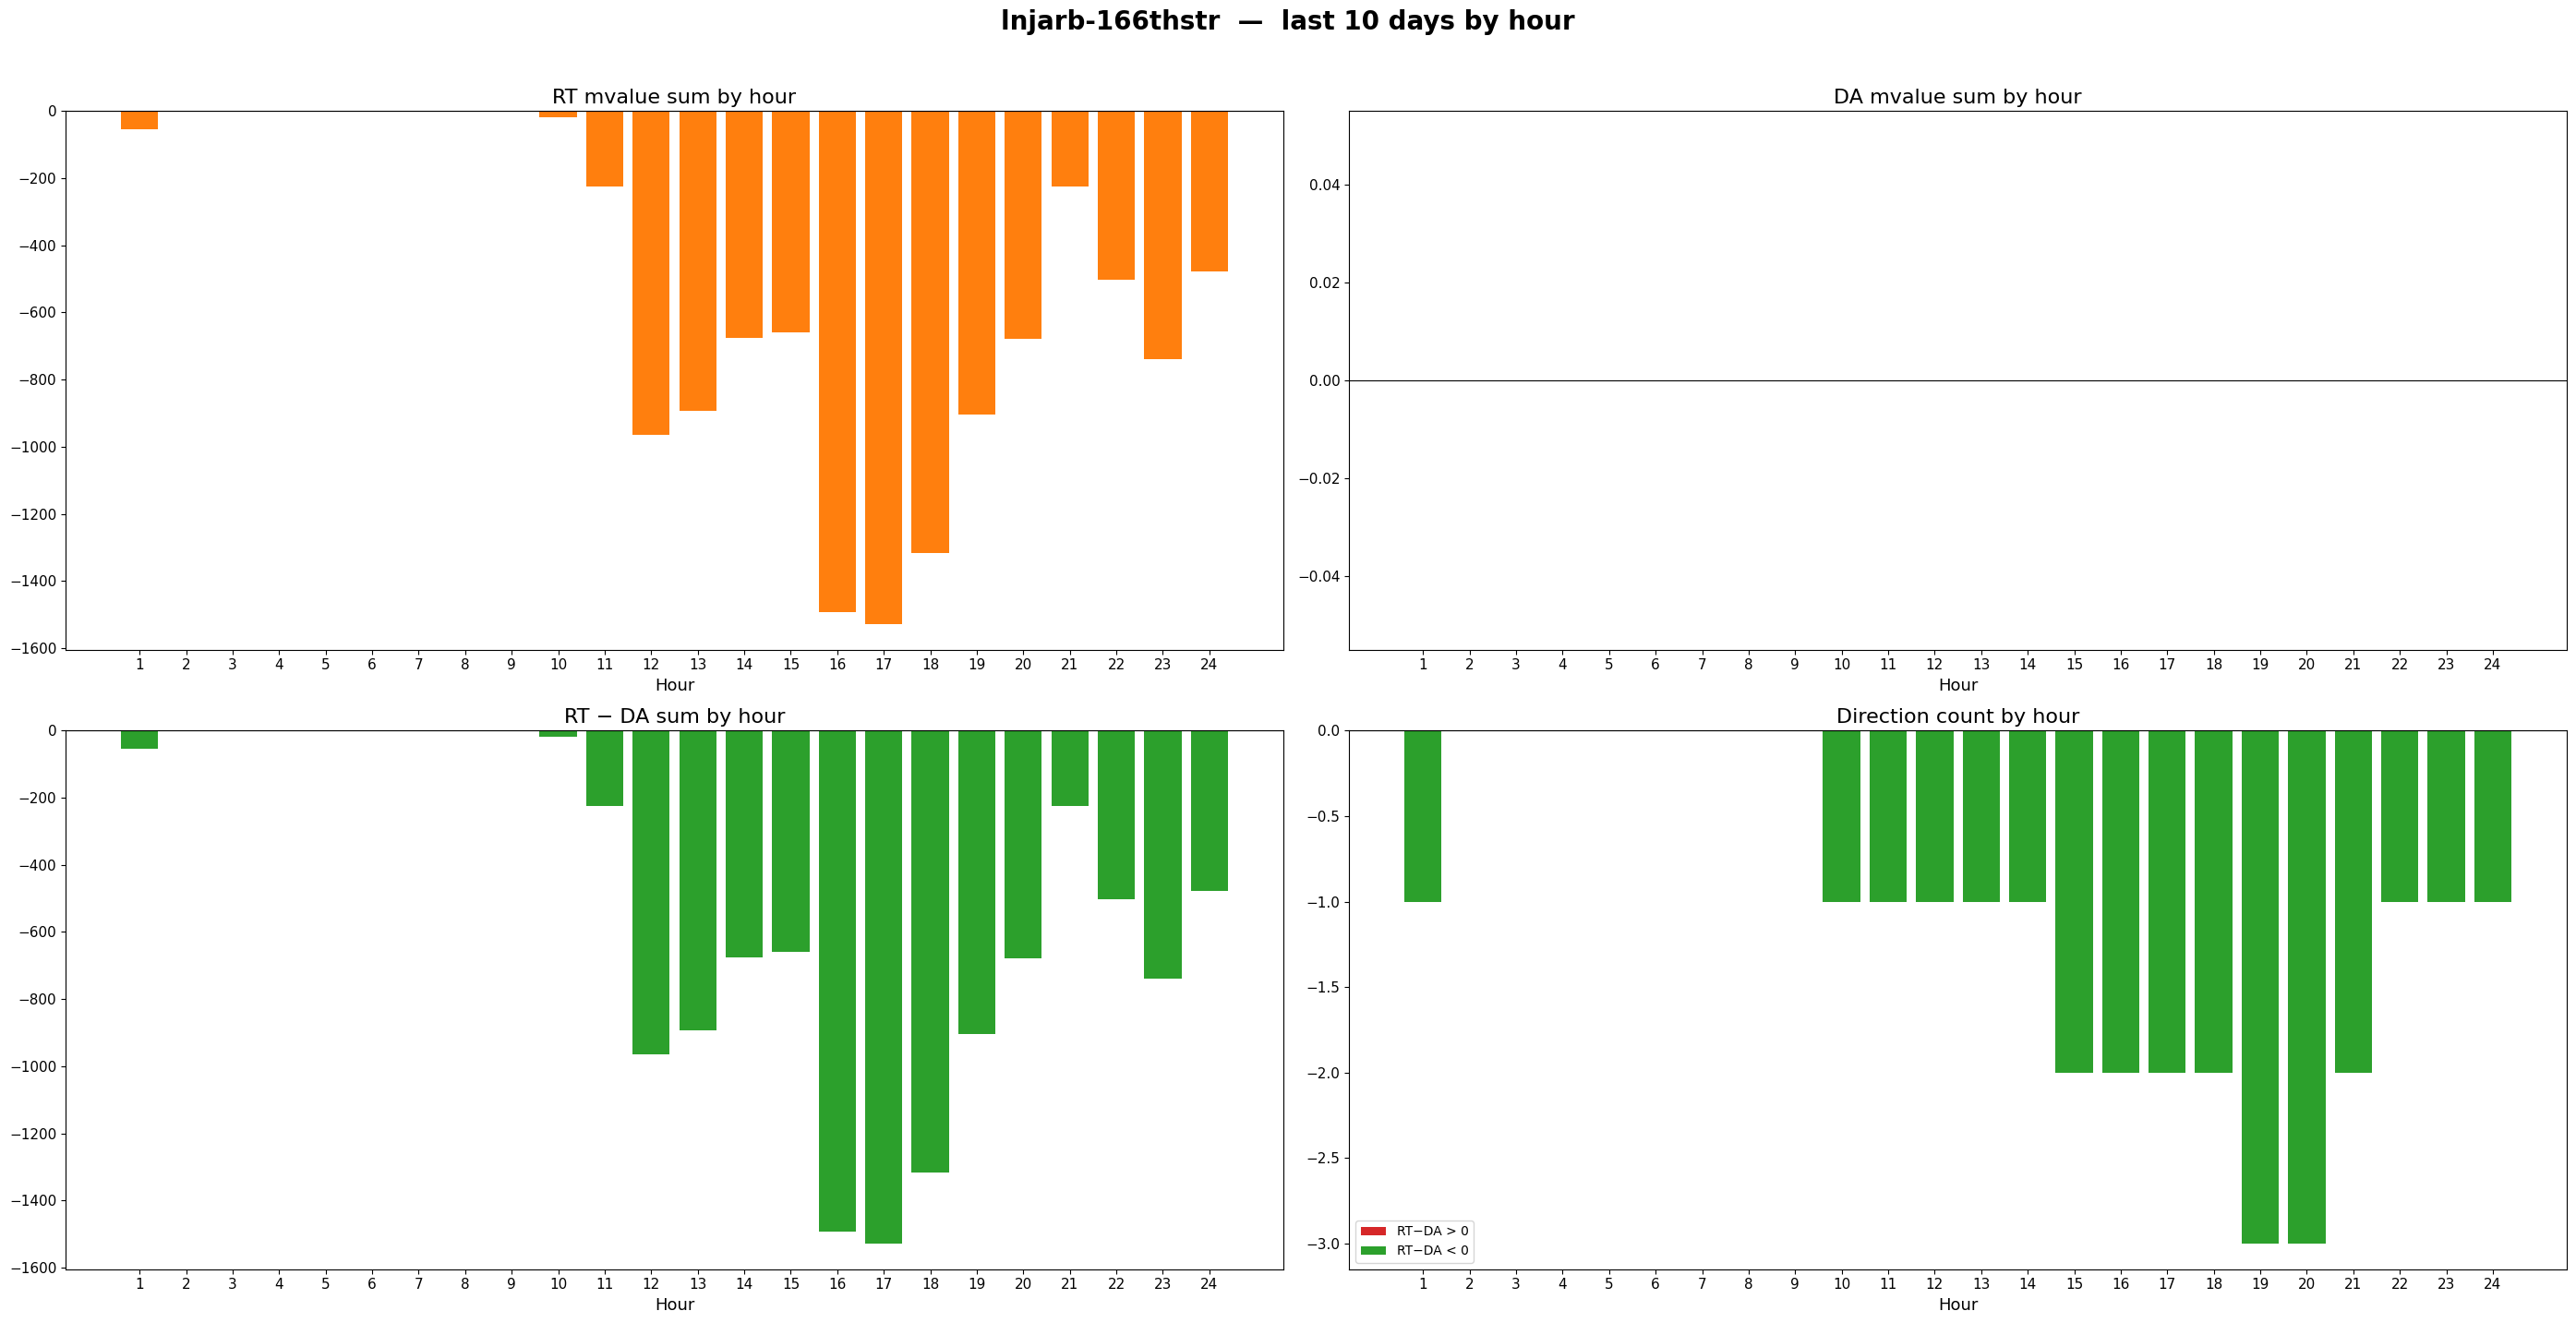


Total rows: 5610

  lnjarb-166thstr


,node_num,dfax,corr,sign_acc,mean_pred,mean_actual,n
0,1690,0.0902,0.688473,0.609442,26.349233,15.033383,233.0
1,1430,0.0864,0.524297,0.696078,38.007056,44.347637,102.0
2,1678,-0.0778,0.519708,0.824034,-22.726944,-18.734949,233.0
3,1447,-0.1667,0.413415,0.813725,-73.330743,-38.131592,102.0
4,782,-0.0916,0.263936,0.739394,-30.907505,-14.761041,330.0
5,781,-0.0914,0.255890,0.748485,-30.840022,-17.231369,330.0
6,227,-0.0837,0.217193,0.736364,-28.241902,-14.709751,330.0
7,1235,-0.0679,0.177905,0.790909,-22.910695,-18.966503,330.0
8,1336,-0.0679,0.177905,0.790909,-22.910695,-18.966503,330.0
9,1496,-0.0679,0.177905,0.790909,-22.910695,-18.966503,330.0


Constraint  : 'xfmrsiouxcy-siouxcy'
Reserve zone: 4  |  Columns: ['rz4_spp_res_zonal_wind_forecast_f', 'rz4_spp_res_zonal_load_forecast_f']
Baseline binding rate: 0.0227  |  Total hours: 17496


,monitored,reserve_zone,fundamental,baseline_prob,cond_prob_top95pct,lift_pct
1,xfmrsiouxcy-siouxcy,4,rz4_spp_res_zonal_load_forecast_f,0.0227,0.0971,3.28
0,xfmrsiouxcy-siouxcy,4,rz4_spp_res_zonal_wind_forecast_f,0.0227,0.0011,-0.95


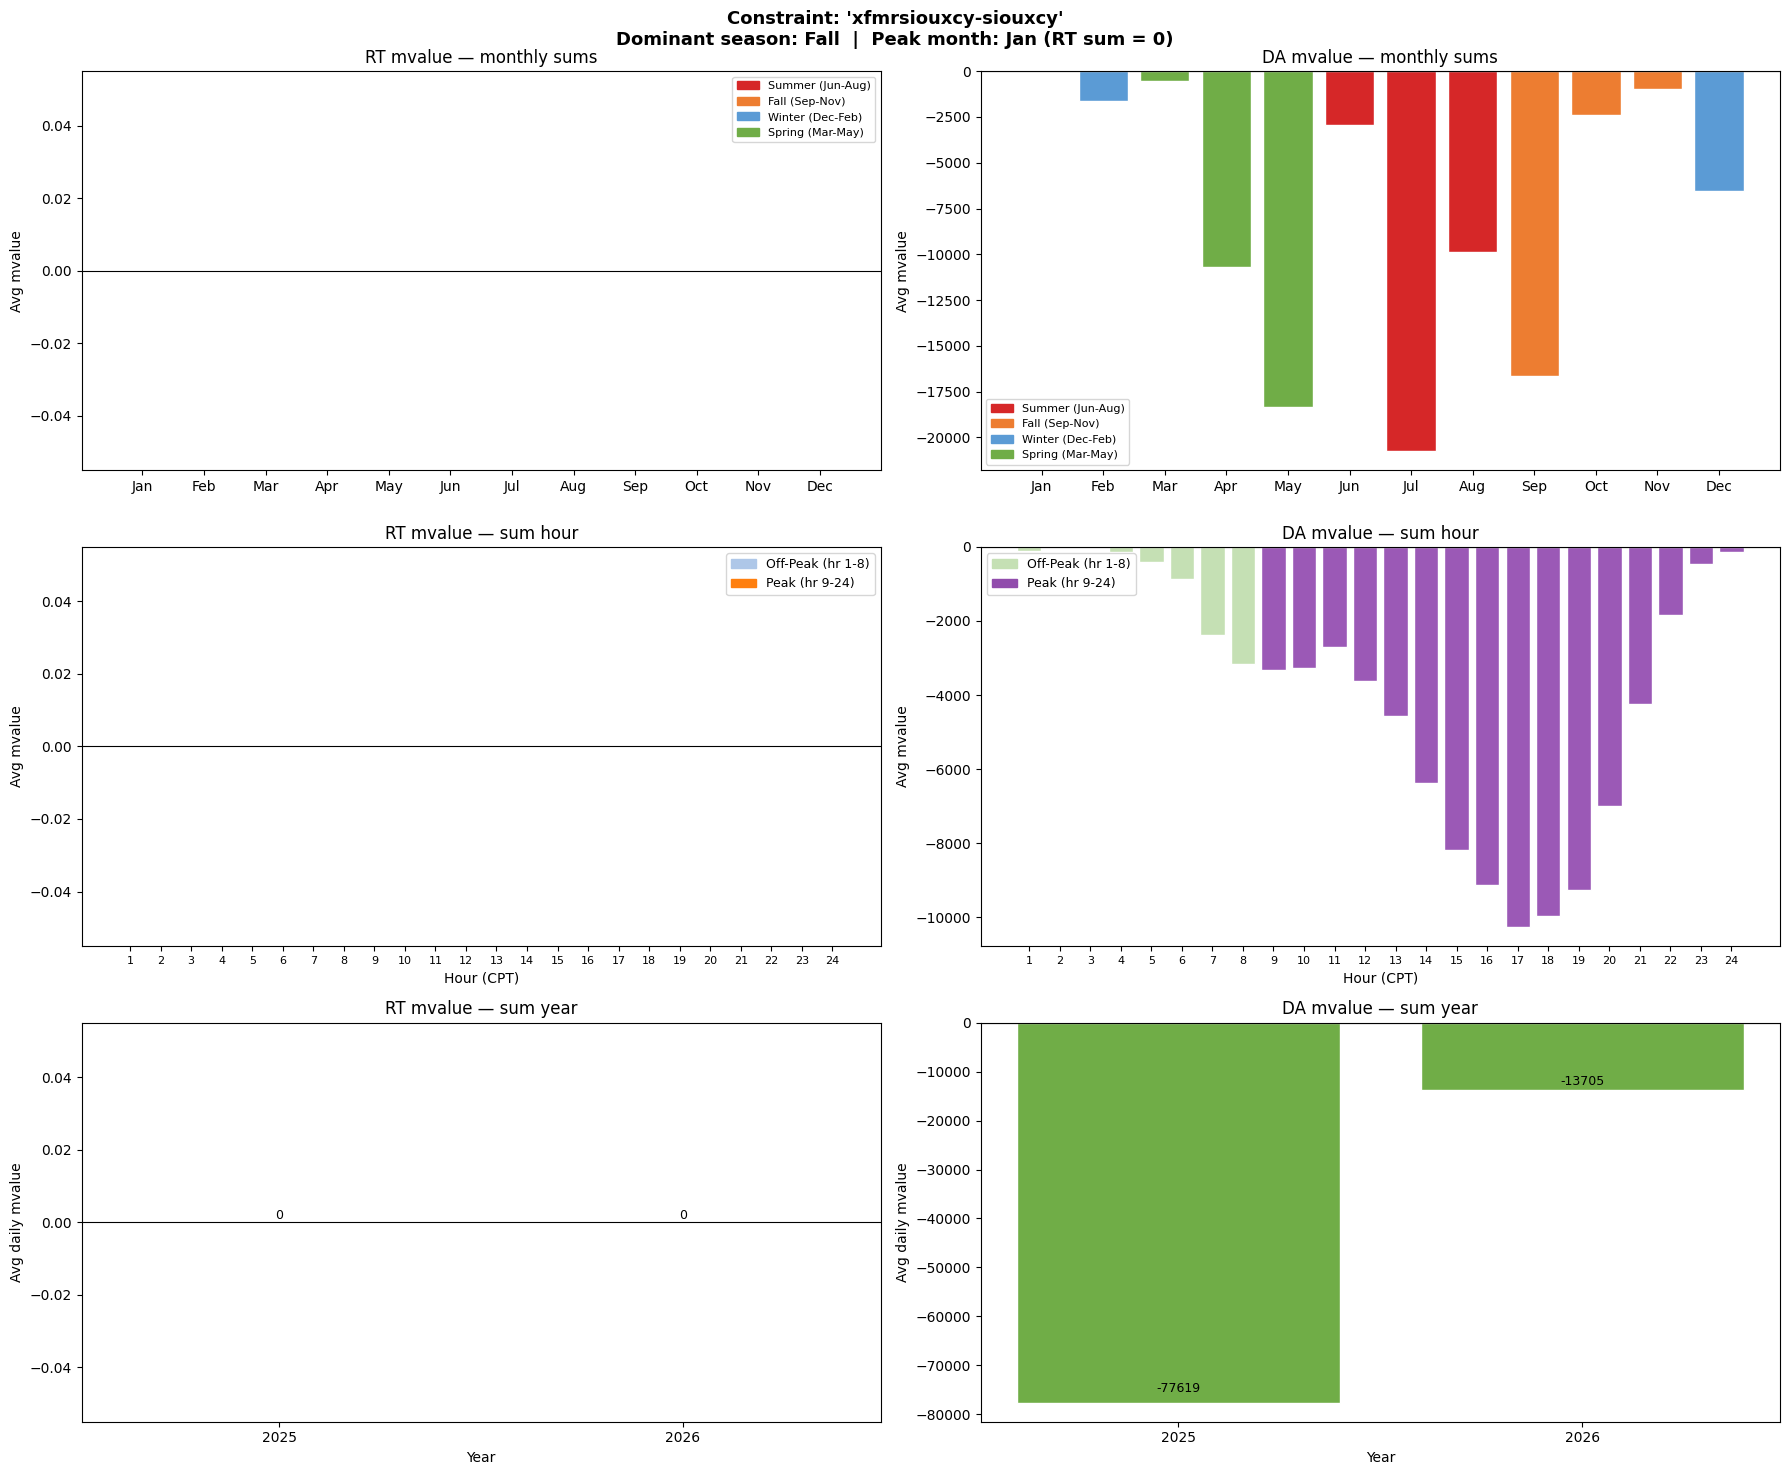

Dominant season : Fall

RT  peak sum   (hr  9-24):       0.00  |  off-peak (hr 1-8):       0.00
DA  peak sum   (hr  9-24):  -84261.51  |  off-peak (hr 1-8):   -7062.18
'xfmrsiouxcy-siouxcy'  |  2026-05-18 → 2026-05-28  |  2 days


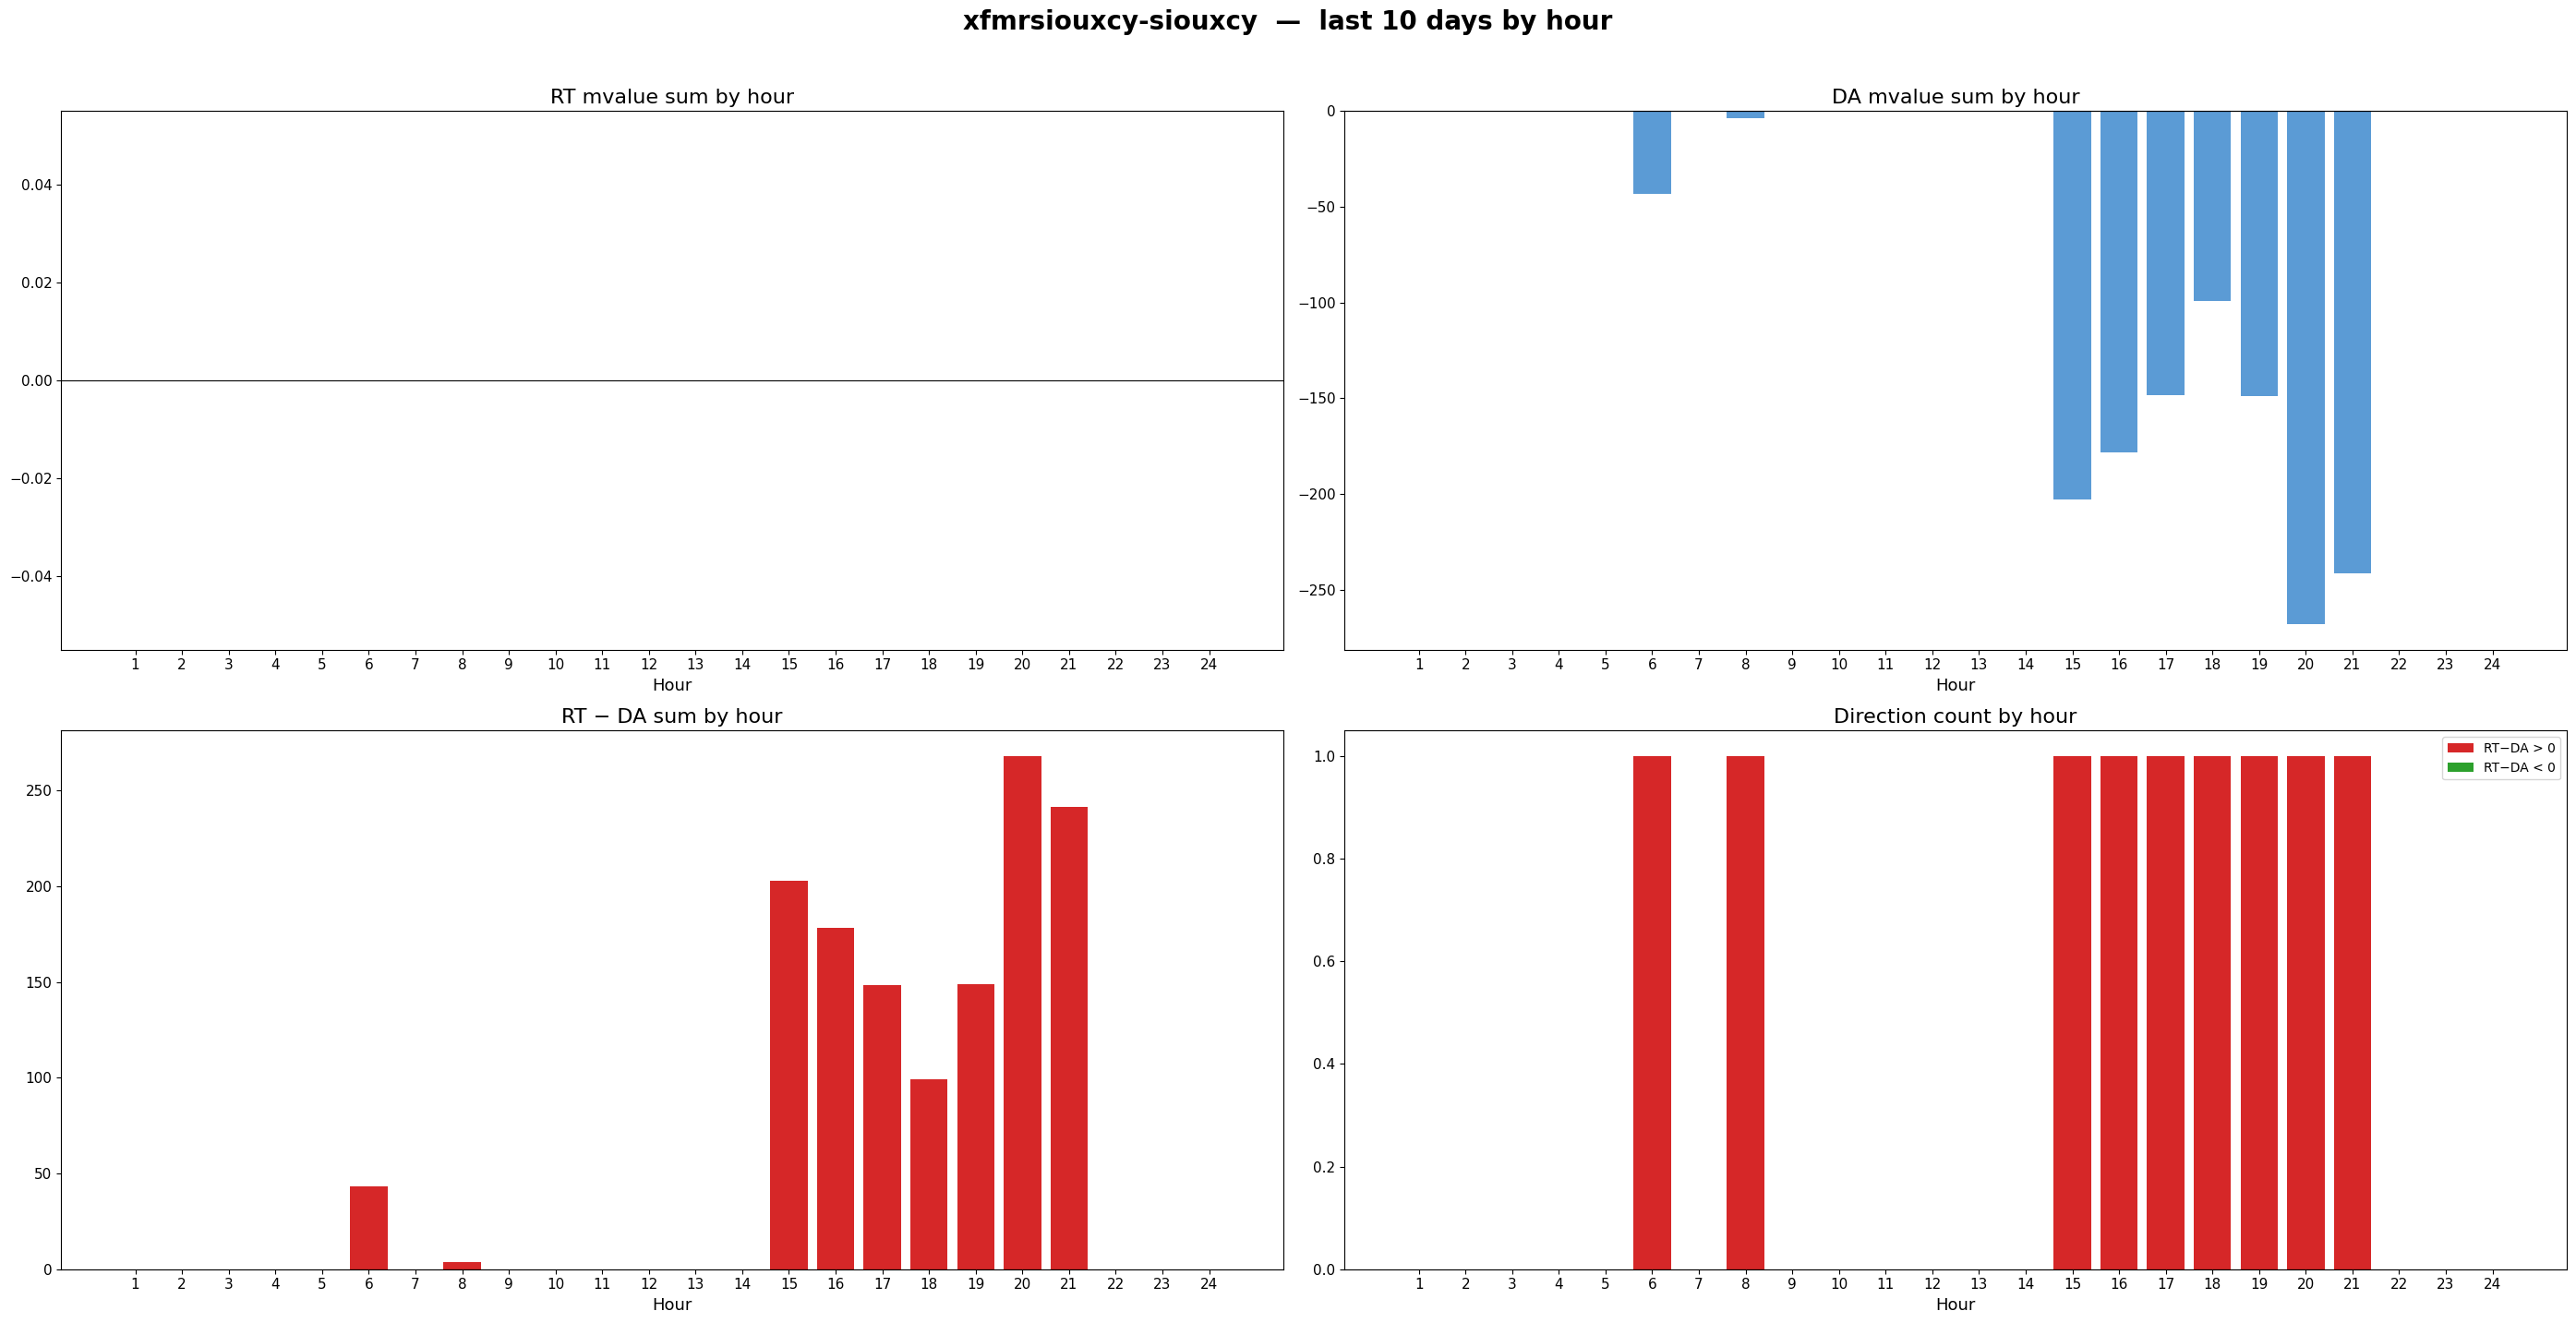


Total rows: 13498

  xfmrsiouxcy-siouxcy


,node_num,dfax,corr,sign_acc,mean_pred,mean_actual,n
0,1176,0.1347,0.365327,0.760204,-31.069570,-16.681824,392.0
1,857,0.1012,0.344442,0.742347,-23.342543,-12.570146,392.0
2,934,0.1112,0.344298,0.747449,-25.649118,-13.711199,392.0
3,935,0.0920,0.334202,0.732143,-21.220493,-10.919539,392.0
4,900,0.0886,0.332268,0.729592,-20.436258,-10.577766,392.0
5,873,0.0842,0.331465,0.729592,-19.421365,-10.505521,392.0
6,938,0.1152,0.329720,0.744898,-26.571748,-12.965917,392.0
7,930,0.0871,0.328643,0.729592,-20.090271,-10.795684,392.0
8,904,0.1137,0.328480,0.744898,-26.225762,-12.699059,392.0
9,1233,0.1137,0.328480,0.744898,-26.225762,-12.699059,392.0


Constraint  : 'lnfirstcrk-roanrdge'
Reserve zone: 4  |  Columns: ['rz4_spp_res_zonal_wind_forecast_f', 'rz4_spp_res_zonal_load_forecast_f']
Baseline binding rate: 0.0245  |  Total hours: 17496


,monitored,reserve_zone,fundamental,baseline_prob,cond_prob_top95pct,lift_pct
1,lnfirstcrk-roanrdge,4,rz4_spp_res_zonal_load_forecast_f,0.0245,0.0846,2.45
0,lnfirstcrk-roanrdge,4,rz4_spp_res_zonal_wind_forecast_f,0.0245,0.0800,2.26


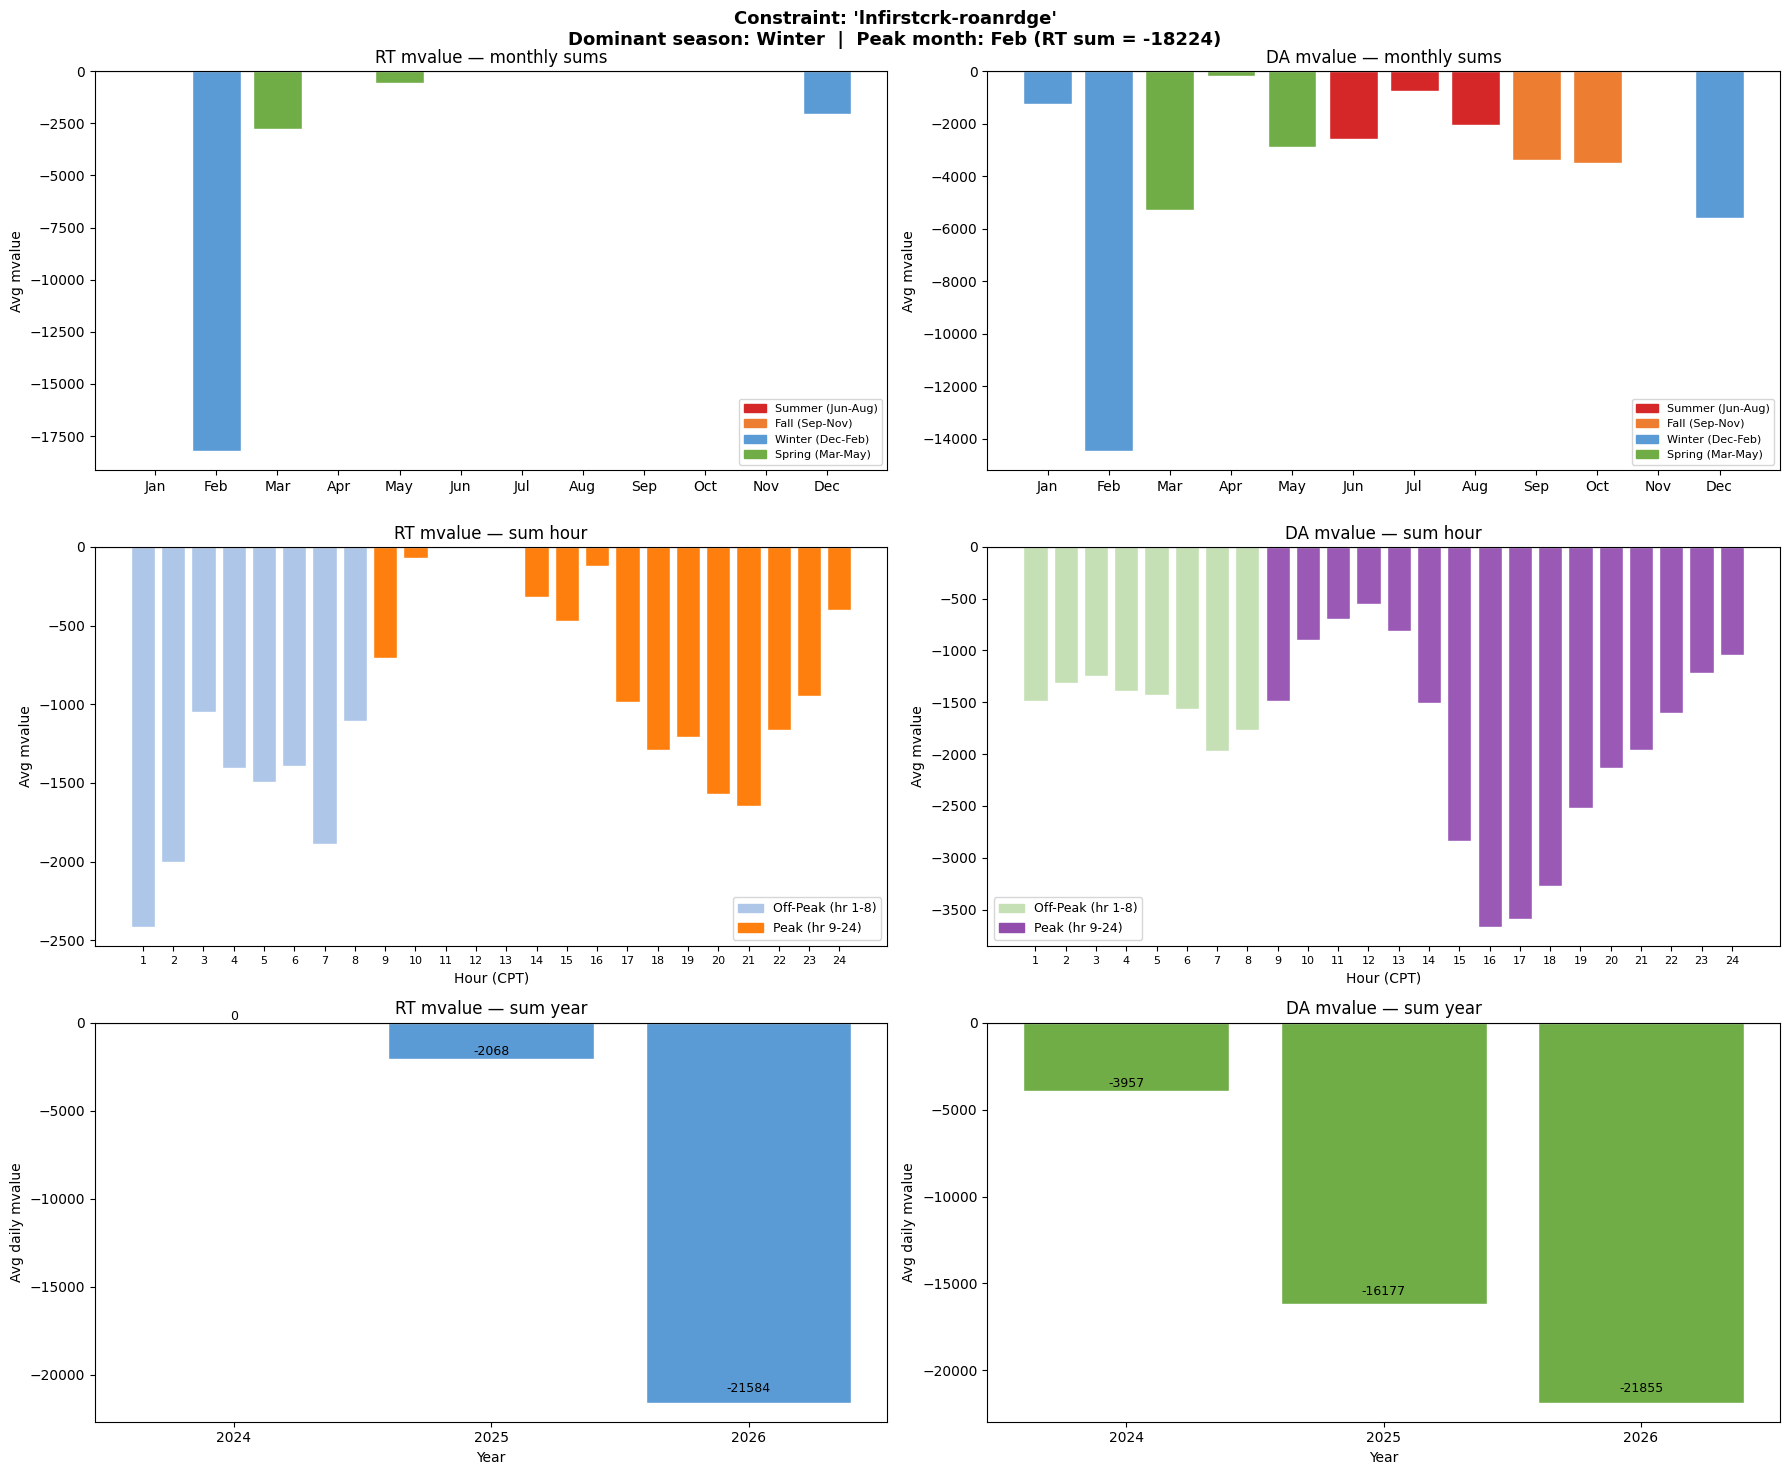

Dominant season : Winter

RT  peak sum   (hr  9-24):  -10906.49  |  off-peak (hr 1-8):  -12746.02
DA  peak sum   (hr  9-24):  -29816.82  |  off-peak (hr 1-8):  -12171.64
'lnfirstcrk-roanrdge'  |  2026-05-18 → 2026-05-28  |  5 days


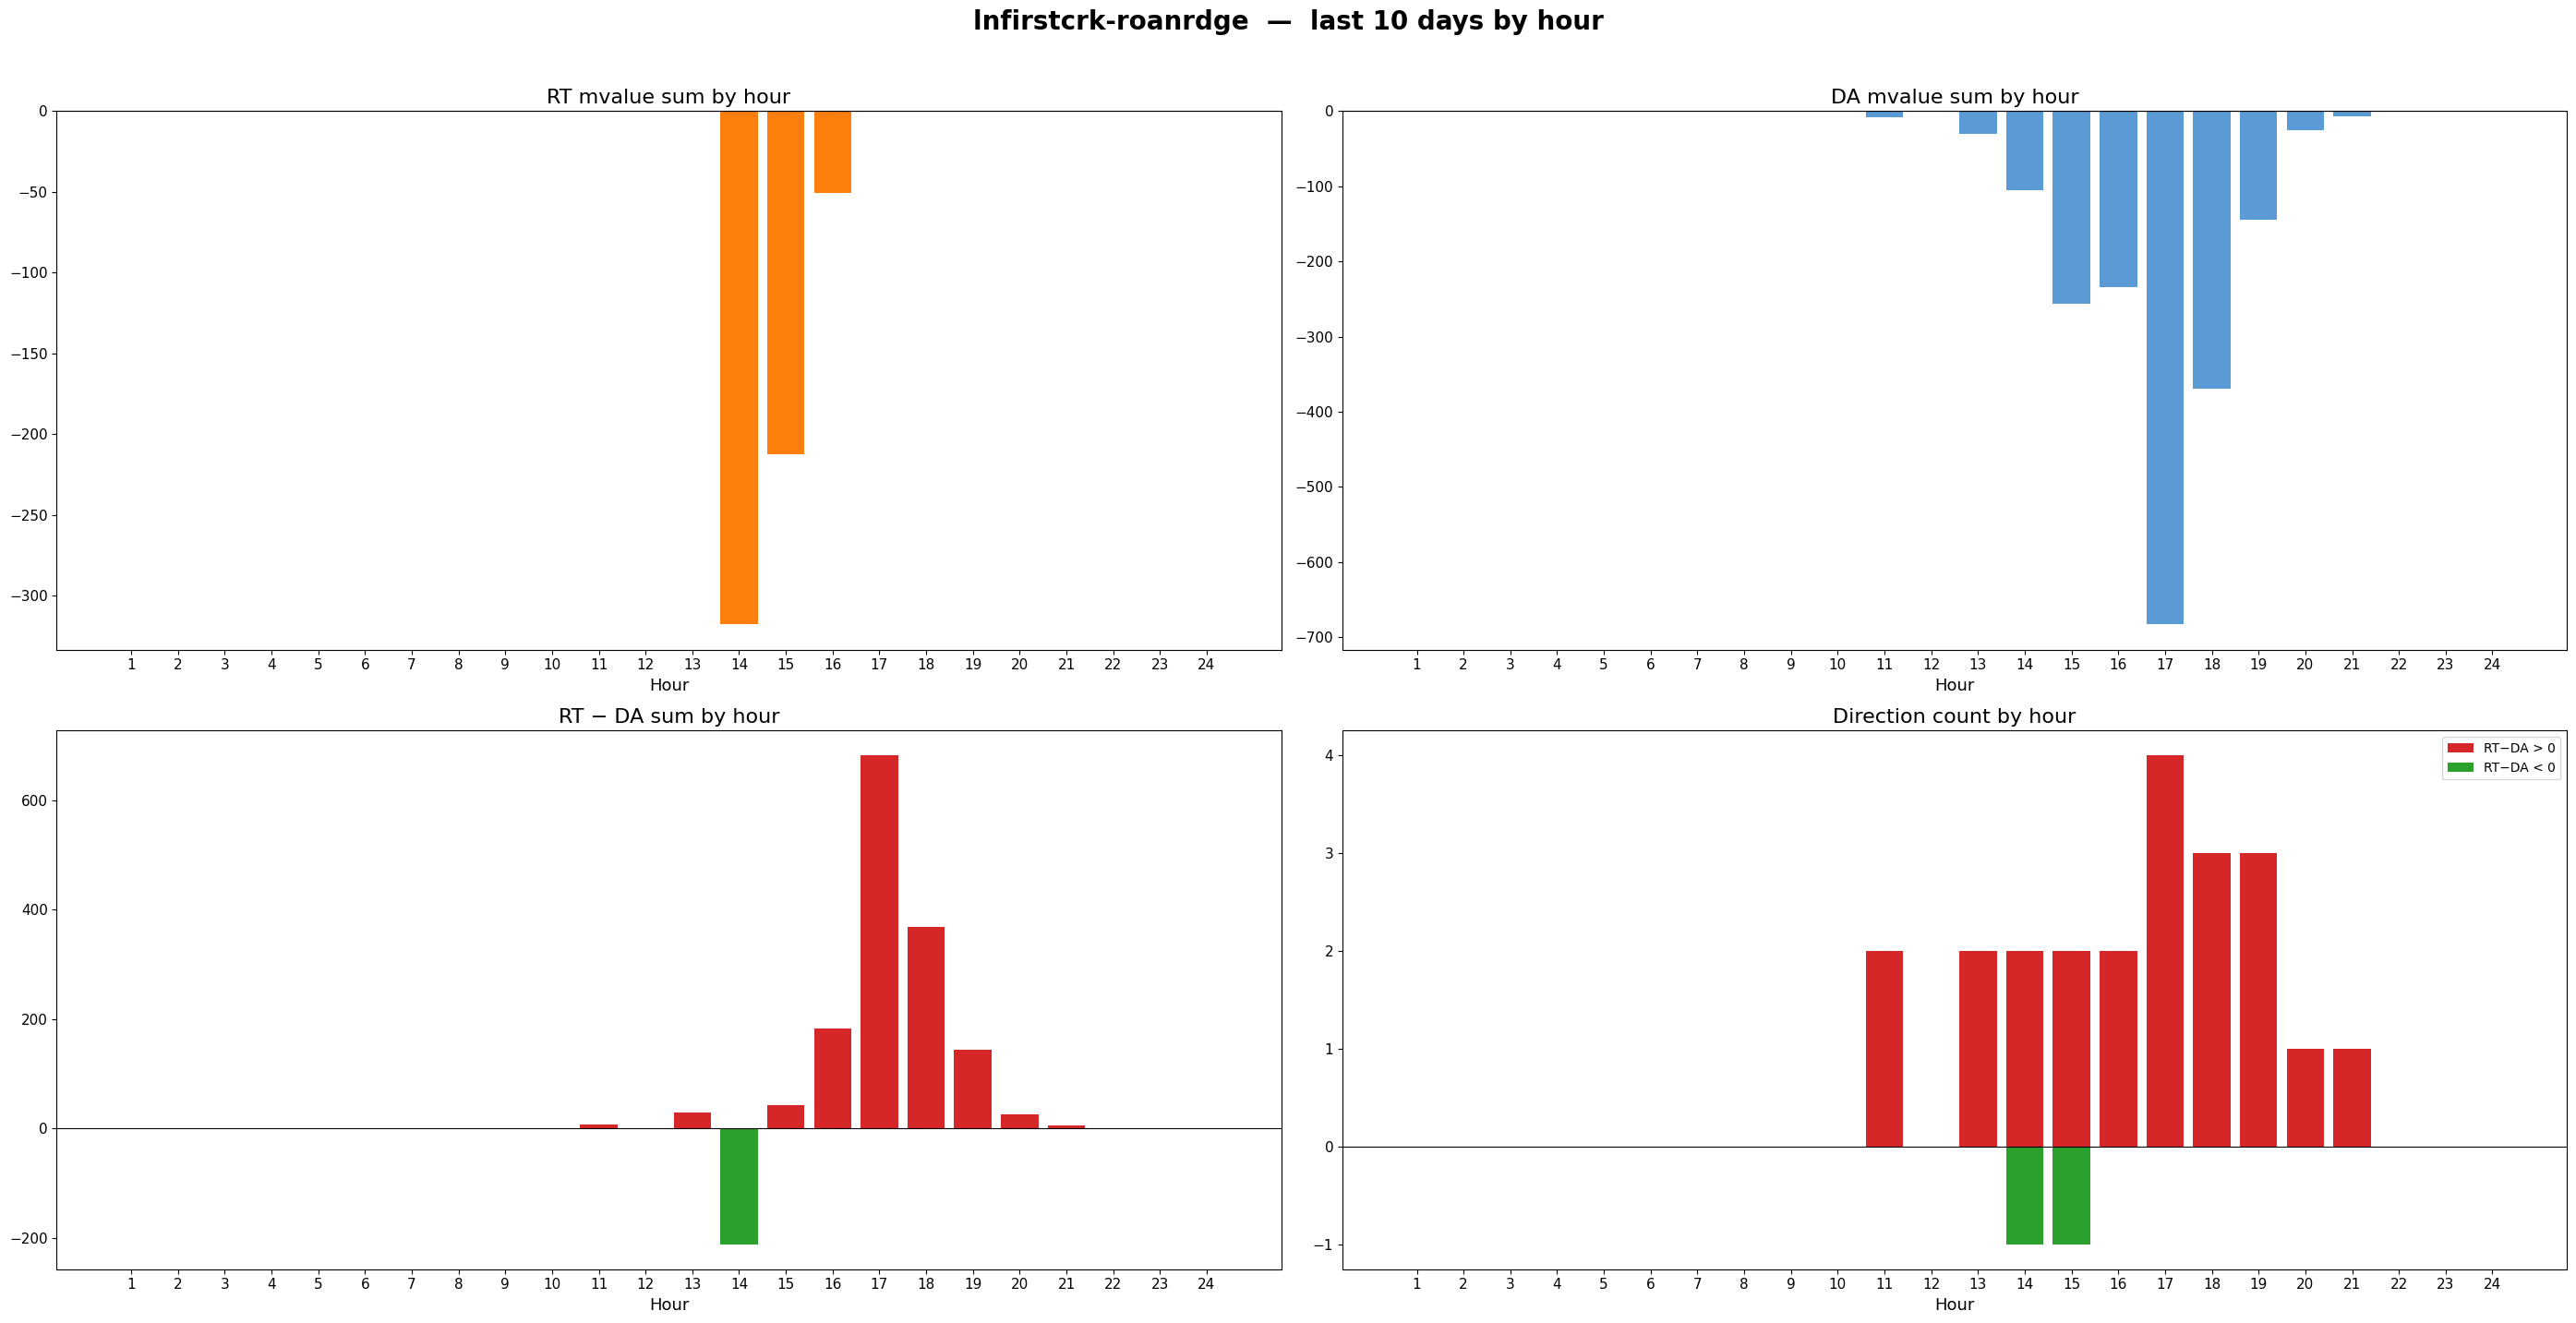

lnfirstcrk-roanrdge could not find the dfax value


Constraint  : 'lnpayne_wf-paoli2'
Reserve zone: 4  |  Columns: ['rz4_spp_res_zonal_wind_forecast_f', 'rz4_spp_res_zonal_load_forecast_f']
Baseline binding rate: 0.0233  |  Total hours: 17496


,monitored,reserve_zone,fundamental,baseline_prob,cond_prob_top95pct,lift_pct
0,lnpayne_wf-paoli2,4,rz4_spp_res_zonal_wind_forecast_f,0.0233,0.1051,3.51
1,lnpayne_wf-paoli2,4,rz4_spp_res_zonal_load_forecast_f,0.0233,0.0023,-0.90


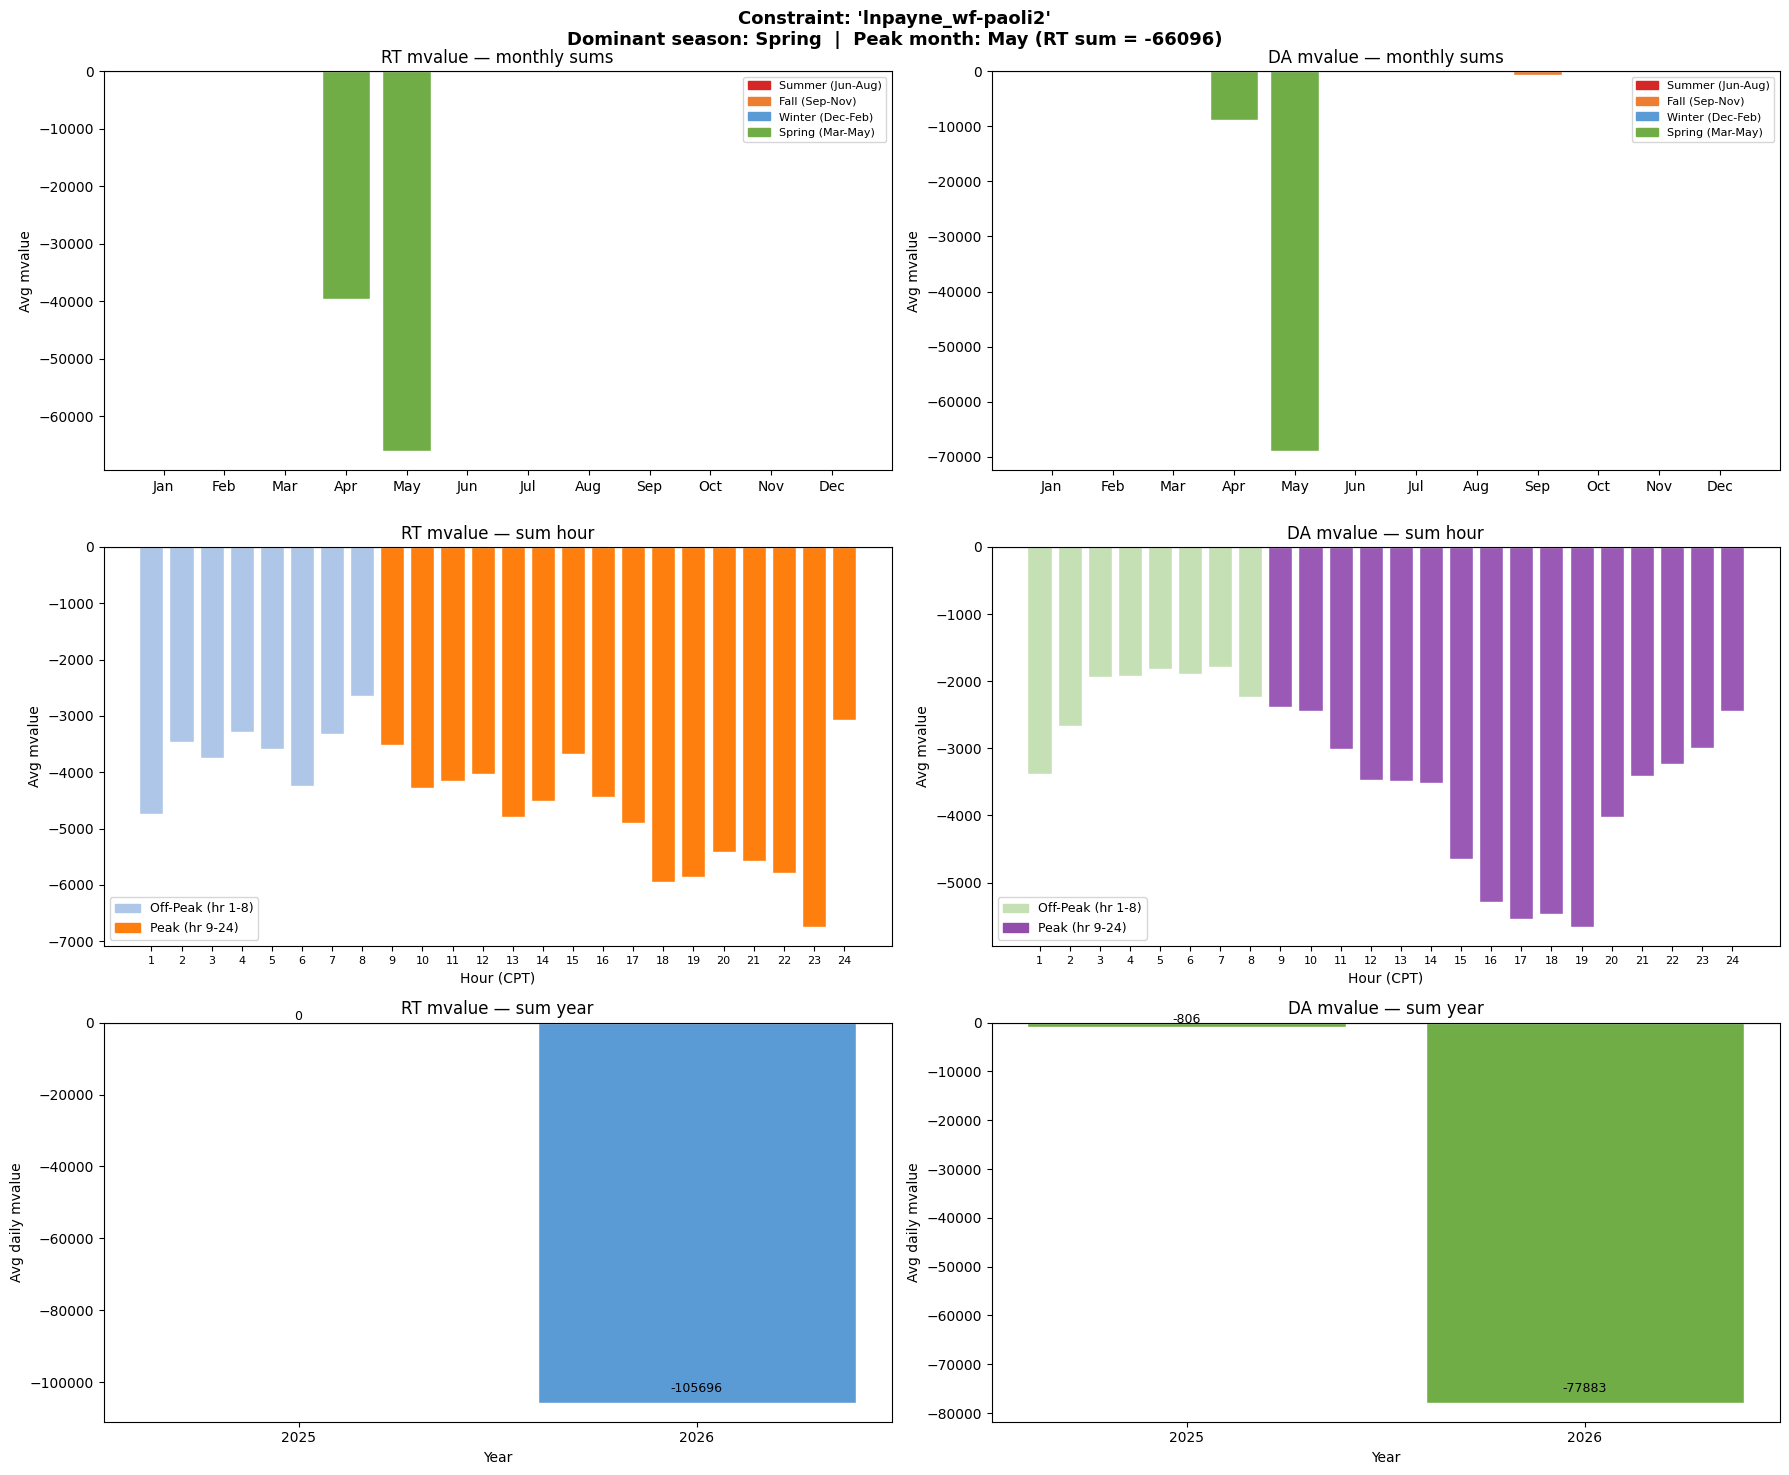

Dominant season : Spring

RT  peak sum   (hr  9-24):  -76682.05  |  off-peak (hr 1-8):  -29014.24
DA  peak sum   (hr  9-24):  -61038.12  |  off-peak (hr 1-8):  -17650.85
'lnpayne_wf-paoli2'  |  2026-05-18 → 2026-05-28  |  7 days


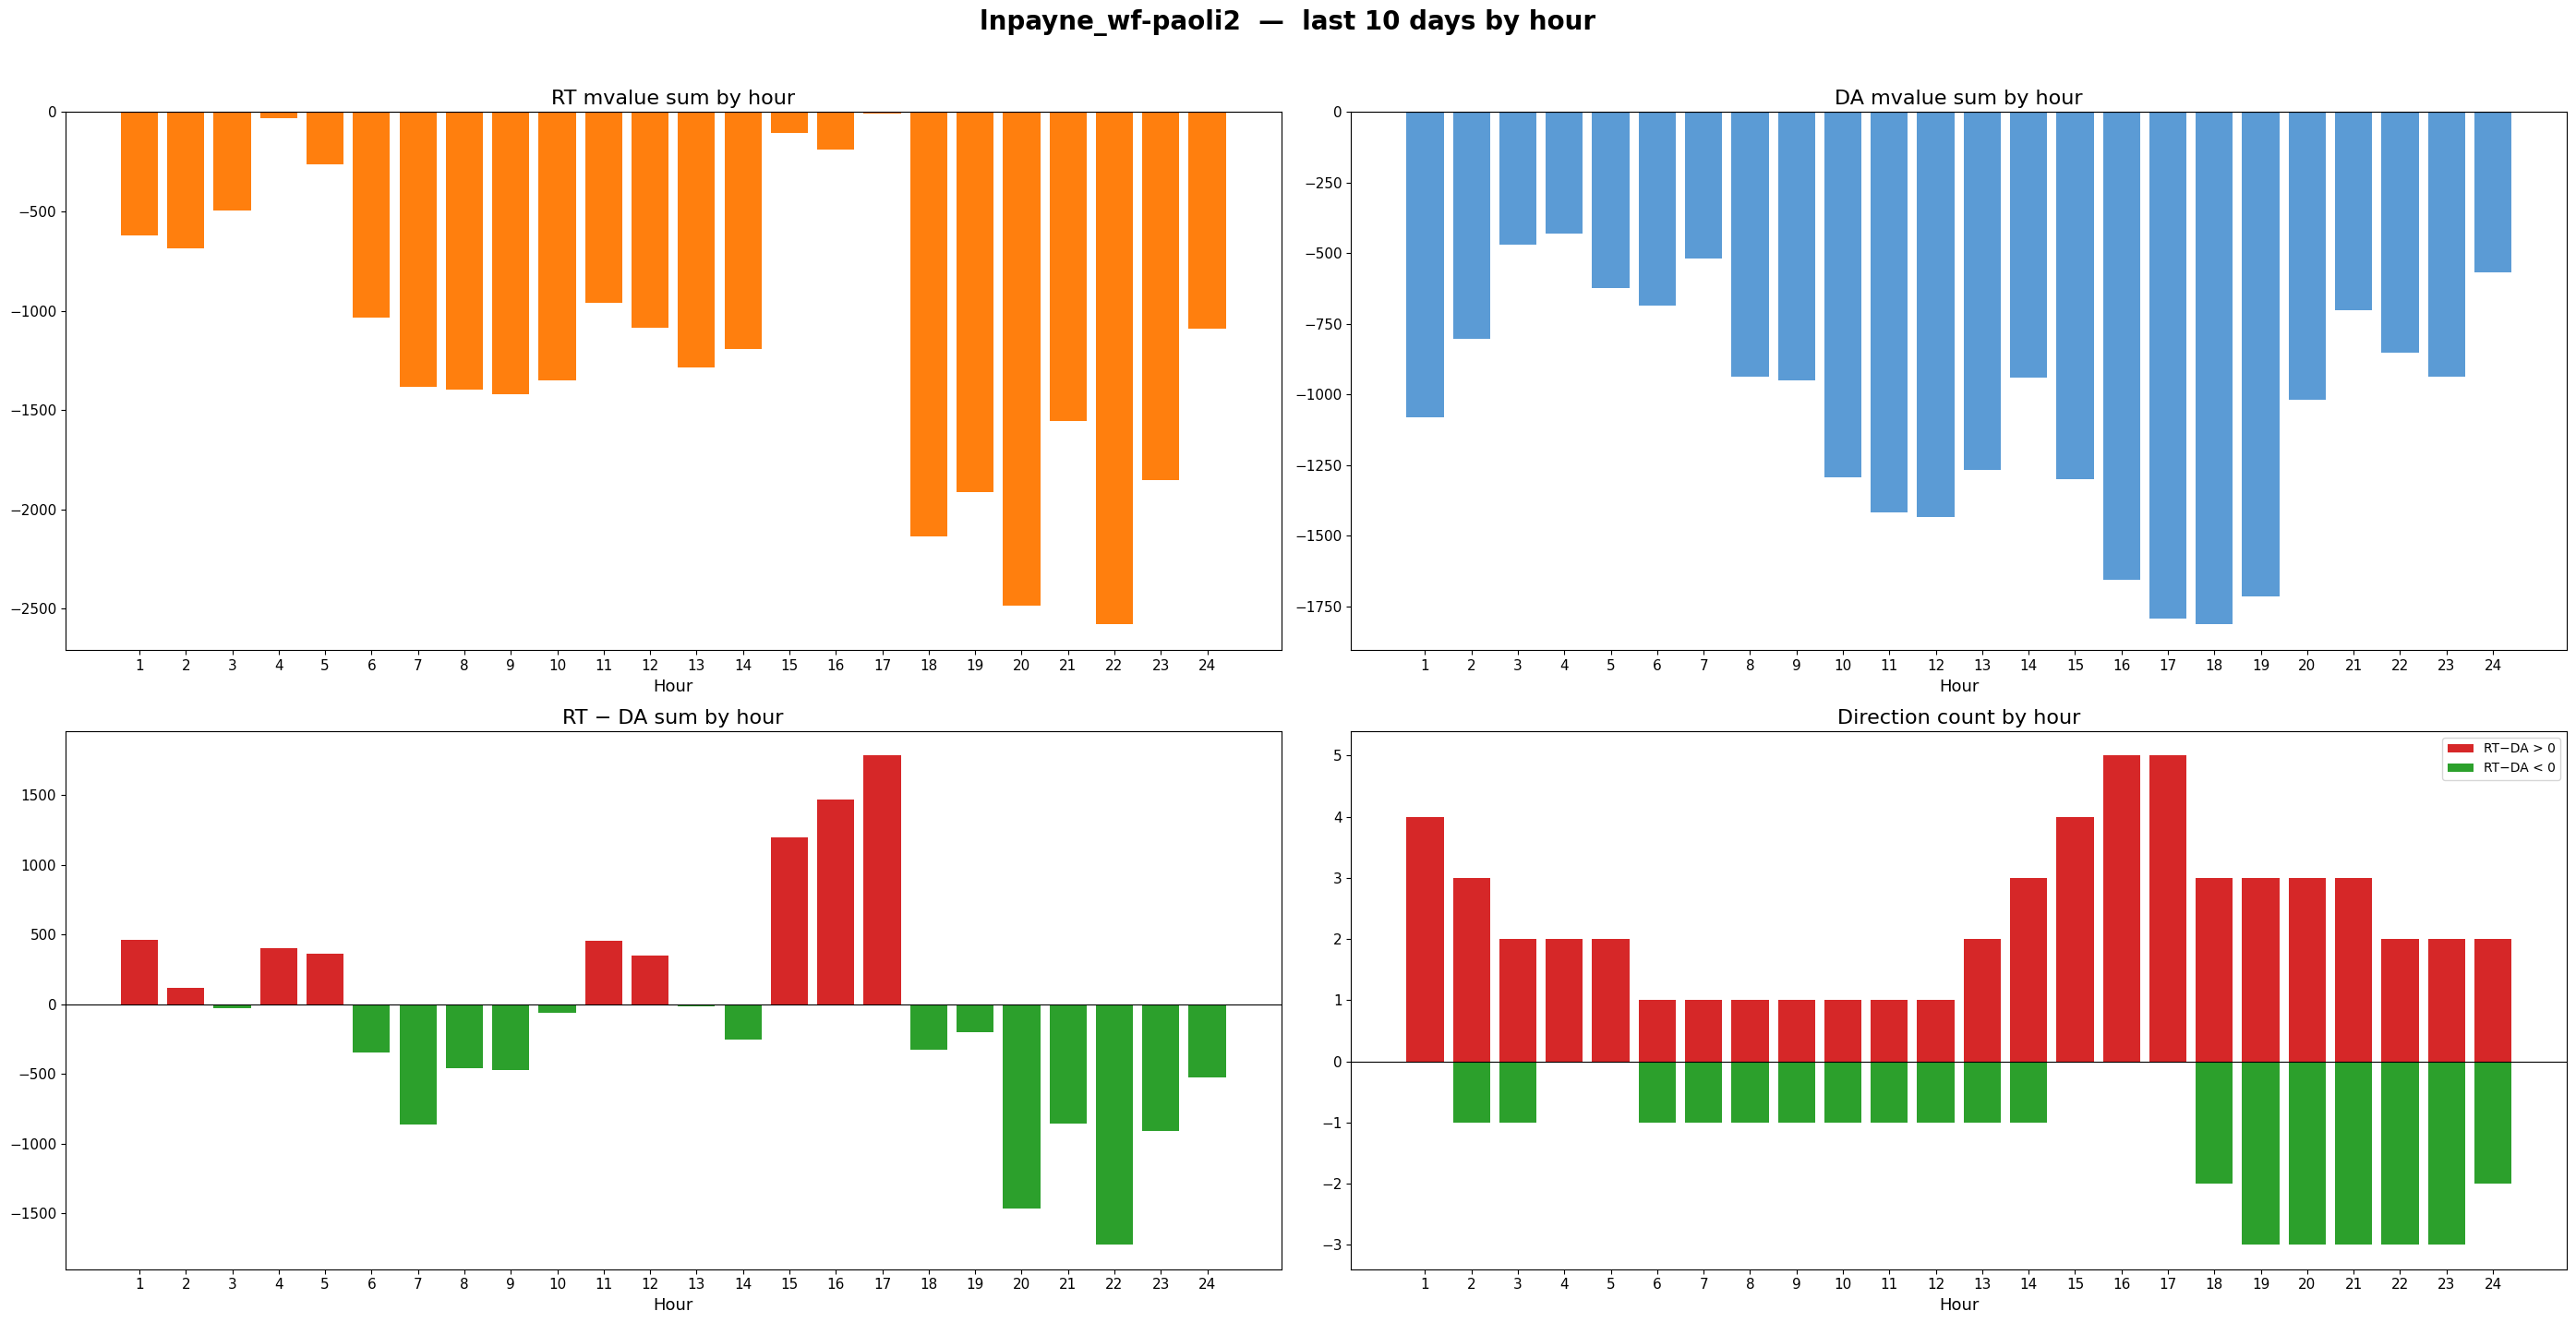


Total rows: 8640

  lnpayne_wf-paoli2


,node_num,dfax,corr,sign_acc,mean_pred,mean_actual,n
0,1038,0.1314,0.862226,0.835784,8.697944,8.282206,408.0
1,1316,0.0963,0.752793,0.774510,6.374521,1.730194,408.0
2,1625,0.0963,0.752793,0.774510,6.374521,1.730194,408.0
3,1152,0.1022,0.739452,0.757353,6.765068,0.936635,408.0
4,1164,0.1022,0.739452,0.757353,6.765068,0.936635,408.0
5,1184,0.0919,0.724044,0.747549,6.083265,0.977984,408.0
6,1474,0.0800,0.698306,0.740196,5.295552,1.049620,408.0
7,1438,-0.0592,0.663537,0.725490,-3.918709,-1.207711,408.0
8,1437,-0.0562,0.659262,0.725490,-3.720125,-1.283865,408.0
9,1039,-0.0510,0.651771,0.723039,-3.375914,-1.177187,408.0


Constraint  : 'lnwardwa-bismark2'
Reserve zone: 4  |  Columns: ['rz4_spp_res_zonal_wind_forecast_f', 'rz4_spp_res_zonal_load_forecast_f']
Baseline binding rate: 0.0457  |  Total hours: 17496


,monitored,reserve_zone,fundamental,baseline_prob,cond_prob_top95pct,lift_pct
0,lnwardwa-bismark2,4,rz4_spp_res_zonal_wind_forecast_f,0.0457,0.0903,0.98
1,lnwardwa-bismark2,4,rz4_spp_res_zonal_load_forecast_f,0.0457,0.0000,-1.00


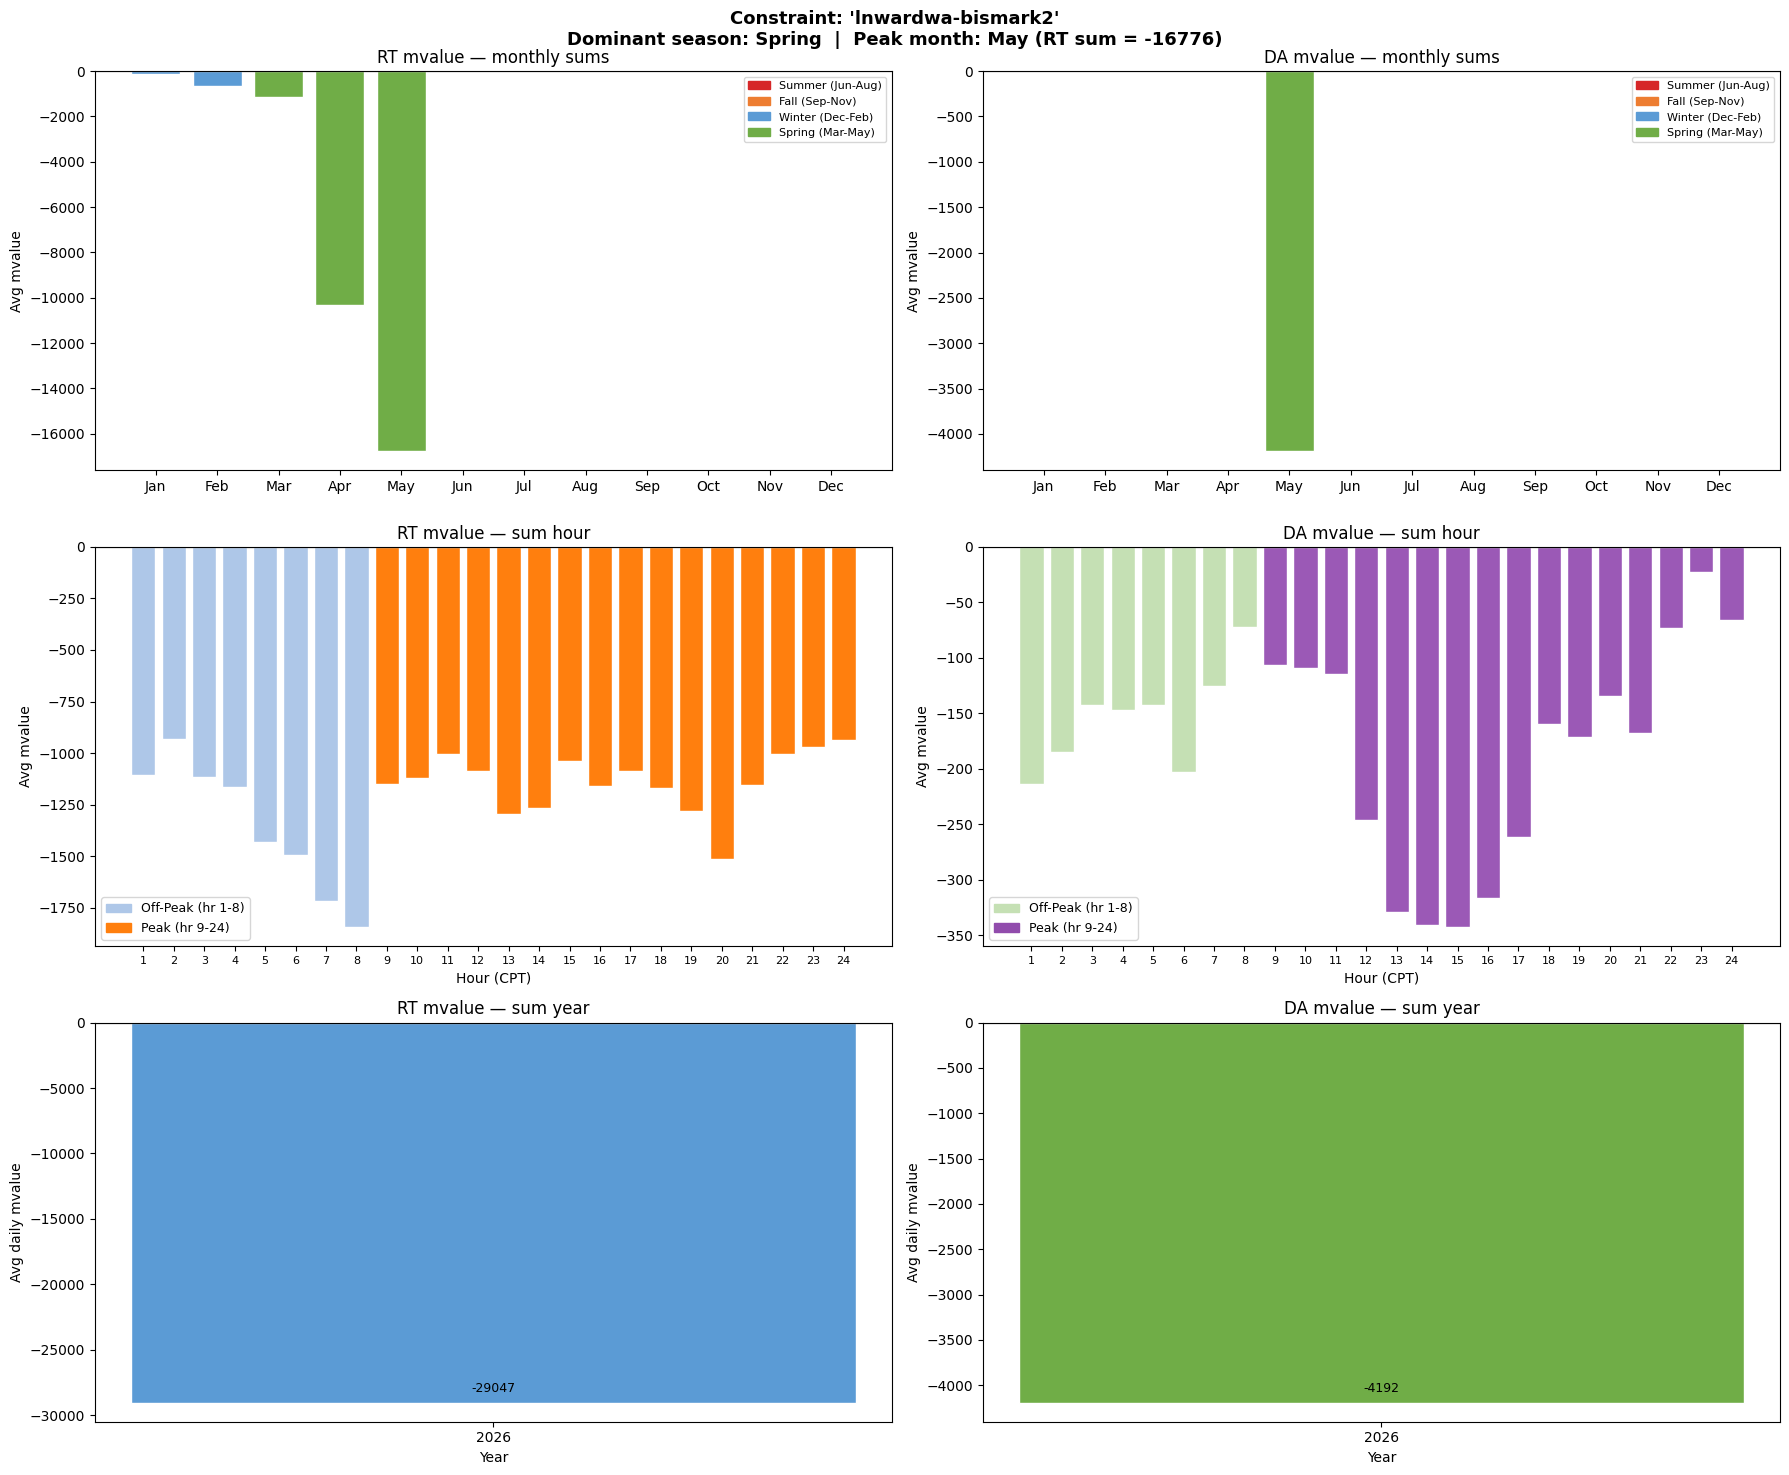

Dominant season : Spring

RT  peak sum   (hr  9-24):  -18242.74  |  off-peak (hr 1-8):  -10804.04
DA  peak sum   (hr  9-24):   -2960.26  |  off-peak (hr 1-8):   -1231.34
'lnwardwa-bismark2'  |  2026-05-18 → 2026-05-28  |  8 days


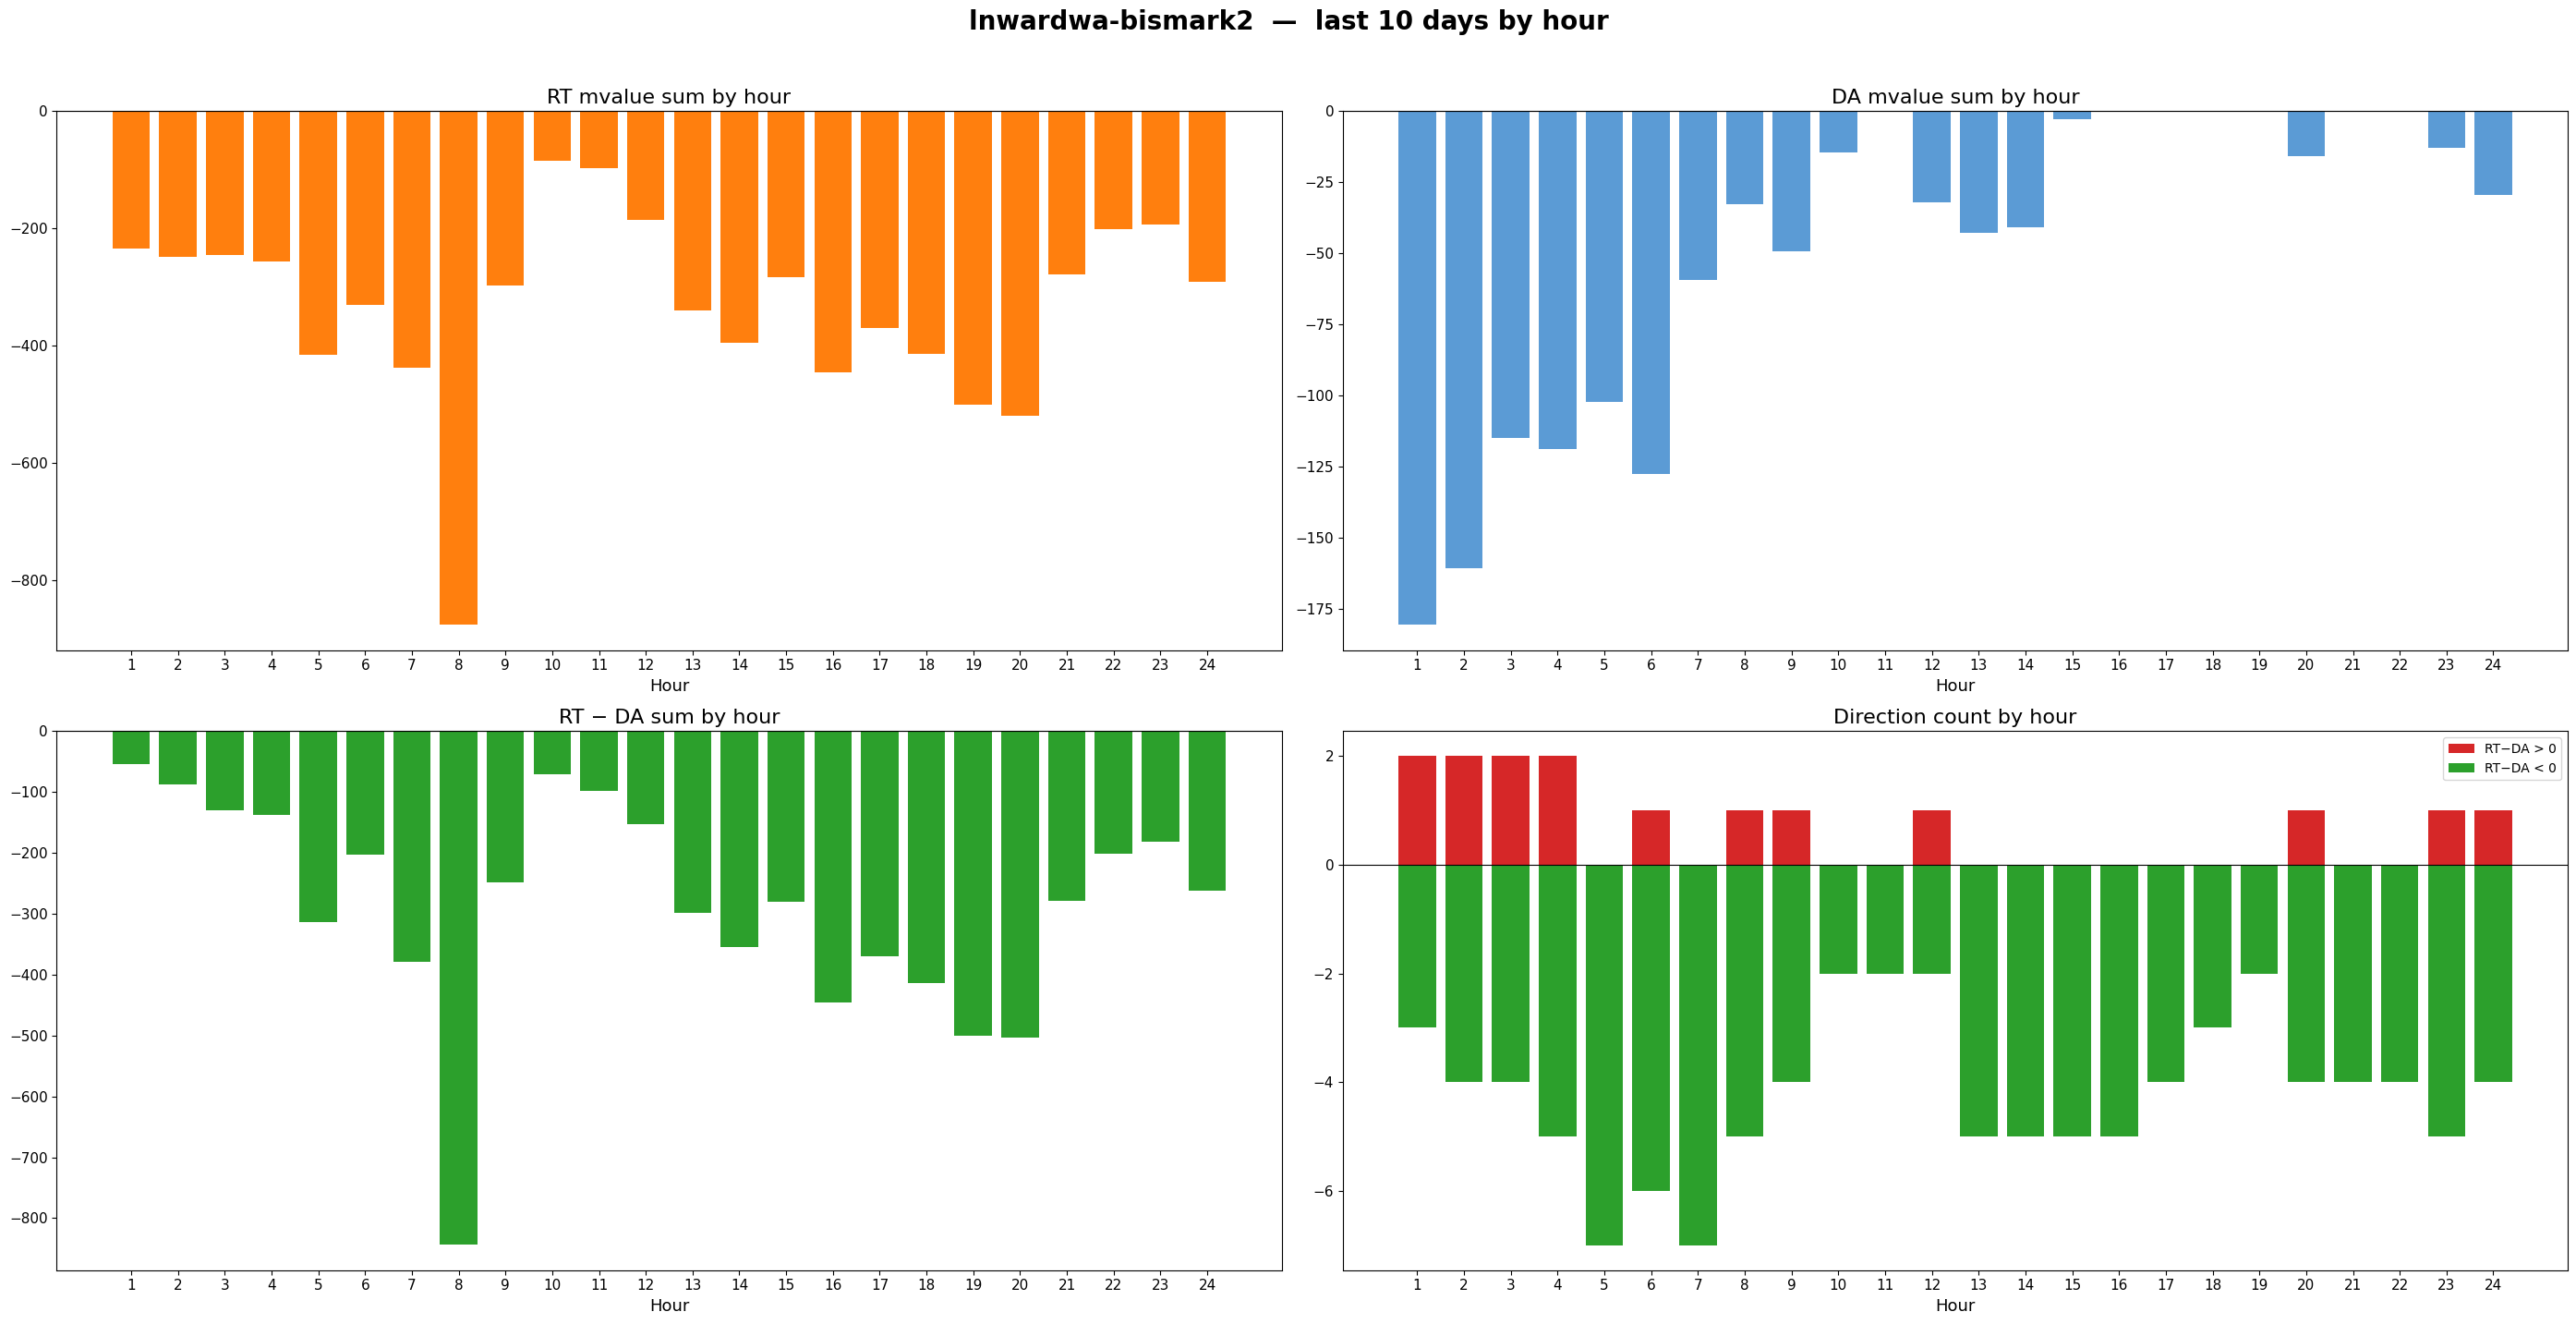


Total rows: 57528

  lnwardwa-bismark2


,node_num,dfax,corr,sign_acc,mean_pred,mean_actual,n
0,1568,0.0504,0.700243,0.632653,4.253480,12.203755,49.0
1,1569,0.0504,0.700243,0.632653,4.253480,12.203755,49.0
2,1669,0.0504,0.700243,0.632653,4.253480,12.203755,49.0
3,915,0.0514,0.697561,0.653061,4.337875,15.636773,49.0
4,863,0.0818,0.336250,0.488693,2.847976,2.329850,796.0
...,...,...,...,...,...,...,...
72,1006,-0.0740,-0.430743,0.510204,-6.245189,9.020133,49.0
73,896,-0.0628,-0.474369,0.571429,-5.299971,8.177170,49.0
74,1020,-0.0511,-0.486398,0.632653,-4.312556,6.382206,49.0
75,634,-0.0501,-0.487562,0.632653,-4.228162,6.530567,49.0


Constraint  : 'lnraun-tekamho'
Reserve zone: 4  |  Columns: ['rz4_spp_res_zonal_wind_forecast_f', 'rz4_spp_res_zonal_load_forecast_f']
Baseline binding rate: 0.0730  |  Total hours: 17496


,monitored,reserve_zone,fundamental,baseline_prob,cond_prob_top95pct,lift_pct
0,lnraun-tekamho,4,rz4_spp_res_zonal_wind_forecast_f,0.073,0.1097,0.50
1,lnraun-tekamho,4,rz4_spp_res_zonal_load_forecast_f,0.073,0.0617,-0.16


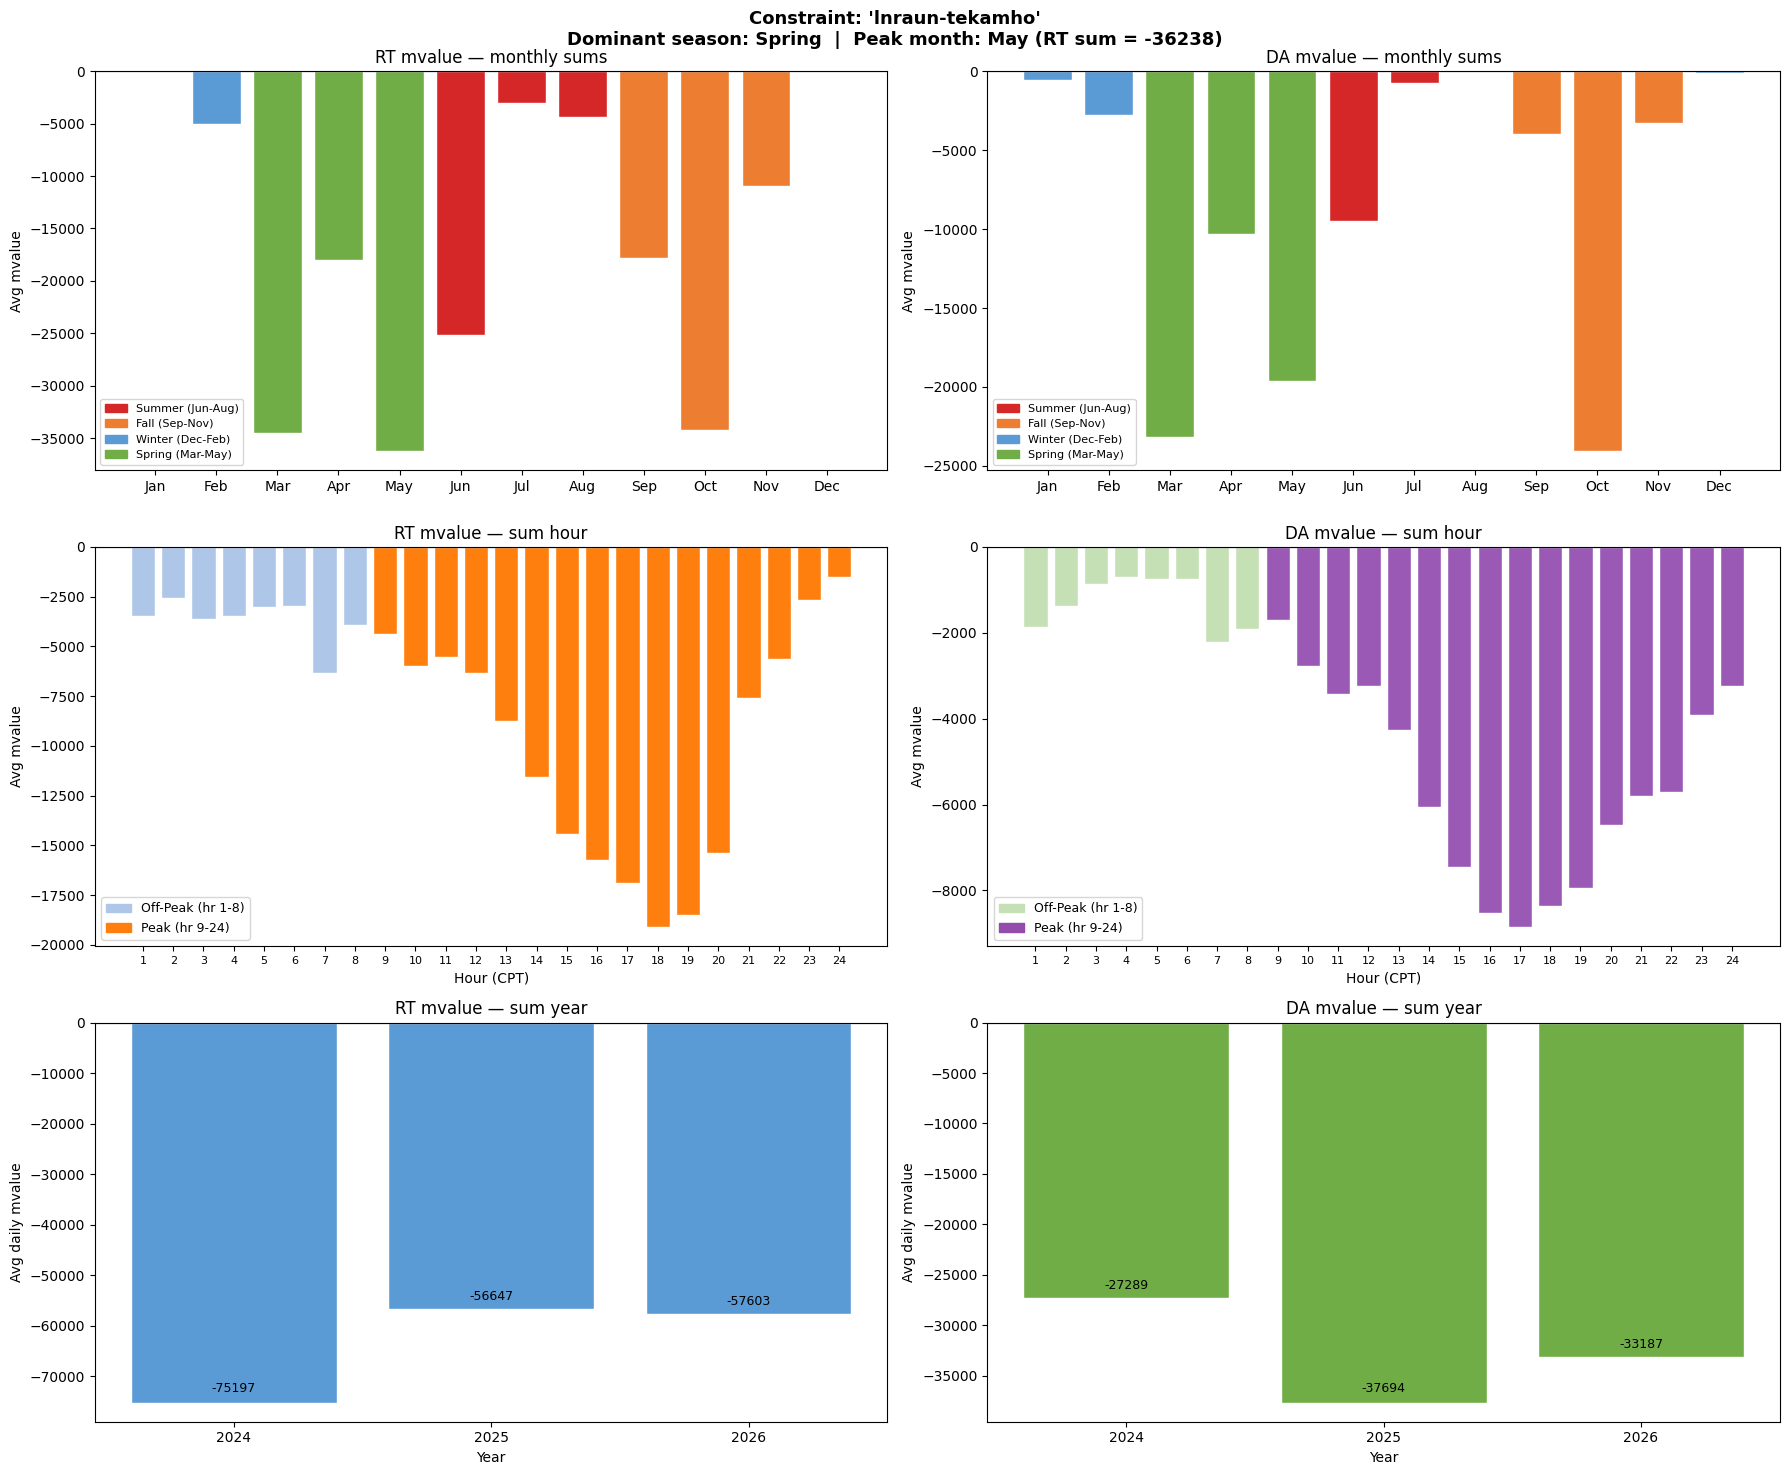

Dominant season : Spring

RT  peak sum   (hr  9-24): -160066.66  |  off-peak (hr 1-8):  -29381.07
DA  peak sum   (hr  9-24):  -87748.21  |  off-peak (hr 1-8):  -10422.52
'lnraun-tekamho'  |  2026-05-18 → 2026-05-28  |  9 days


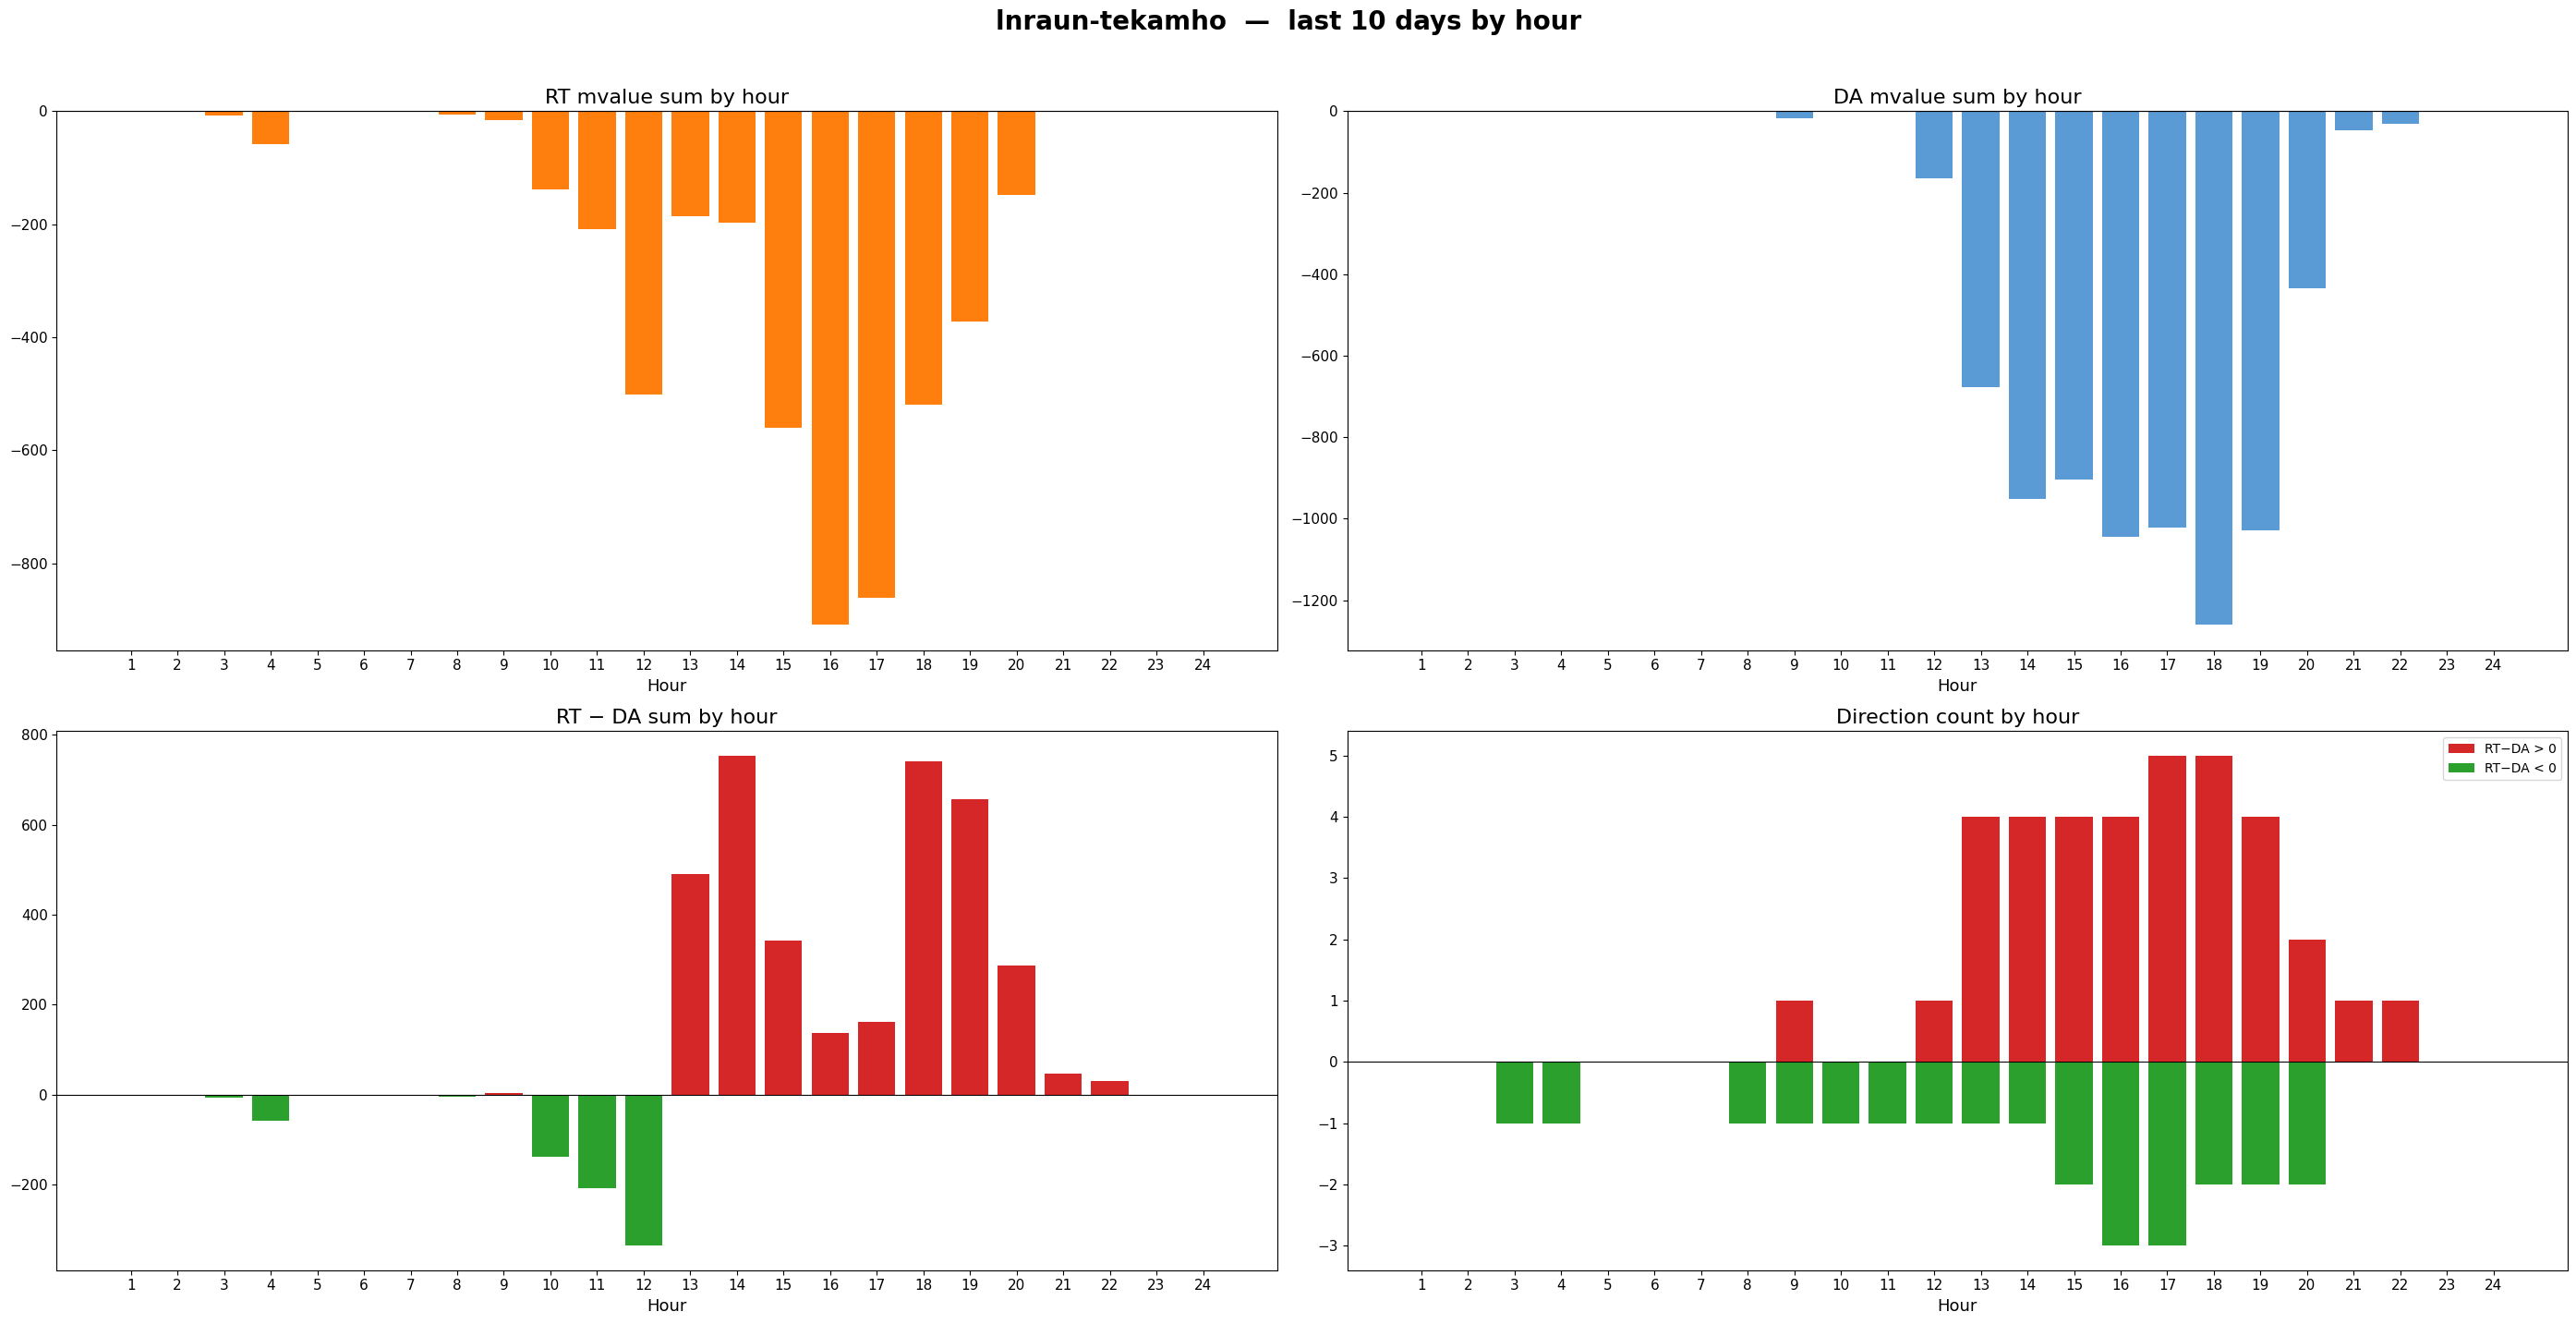


Total rows: 34408

  lnraun-tekamho


,node_num,dfax,corr,sign_acc,mean_pred,mean_actual,n
0,1638,0.1949,0.607675,0.732824,10.896815,3.698226,786.0
1,1639,0.1949,0.577615,0.722646,10.896815,3.906064,786.0
2,1635,0.1371,0.515296,0.713740,7.665230,1.689608,786.0
3,184,0.0882,0.469219,0.670330,6.367310,3.181179,1274.0
4,182,0.0882,0.468236,0.669545,6.367310,3.183241,1274.0
5,183,0.0882,0.468231,0.669545,6.367310,3.181970,1274.0
6,185,0.0882,0.468177,0.670330,6.367310,3.220808,1274.0
7,181,0.0877,0.467806,0.670330,6.331214,3.171574,1274.0
8,890,-0.0823,0.445321,0.736264,-5.941379,-6.170480,1274.0
9,936,-0.0823,0.445321,0.736264,-5.941379,-6.170480,1274.0


Constraint  : 'lngord-maiz'
Reserve zone: 4  |  Columns: ['rz4_spp_res_zonal_wind_forecast_f', 'rz4_spp_res_zonal_load_forecast_f']
Baseline binding rate: 0.0624  |  Total hours: 17496


,monitored,reserve_zone,fundamental,baseline_prob,cond_prob_top95pct,lift_pct
1,lngord-maiz,4,rz4_spp_res_zonal_load_forecast_f,0.0624,0.1394,1.23
0,lngord-maiz,4,rz4_spp_res_zonal_wind_forecast_f,0.0624,0.0491,-0.21


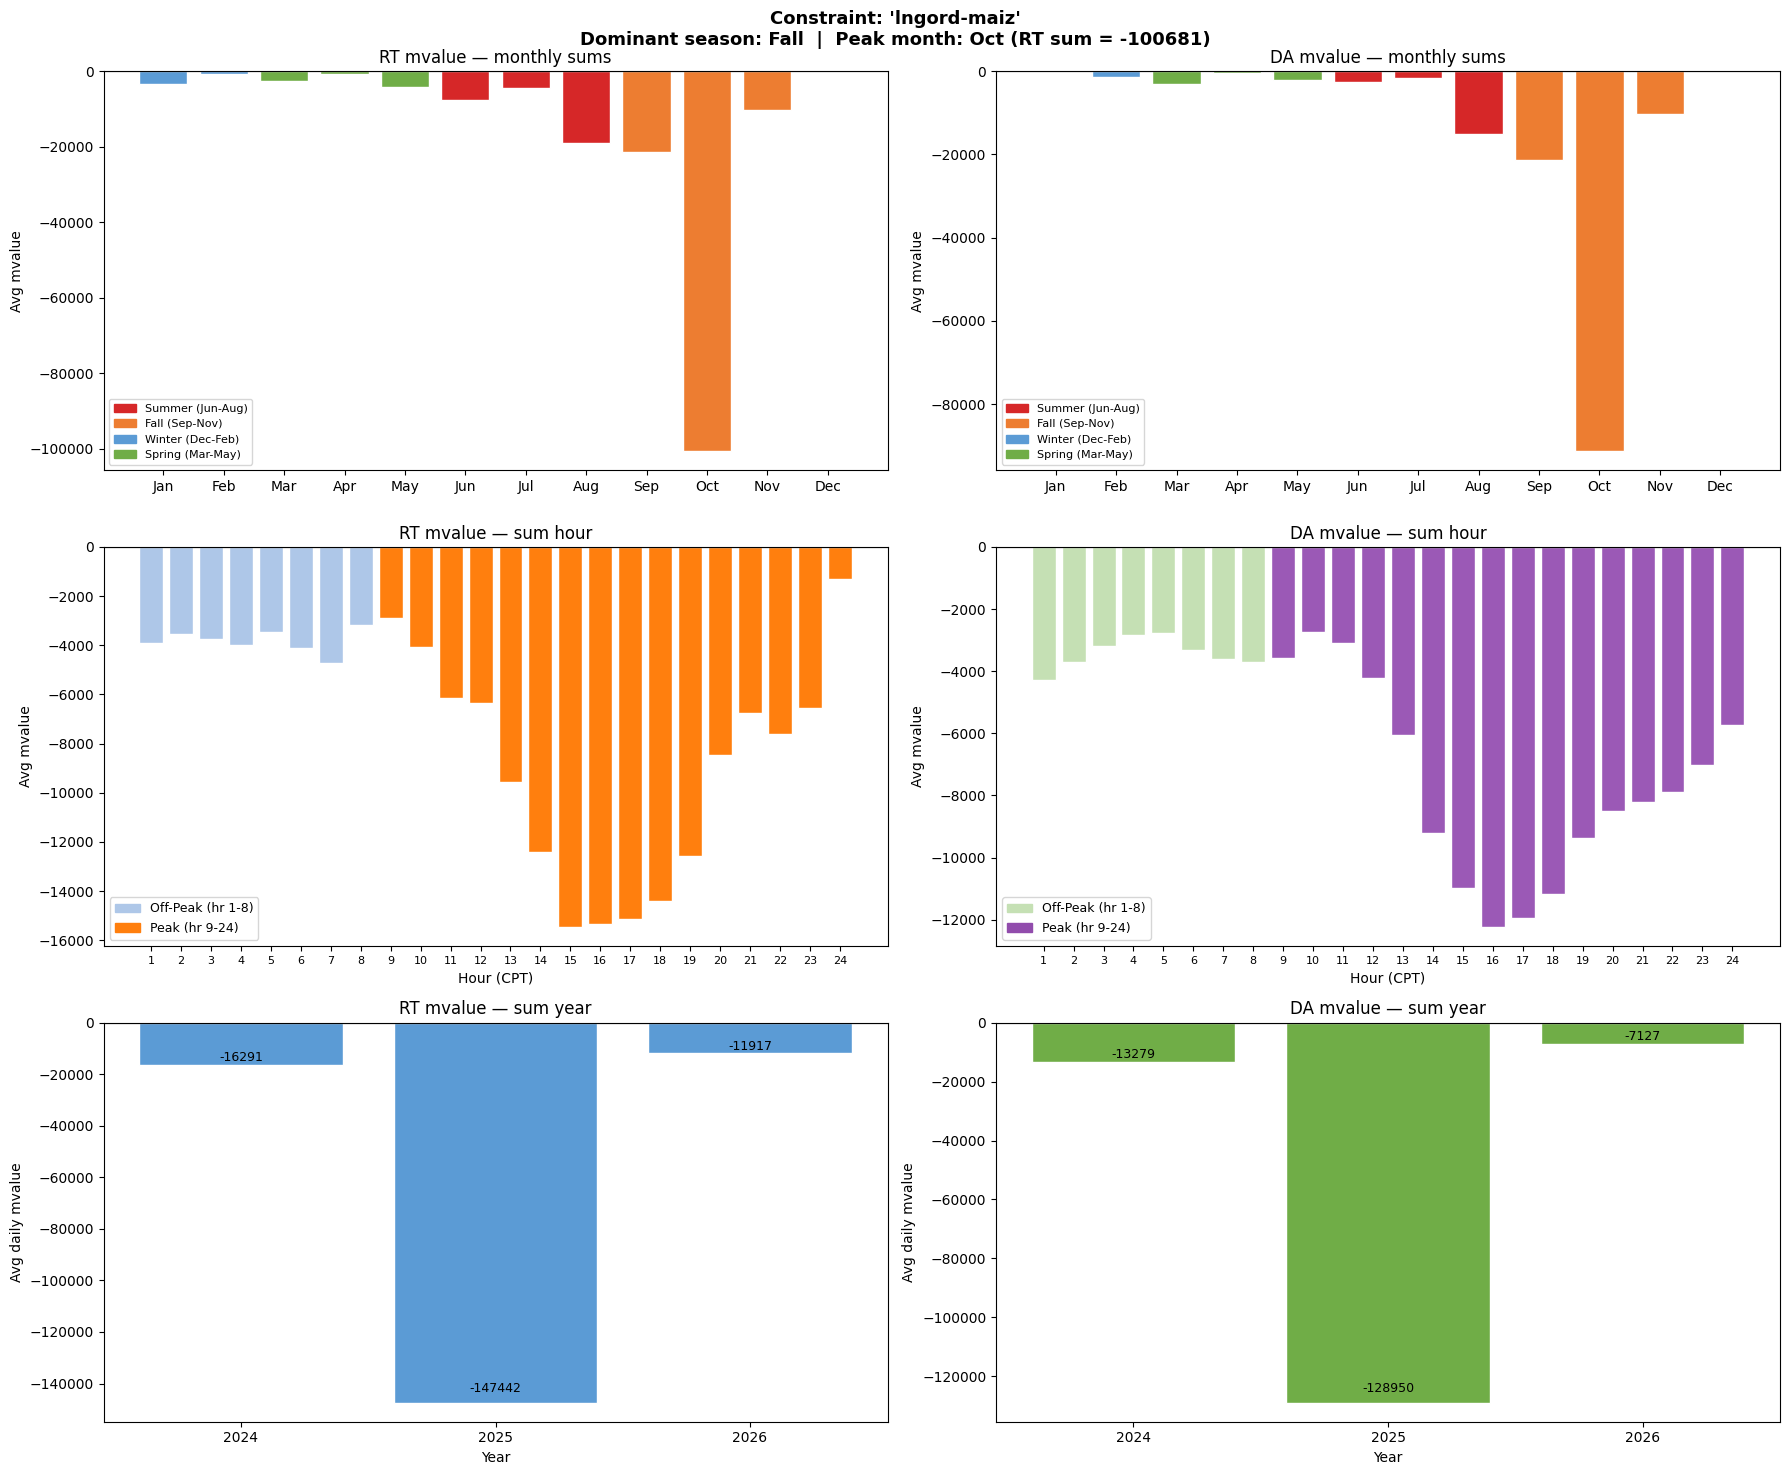

Dominant season : Fall

RT  peak sum   (hr  9-24): -145018.12  |  off-peak (hr 1-8):  -30632.90
DA  peak sum   (hr  9-24): -121919.23  |  off-peak (hr 1-8):  -27436.01
'lngord-maiz'  |  2026-05-18 → 2026-05-28  |  3 days


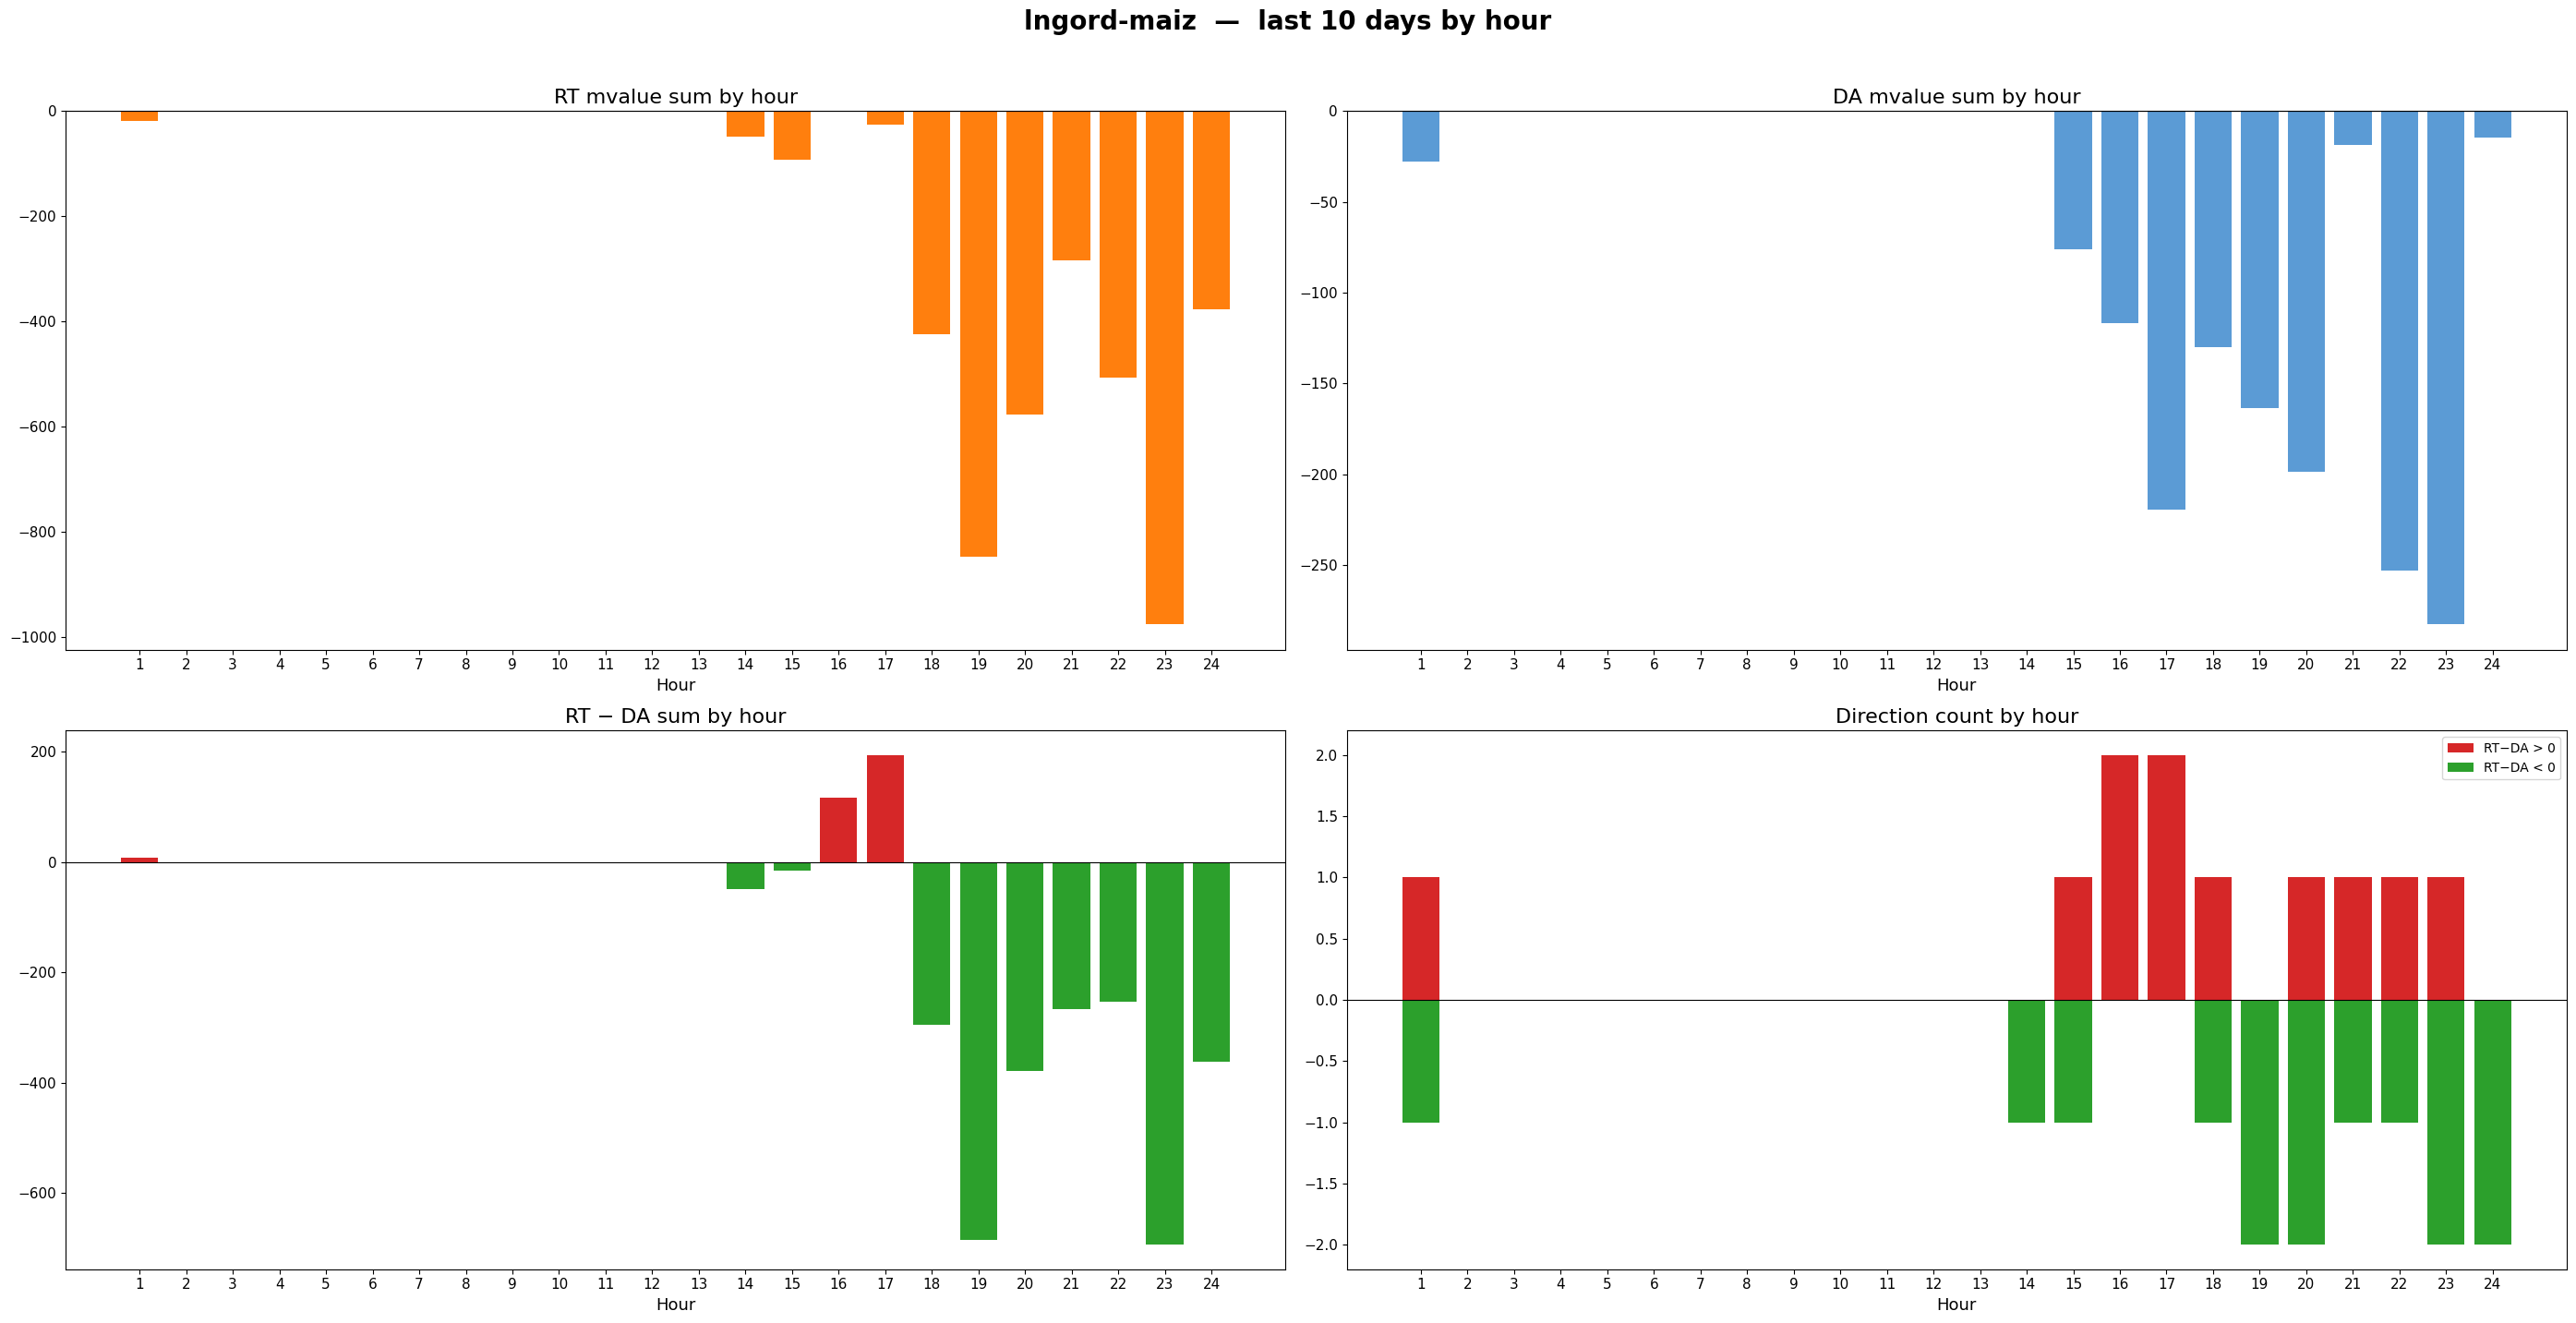


Total rows: 189980

  lngord-maiz


,node_num,dfax,corr,sign_acc,mean_pred,mean_actual,n
0,1504,0.3268,0.980711,0.890995,4.666108,-1.134843,211.0
1,1465,0.1524,0.943935,0.824645,2.175994,-3.974726,211.0
2,1464,0.1667,0.938142,0.838863,2.380172,-3.607415,211.0
3,1502,0.1168,0.914507,0.791469,1.667691,-6.412735,211.0
4,1505,0.0898,0.902196,0.777251,1.282180,-6.100825,211.0
...,...,...,...,...,...,...,...
113,1374,-0.0712,NaN,NaN,NaN,NaN,0.0
114,1376,0.1612,NaN,NaN,NaN,NaN,0.0
115,1377,-0.0991,NaN,NaN,NaN,NaN,0.0
116,1379,0.1533,NaN,NaN,NaN,NaN,0.0


Constraint  : 'xfmrsub975-sub975'
Reserve zone: 4  |  Columns: ['rz4_spp_res_zonal_wind_forecast_f', 'rz4_spp_res_zonal_load_forecast_f']
Baseline binding rate: 0.1276  |  Total hours: 17496


,monitored,reserve_zone,fundamental,baseline_prob,cond_prob_top95pct,lift_pct
1,xfmrsub975-sub975,4,rz4_spp_res_zonal_load_forecast_f,0.1276,0.3851,2.02
0,xfmrsub975-sub975,4,rz4_spp_res_zonal_wind_forecast_f,0.1276,0.0640,-0.50


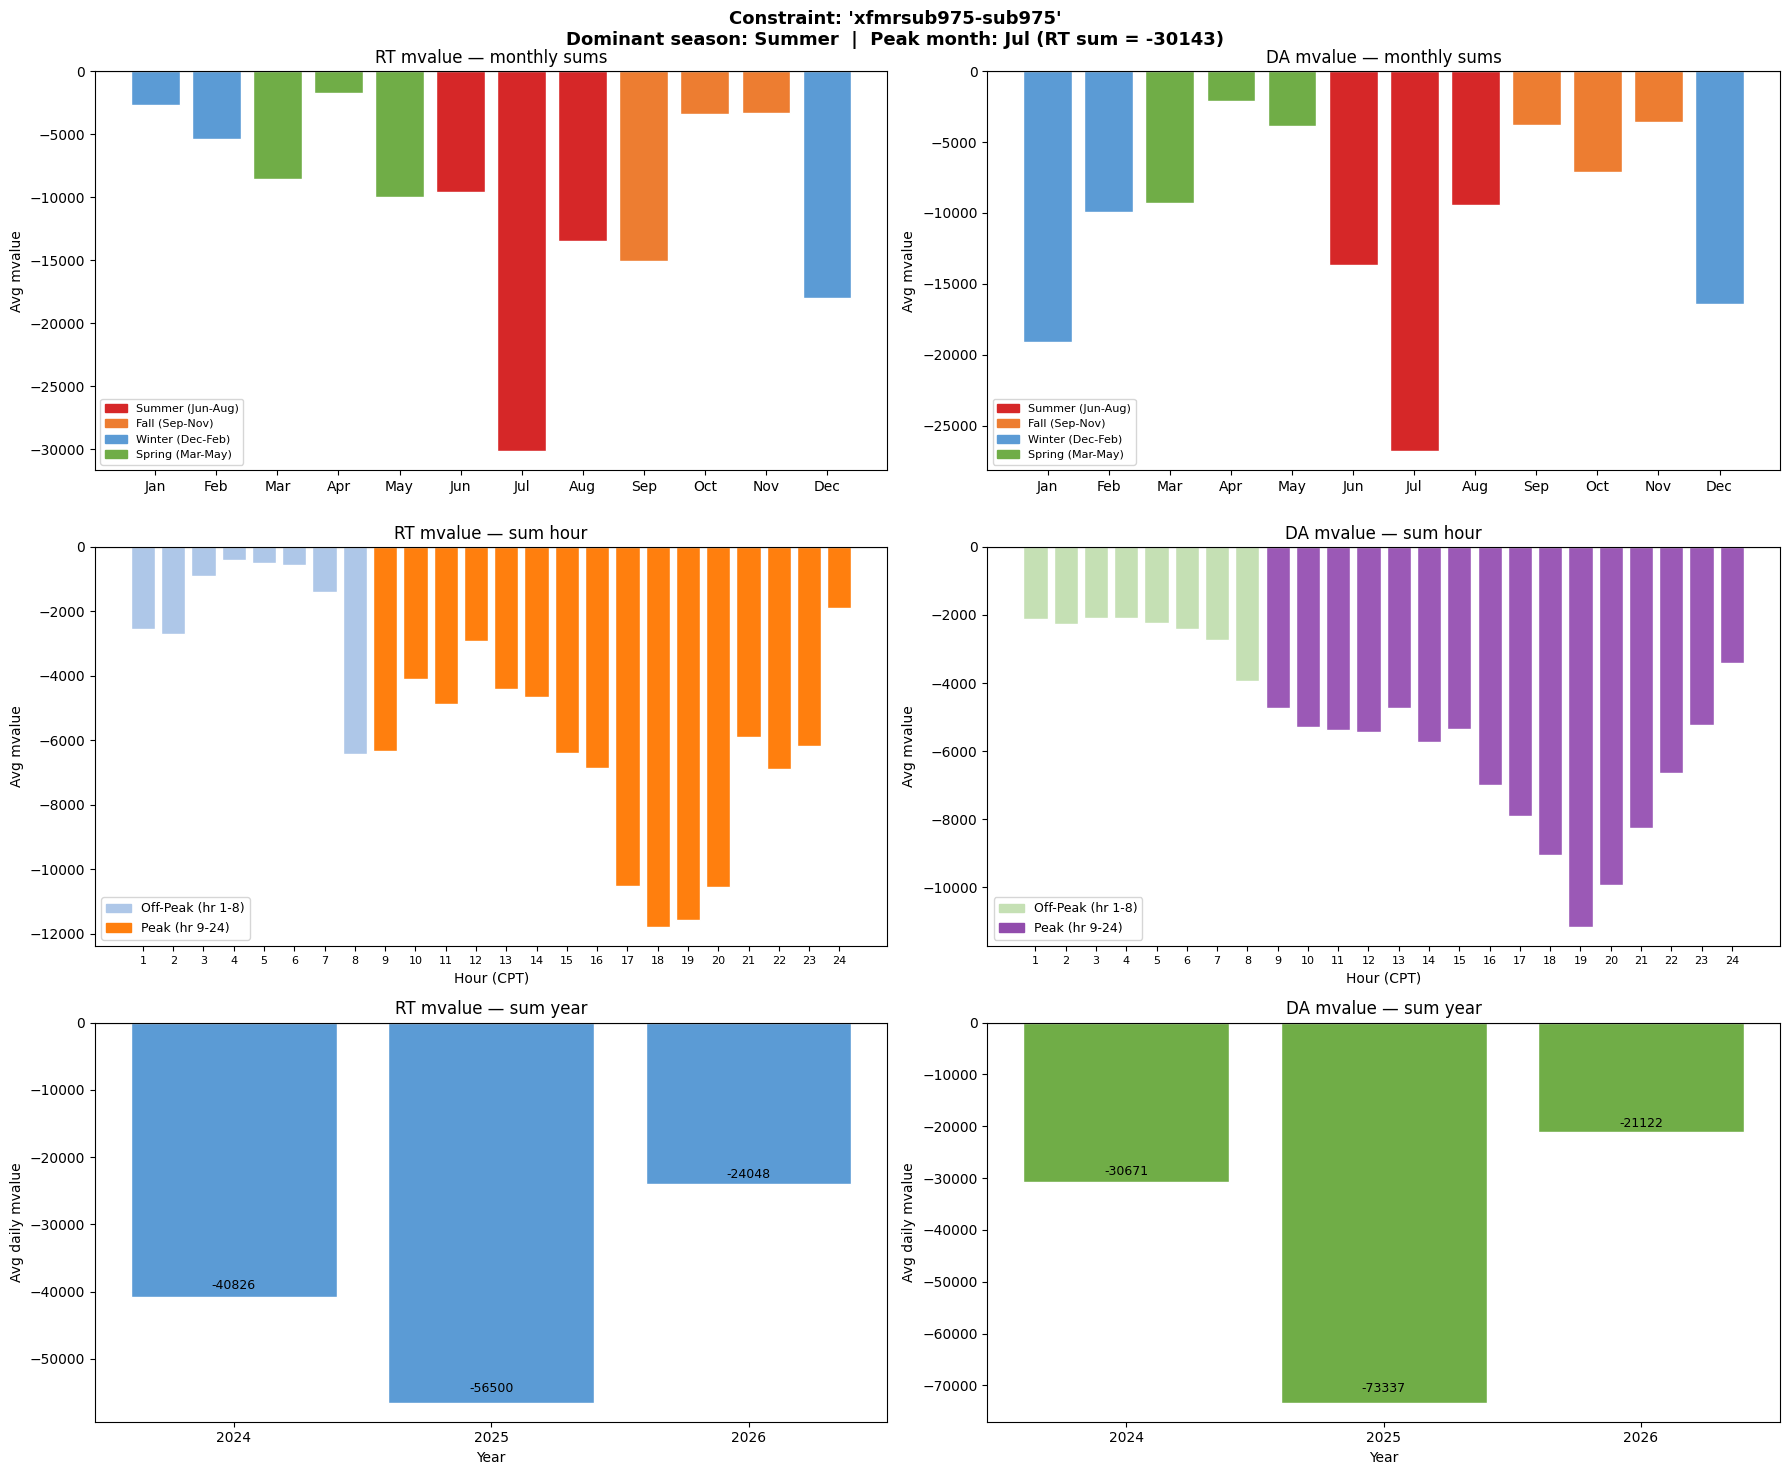

Dominant season : Summer

RT  peak sum   (hr  9-24): -105924.57  |  off-peak (hr 1-8):  -15448.95
DA  peak sum   (hr  9-24): -105230.84  |  off-peak (hr 1-8):  -19899.99
'xfmrsub975-sub975'  |  2026-05-18 → 2026-05-28  |  5 days


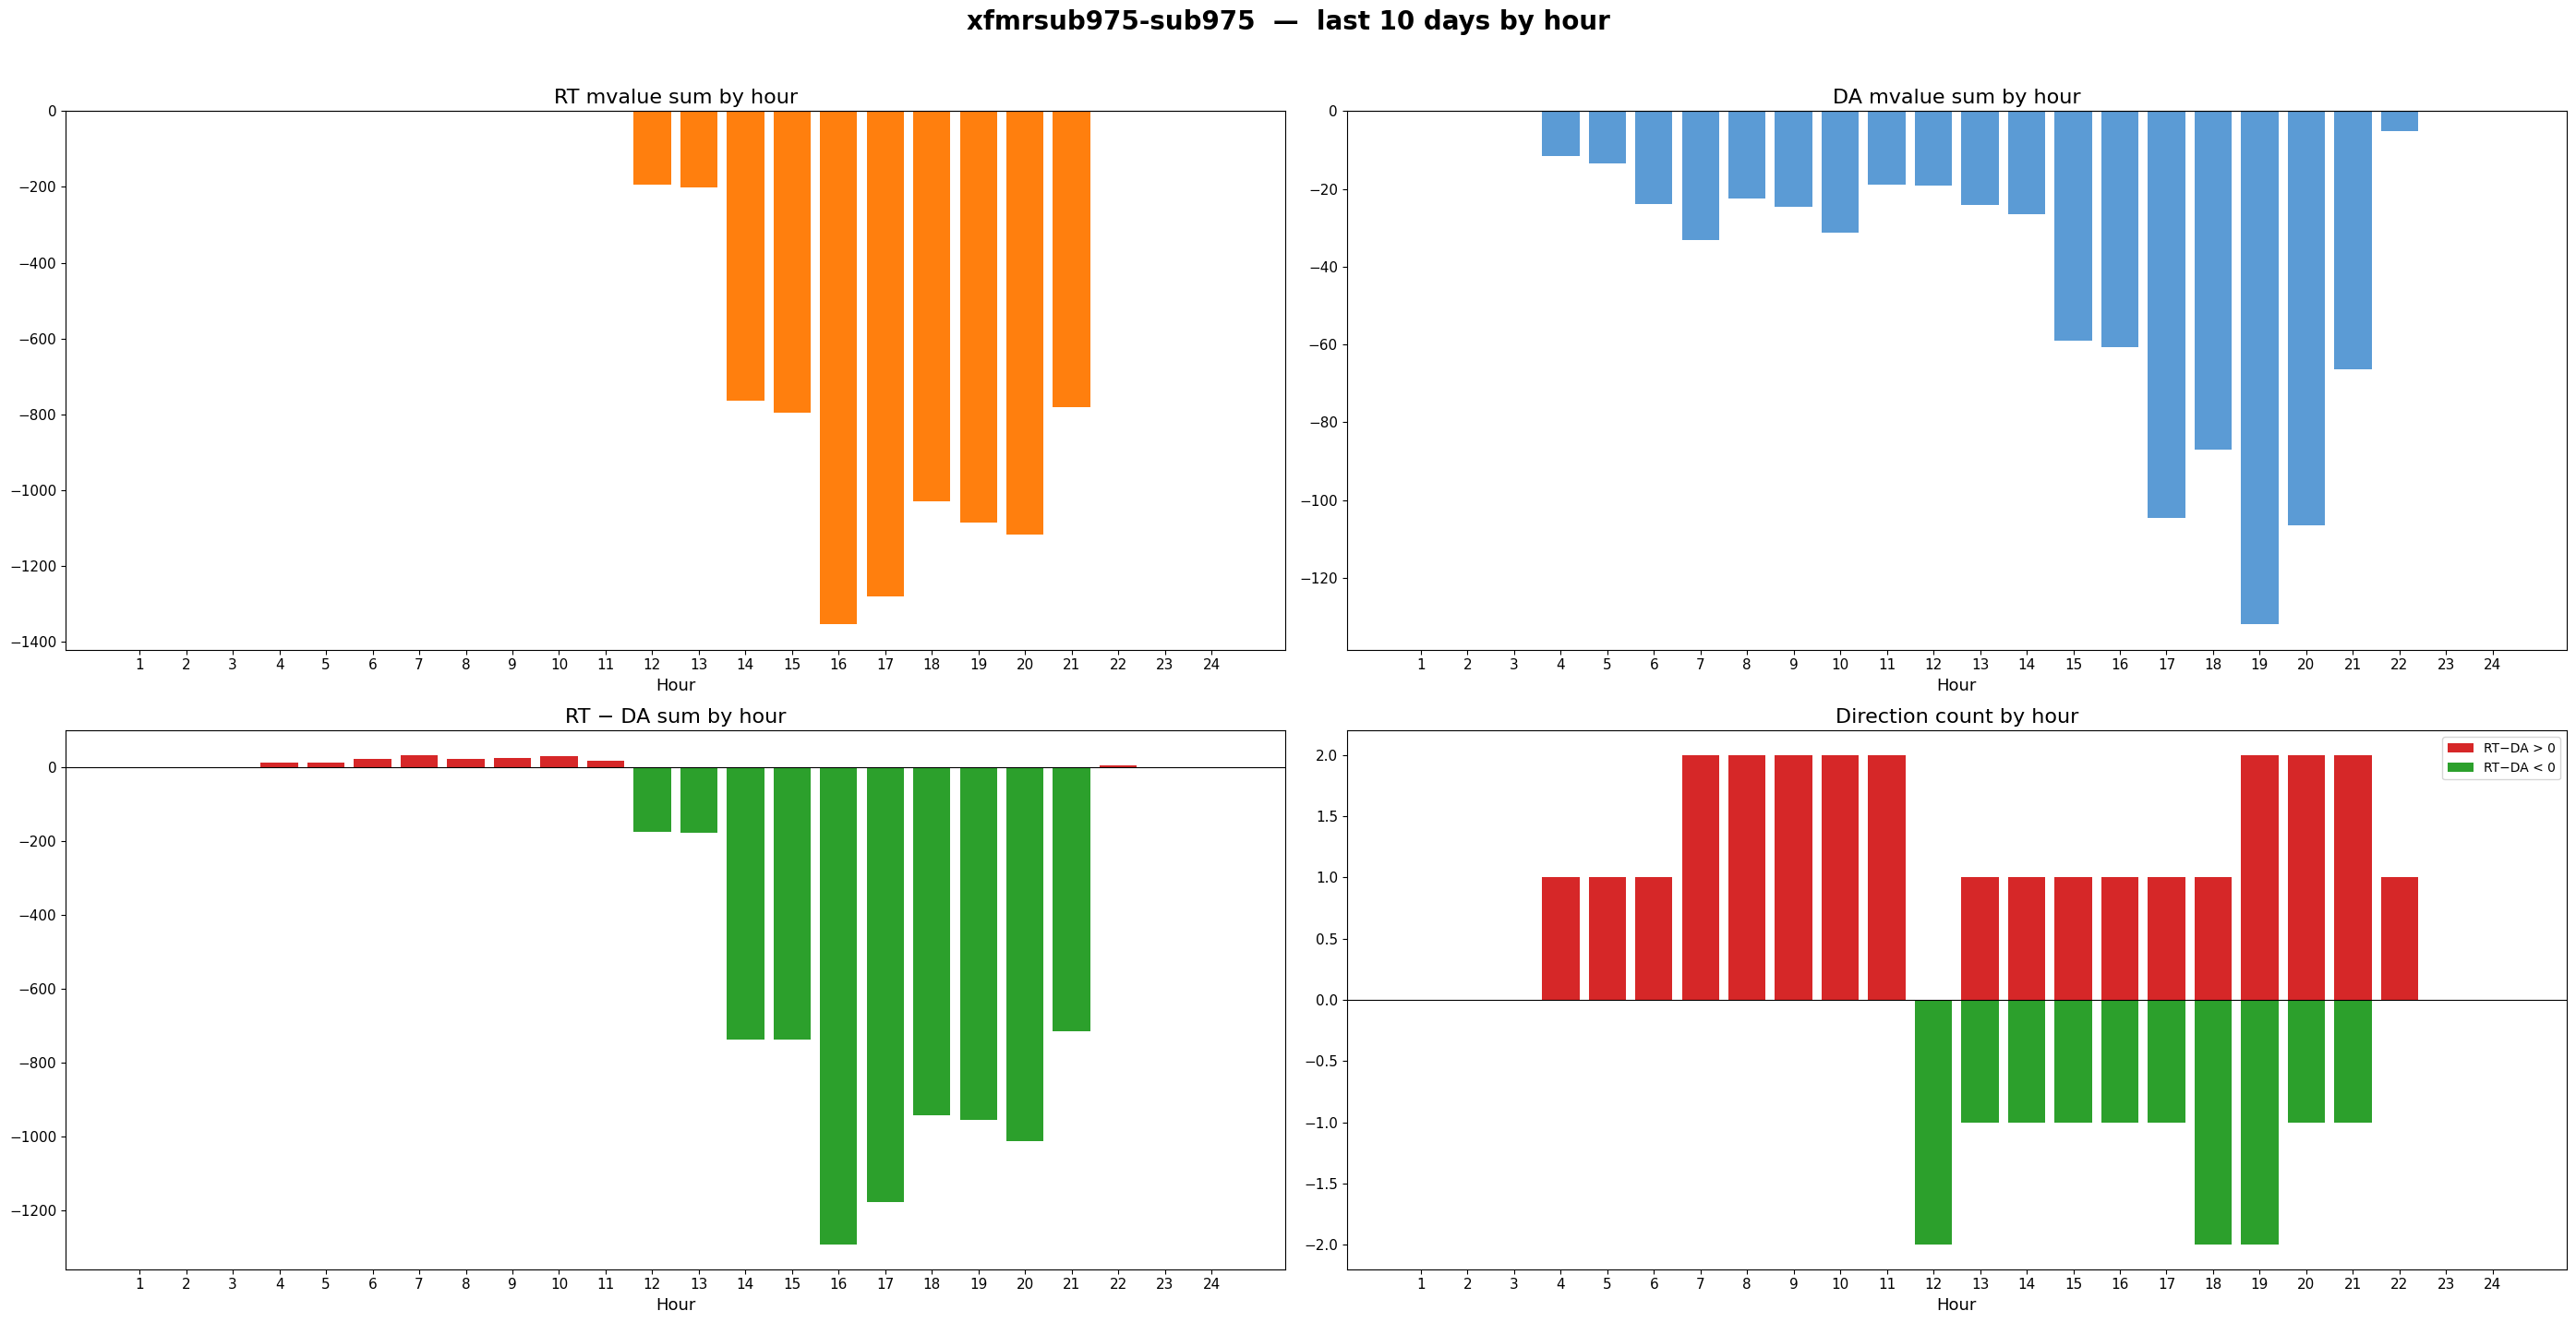


Total rows: 9564

  xfmrsub975-sub975


,node_num,dfax,corr,sign_acc,mean_pred,mean_actual,n
0,349,0.7349,0.913194,0.892328,-1.232981,6.761974,2229.0
1,350,0.2003,0.489913,0.781516,-0.336054,7.388527,2229.0
2,560,0.1463,0.410774,0.772992,-0.245455,8.727100,2229.0
3,172,-0.0682,0.228135,0.470166,0.114423,7.894755,2229.0


Constraint  : 'lnjamestn-valleyc'
Reserve zone: 4  |  Columns: ['rz4_spp_res_zonal_wind_forecast_f', 'rz4_spp_res_zonal_load_forecast_f']
Baseline binding rate: 0.2100  |  Total hours: 17496


,monitored,reserve_zone,fundamental,baseline_prob,cond_prob_top95pct,lift_pct
0,lnjamestn-valleyc,4,rz4_spp_res_zonal_wind_forecast_f,0.21,0.2709,0.29
1,lnjamestn-valleyc,4,rz4_spp_res_zonal_load_forecast_f,0.21,0.1531,-0.27


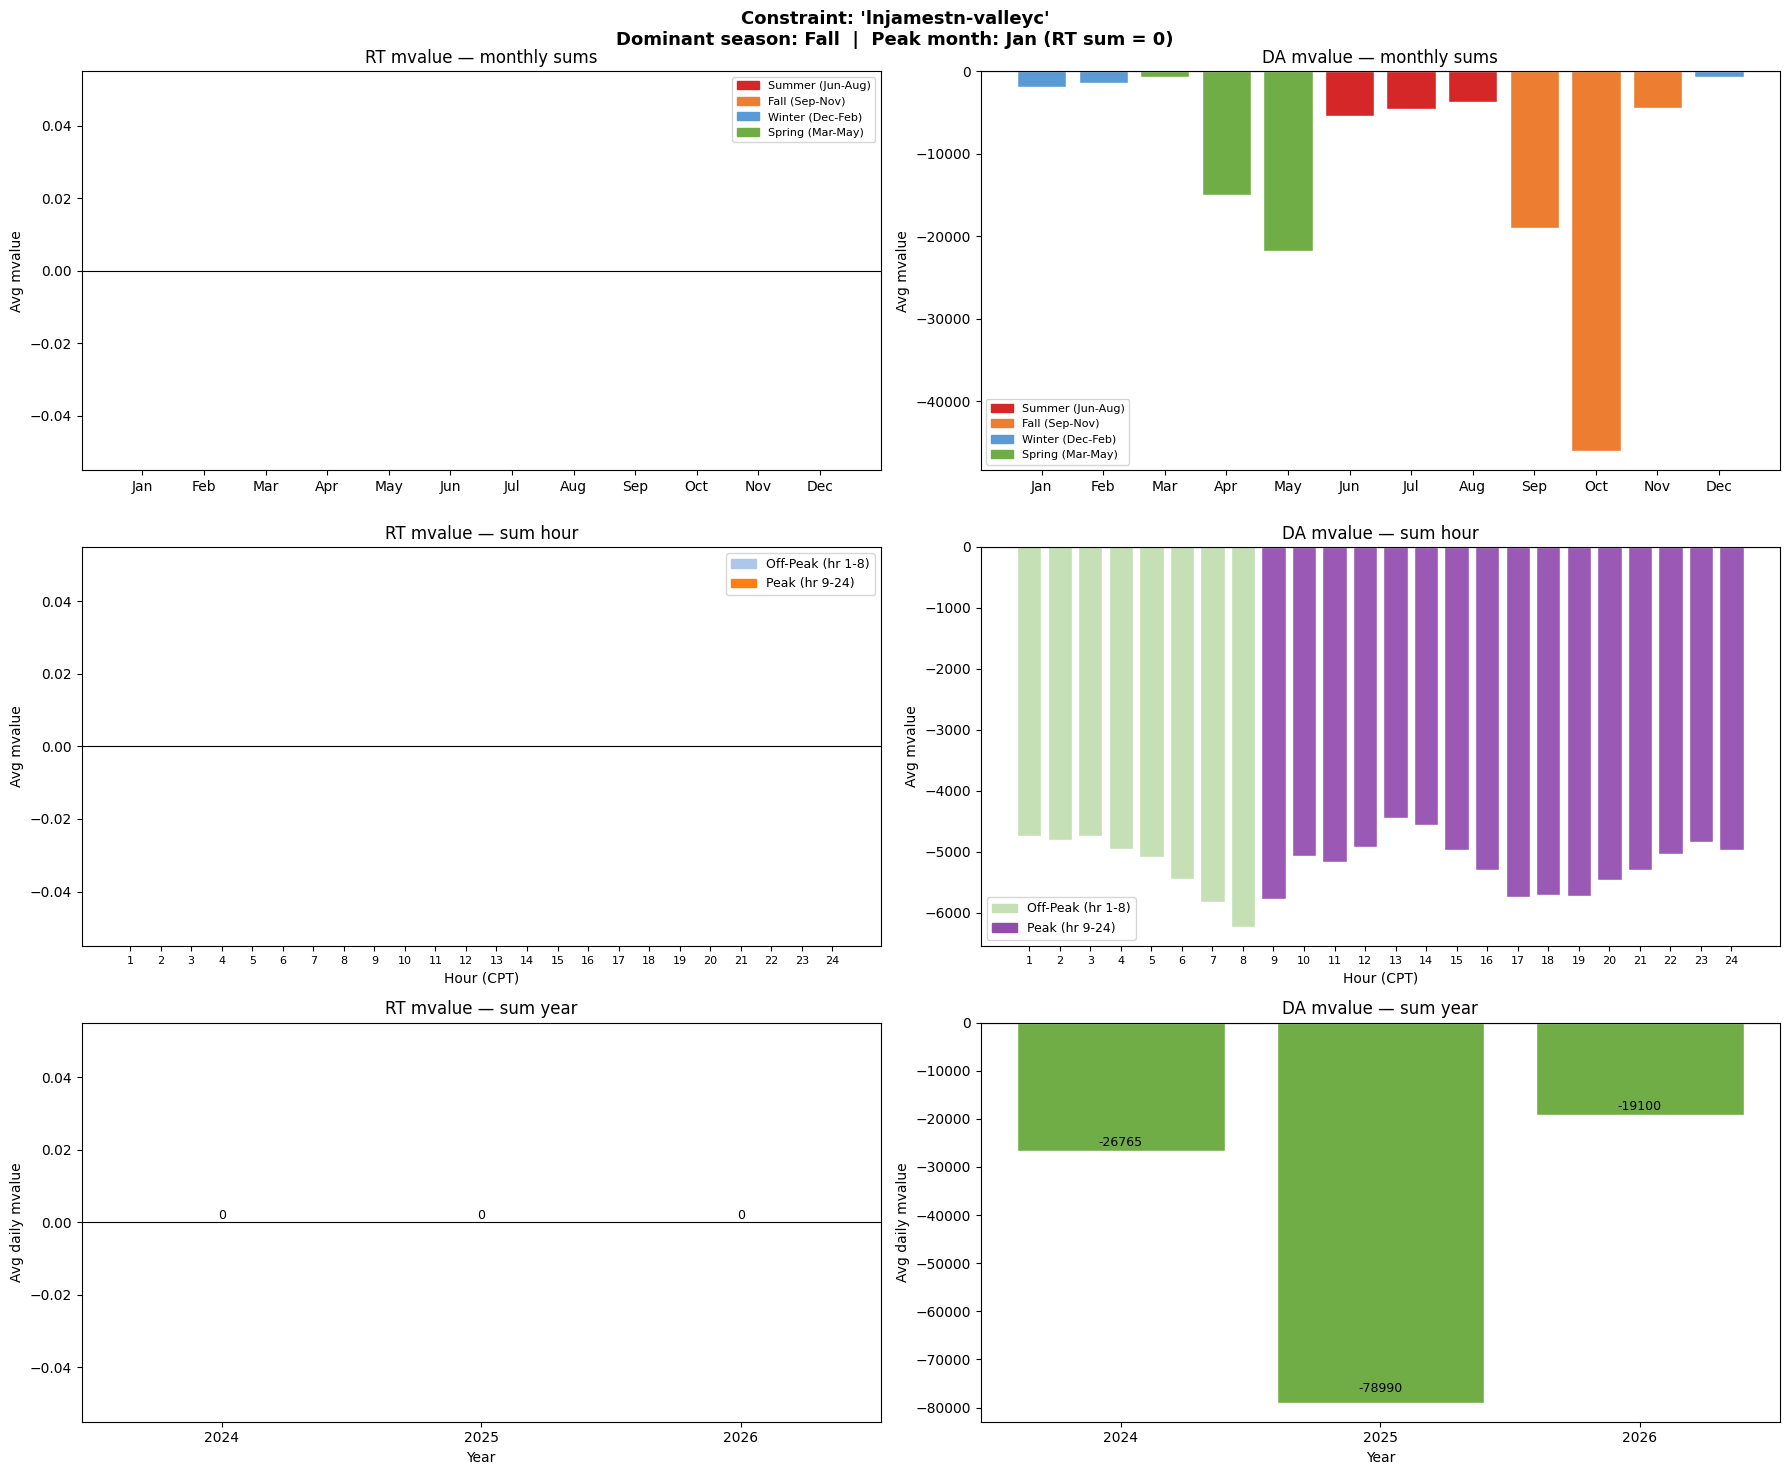

Dominant season : Fall

RT  peak sum   (hr  9-24):       0.00  |  off-peak (hr 1-8):       0.00
DA  peak sum   (hr  9-24):  -83020.13  |  off-peak (hr 1-8):  -41834.91
'lnjamestn-valleyc'  |  2026-05-18 → 2026-05-28  |  11 days


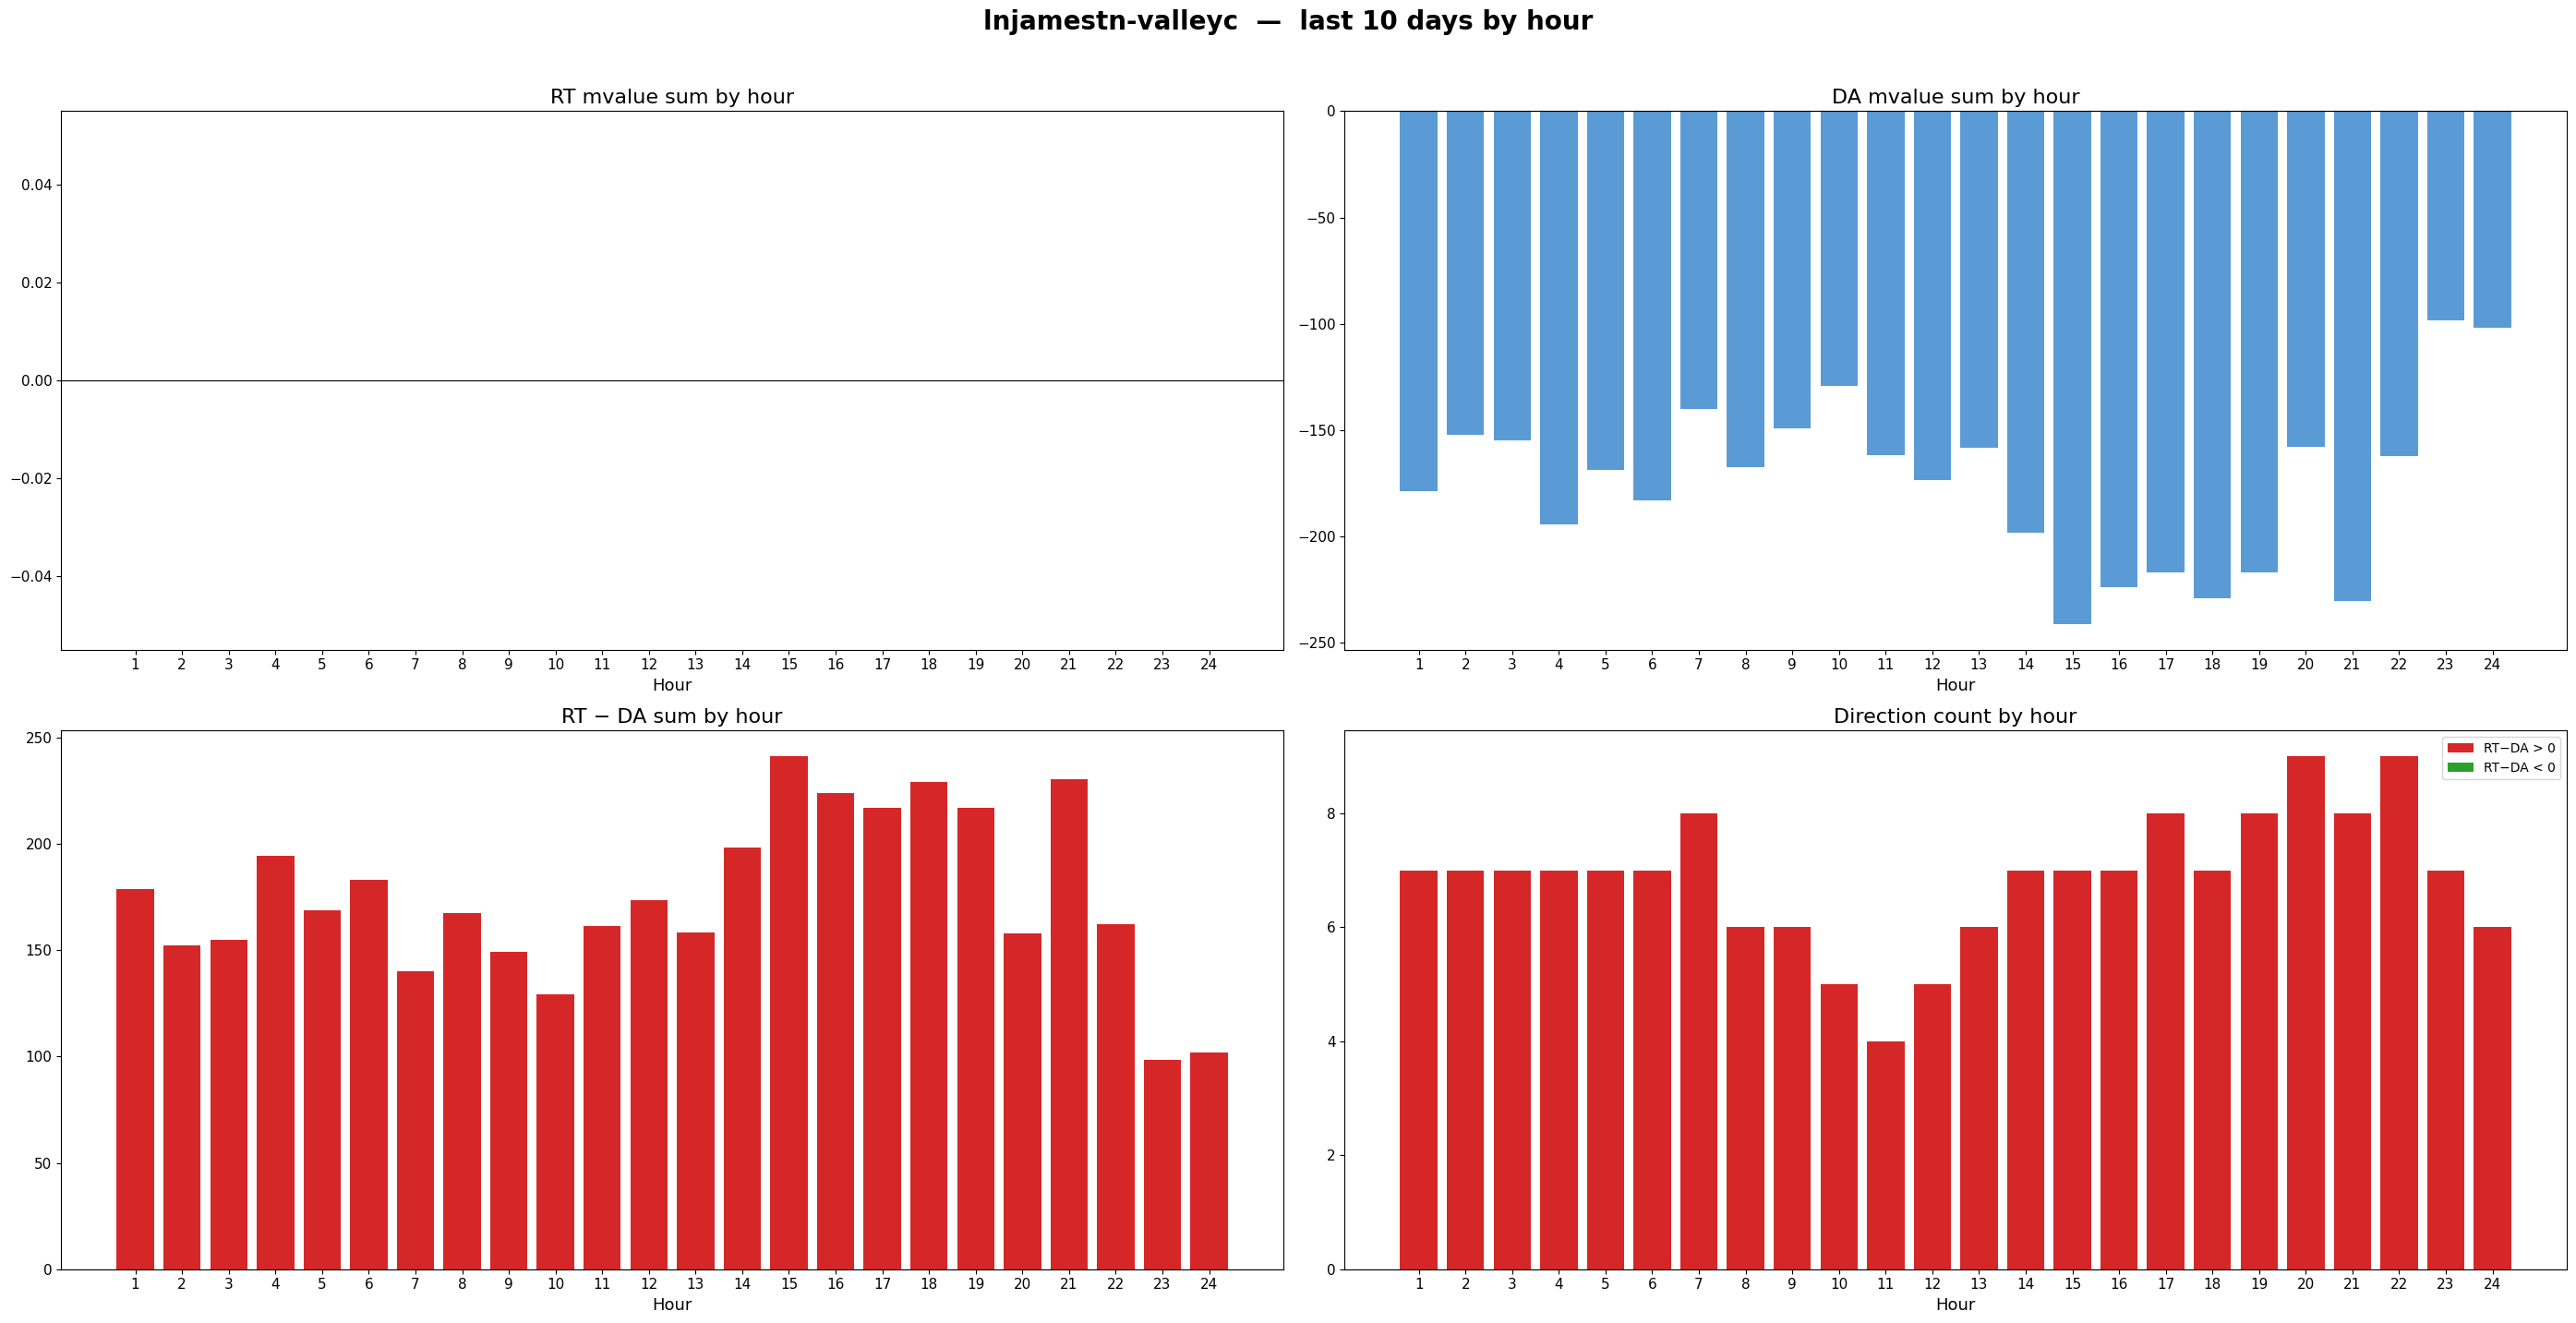

lnjamestn-valleyc could not find the dfax value


In [13]:
from IPython.display import display, HTML

row_counts = hourly_mvalue.groupby('monitored').size().sort_values()
print(row_counts.to_string())

for name in row_counts.index:
    display(HTML(f'''
    <hr style="border: 3px solid black; margin: 30px 0;">
    <h1 style="background:#2c3e50; color:white; padding:12px 20px; border-radius:6px; font-family:monospace;">
        {name} &nbsp;<span style="font-size:0.6em; color:#aaa;">({row_counts[name]:,} rows)</span>
    </h1>
    <hr style="border: 1px solid #aaa; margin-bottom: 20px;">
    '''))

    analyze_constraint_by_zone(fundamentals, hourly_mvalue, name, 4, 95)
    plot_constraint_seasonality(hourly_mvalue, name)
    plot_recent_hourly_distribution(hourly_mvalue, name, bid_dt, days=10)
    table = get_constraints_node_price(hourly_mvalue, dfax, [name])
    get_metrics_for_nodes(table)

In [12]:
import json

zone_map_path = '/var/www/python/Qingcheng/QCTest/Manual_bidding/zone_map.json'
with open(zone_map_path) as f:
    zone_map = json.load(f)
print(hourly_mvalue.monitored.unique())

['lnwardwa-bismark2' 'lnjamestn-valleyc' 'lngord-maiz' 'lnlenexa-shwnmsn5'
 'lnraun-tekamho' 'lnnebrcty-sub3456' 'xfmrsub975-sub975'
 'lnfirstcrk-roanrdge' 'lnjarb-166thstr' 'lnpayne_wf-paoli2' 'lnwemp-vaug'
 'lnrugby230-rugby' 'xfmrsiouxcy-siouxcy' 'lnanta_tp-anita'
 'lnmanfl7-clec_pel' 'lneeur-vaug_rev23' 'lnmidj-pent' 'lnhuron-carpntrw'
 'xfmrtech-tech']


Constraint  : 'lnlenexa-shwnmsn5'
Reserve zone: 4  |  Columns: ['rz4_spp_res_zonal_wind_forecast_f', 'rz4_spp_res_zonal_load_forecast_f']
Baseline binding rate: 0.0065  |  Total hours: 17472


,monitored,reserve_zone,fundamental,baseline_prob,cond_prob_top90pct,lift_pct
0,lnlenexa-shwnmsn5,4,rz4_spp_res_zonal_wind_forecast_f,0.0065,0.0149,1.30
1,lnlenexa-shwnmsn5,4,rz4_spp_res_zonal_load_forecast_f,0.0065,0.0040,-0.38


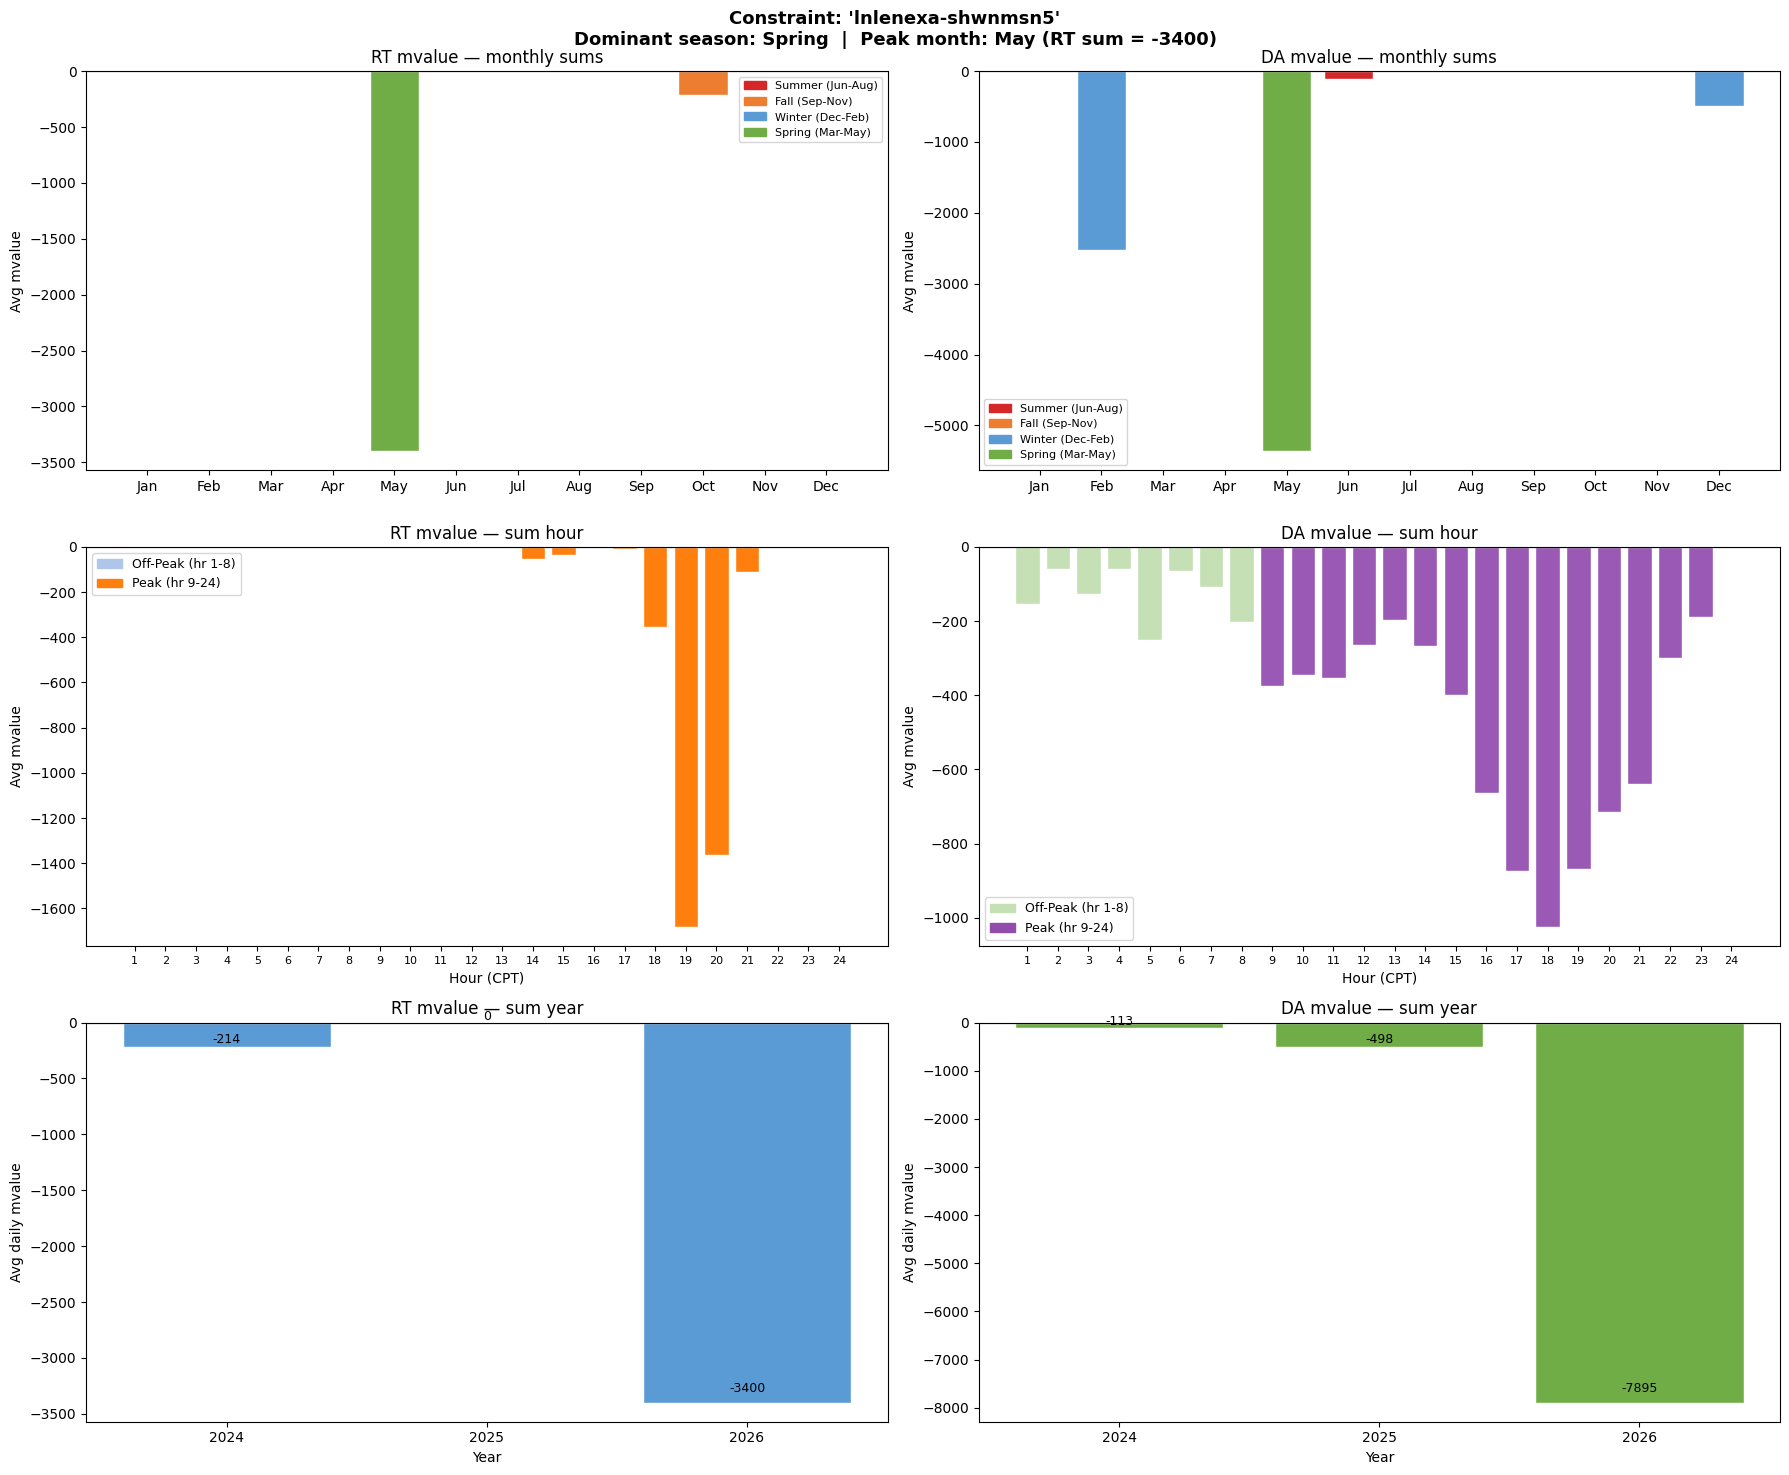

Dominant season : Spring
  Spring  :       3400  (sum abs RT daily mvalue)
  Fall    :        214  (sum abs RT daily mvalue)
  Summer  :          0  (sum abs RT daily mvalue)
  Winter  :          0  (sum abs RT daily mvalue)

Peak month      : May  (daily RT sum = -3400.37)

RT  peak sum   (hr  9-24):   -3614.24  |  off-peak (hr 1-8):       0.00
DA  peak sum   (hr  9-24):   -7473.78  |  off-peak (hr 1-8):   -1031.59

Total rows: 4692

  lnlenexa-shwnmsn5


,node_num,dfax,corr,sign_acc,mean_pred,mean_actual,n
0,228,0.2977,0.498758,0.714286,-15.400245,-10.300232,98.0
1,230,0.2977,0.498742,0.714286,-15.400245,-10.299748,98.0
2,237,0.2962,0.497866,0.704082,-15.322649,-9.822327,98.0
3,233,0.2970,0.497622,0.704082,-15.364033,-9.996307,98.0
4,232,0.2969,0.496081,0.704082,-15.358860,-9.689310,98.0
5,263,0.1595,0.326030,0.591837,-8.251055,0.359970,98.0
6,262,0.1595,0.326027,0.591837,-8.251055,0.360075,98.0
7,264,0.1595,0.325917,0.591837,-8.251055,0.363670,98.0
8,265,0.1595,0.325917,0.591837,-8.251055,0.363670,98.0
9,266,0.1595,0.325903,0.591837,-8.251055,0.362748,98.0


In [ ]:
name = 'lnlenexa-shwnmsn5'
zone = zone_map.get(name)
if zone is None:
    print(f"  No zone mapped — skipping. Add '{name}' to zone_map.json to include.")
zone= 4
analyze_constraint_by_zone(fundamentals, hourly_mvalue, name, zone, 90)
plot_constraint_seasonality(hourly_mvalue, name)
table = get_constraints_node_price(hourly_mvalue, dfax, [name])
get_metrics_for_nodes(table)

In [31]:
tomorrow_pct = predict_tomorrow_percentile(fundamentals, bid_dt)


--- Zone 1 ---


,hr,wind_value,wind_pct,load_value,load_pct
0,1,768.1,32.7,4050.9,42.8
1,2,782.9,33.4,3948.0,36.6
2,3,810.7,34.5,3875.8,31.7
3,4,847.9,36.0,3880.2,32.0
4,5,921.6,39.0,4006.2,40.2
5,6,1030.8,43.4,4073.6,44.2
6,7,1099.9,46.0,4220.7,53.6
7,8,1139.0,47.5,4427.8,64.5
8,9,1224.5,50.6,4508.4,67.7
9,10,1272.0,52.3,4603.6,71.4



--- Zone 2 ---


,hr,wind_value,wind_pct,load_value,load_pct
0,1,1307.9,19.9,666.3,29.8
1,2,1294.6,19.6,656.7,25.6
2,3,1191.2,17.9,652.3,23.4
3,4,1062.7,15.3,639.8,17.1
4,5,974.2,13.5,639.1,16.9
5,6,870.4,11.5,664.3,28.9
6,7,759.6,9.3,704.1,50.3
7,8,746.0,9.0,733.0,66.9
8,9,782.9,9.7,749.9,73.6
9,10,895.0,12.0,757.1,75.4



--- Zone 3 ---


...

,hr,wind_value,wind_pct,load_value,load_pct
0,1,4085.9,27.8,17912.0,27.5
1,2,3874.7,26.2,17258.0,19.9
2,3,3648.3,24.2,16794.8,15.5
3,4,3409.2,22.0,16639.3,14.1
4,5,3169.0,20.0,16740.2,14.9
5,6,2929.2,17.8,17353.3,20.8
6,7,2712.9,16.1,18098.4,30.1
7,8,2394.5,13.3,18914.8,42.4
8,9,2028.6,10.3,19682.0,52.6
9,10,1925.2,9.4,20480.2,60.6



--- Zone 5 ---


,hr,wind_value,wind_pct,load_value,load_pct
0,1,2574.9,78.3,3672.3,17.6
1,2,2471.7,75.2,3605.7,13.6
2,3,2434.1,74.0,3560.3,10.9
3,4,2371.0,72.1,3498.3,7.6
4,5,2279.8,69.0,3554.6,10.5
5,6,2274.0,68.9,3593.1,12.9
6,7,2320.2,70.3,3706.6,20.0
7,8,2359.5,71.7,3880.1,35.3
8,9,2400.9,73.1,3930.3,41.2
9,10,2533.2,77.1,4024.2,51.6



--- Zone 21 ---


,hr,wind_value,wind_pct,load_value,load_pct
0,1,673.6,73.9,2743.5,45.5
1,2,618.4,68.4,2599.8,25.4
2,3,563.4,61.4,2507.6,12.1
3,4,502.6,51.8,2457.0,5.8
4,5,450.6,44.6,2423.5,3.2
5,6,426.2,41.5,2438.9,3.9
6,7,420.3,40.5,2500.9,11.1
7,8,414.6,39.7,2593.5,24.3
8,9,409.9,39.0,2676.5,35.2
9,10,338.0,29.0,2763.3,49.4


In [ ]:
def predict_tomorrow_binding(fundamentals, mv_merged, monitored_name, zone, bid_dt):
    tmr = fundamentals[fundamentals['dt'] == bid_dt].copy()
    if tmr.empty:
        print(f"No forecast data for {bid_dt} in fundamentals — check bid_dt")
        return pd.DataFrame()

    grp = mv_merged[mv_merged['monitored'] == monitored_name]
    if grp.empty:
        print(f"No data for monitored='{monitored_name}'")
        return pd.DataFrame()

    binding_hours = grp[grp['rt_da'] != 0][['dt', 'hr']].drop_duplicates().copy()
    binding_hours['binding'] = 1

    all_dates = pd.date_range(start=mv_merged['dt'].min(), end=mv_merged['dt'].max(), freq='D')
    full_grid = pd.DataFrame([
        {'dt': d.strftime('%Y-%m-%d'), 'hr': h}
        for d in all_dates for h in range(1, 25)
    ])
    tmp = (full_grid
           .merge(fundamentals, on=['dt', 'hr'], how='left')
           .merge(binding_hours, on=['dt', 'hr'], how='left'))
    tmp['binding'] = tmp['binding'].fillna(0)
    baseline = tmp['binding'].mean()

    rz_cols = [c for c in tmp.columns if c.startswith(f'rz{zone}_') and 'forecast' in c]

    rows = []
    for col in rz_cols:
        hist = tmp[col].dropna()
        if len(hist) < 20:
            continue
        for _, row in tmr.iterrows():
            tmr_val = row.get(col)
            if pd.isna(tmr_val):
                continue
            pct = (hist < tmr_val).mean() * 100
            threshold = hist.quantile(pct / 100)
            above = tmp[tmp[col] > threshold]
            cond_prob = above['binding'].mean() if len(above) >= 5 else None
            rows.append({
                'hr': int(row['hr']),
                'fundamental': col.replace(f'rz{zone}_spp_res_zonal_', '').replace('_forecast_f', ''),
                'tmr_value': round(tmr_val, 1),
                'tmr_pct': round(pct, 1),
                'baseline_prob': round(baseline, 4),
                'cond_prob': round(cond_prob, 4) if cond_prob is not None else None,
                'lift': round(cond_prob / baseline - 1, 2) if cond_prob and baseline > 0 else None
            })

    result = pd.DataFrame(rows).sort_values(['hr', 'fundamental']).reset_index(drop=True)
    display(result)
    return result

# Example:
predict_tomorrow_binding(fundamentals, hourly_mvalue, 'lnwardwa-bismark2', 5, bid_dt)
